# Исследование данных о российском кинопрокате



## Настройка параметров анализа.

In [1]:
from IPython.display import HTML
 
HTML('''<script>
code_show=true;
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
}
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

In [2]:
# Импортирую все необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib

In [3]:
# выбираю четкость и стиль для диаграмм
%config InlineBackend.figure_format = 'retina'
matplotlib.style.use('seaborn-poster')

In [4]:
# Функция build_hist для генерации гистограмм по указанным параметрам
def build_hist(data: pd.Series, xname: str, title=None,  xlabelsize=None, xrot=None, 
               ylabelsize=None, yrot=None, ax=None, sharex=False, figsize=(20, 8), bins=40, legend=True):
    data.hist(figsize=figsize, bins=bins, legend=legend)
    plt.xlabel(xname)
    plt.title(title)
    plt.ticklabel_format(style='plain')
    plt.show()

In [5]:
# Функция search_isna для поиска количества, доли и строк пропусков
def search_isna (data: pd.DataFrame, base_column: str):
    '''
    Функция считает количество пропусков выбранного столбца, их долю в общем количестве и выводит датафрейм с пропусками
    для оценки дальнейших действий с пропусками 
    '''
    a = data.loc[
        data[
            base_column
        ].isna(), 'title'
    ].count() # возвращает количество пропусков в столбце
    
    b = a / (data[base_column].count()) * 100 # возвращает долю пропусков в выбранном столбце в %
    
    c = data.loc[
        data[
            base_column
        ].isna()
    ]
    display(a, b, c)

In [6]:
def search_hidden_duplicates (data: pd.DataFrame, base_column: str):
    '''
    Функция выводит количество уникальных значений столбца,
    общее количество значений столбца,
    уникальные значения анализируемого столбца
    '''
    a = data[base_column].nunique() # возвращает количество уникальных значений в столбце
    
    b = data[base_column].count() # возвращает общее количество значений столбце
    
    c = data[base_column].unique().tolist() # возвращает список уникальных значений
    
    display(a, b, c)

In [7]:
def add_column (data: pd.DataFrame, new_column: str, base_column: str):
    '''
    Функция добавляет столбец с первым значением из строки базового столбца
    '''
    data[new_column] = data[base_column].replace(
    regex=[r'\,.*$'], value='')

In [8]:
pd.set_option('max_rows', 10)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
# Функция display_pivot_table формирует сводные таблицы с неограниченным количеством параметров группировки
# по количеству, сумме и среднему показателю.
def display_pivot_table(
        data: pd.DataFrame, 
        *index_names: list, 
        base_column: list,
        aggfunc: list=['count', 'sum', 'mean'], 
        column_names: list=['all_numbers', 'sum_values', 'average_value']
    ):
    '''
    Функция формирует и выводит сводную таблицу по одному из сегментов (столбцов данных), в которой отражает 
    количество значений, сумму и среднее значение. 
    '''
    
    pivot_table = data.pivot_table(
        index=index_names, values=base_column, aggfunc=aggfunc
    )
    pivot_table.columns = column_names #['all_numbers', 'sum_values', 'average_value']
    display(pivot_table)

## Открытие файлов и объединение их в один датафрейм. 

In [10]:
# открываю первый файл, вывожу его "хвост", изучаю структуру данных
try:
    movies = pd.read_csv('/datasets/mkrf_movies.csv')
except:
    movies = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_movies.csv')
movies.tail()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Корпорэйшн, Импринт Интертейнмент, Вор Хорс Интертейнмент, Пимиента",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэт Саксон, Кирк Шоу",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер"
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN
7485,"Машины песенки. Серия ""Когда цветут кактусы""",124010719,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.3,"комедия,вестерн"


In [11]:
# вывожу общую информацию о датафрейме
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [12]:
# открываю второй файл, вывожу его "хвост", изучаю структуру данных
try:
    shows = pd.read_csv('datasets/mkrf_shows.csv')
except:
    shows = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_shows.csv')
shows.tail()

,puNumber,box_office
3153,224014814,1530.00
3154,224021411,9270.00
3155,224022410,400.00
3156,224023210,360.00
3157,224026410,400.00


In [13]:
shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


Из вызова метода `info()` по второму датафрейму `shows` в столбце `puNumber` вижу тип данных `int64`.   
При этом у аналогичного столбца первого датафрейма `movies` тип данных `object`.   

Преобразую тип данных методом `pd.to_numeric()`

In [14]:
movies['puNumber'] = pd.to_numeric(movies['puNumber'], errors = 'coerce')
# после преобразования типа проверяю столбец на наличие пропусков
movies[movies['puNumber'].isna()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
1797,Курбан-роман. (История с жертвой),NaN,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# удаляю строку с пропущенным номером прокатного удостоверения
movies = movies.dropna(subset=['puNumber'])

# После изменения типа ещё раз вызываю метод `info()` для проверки
movies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   float64
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [16]:
# меняю тип данных на целочисленный
movies['puNumber'] = movies['puNumber'].astype('int')

In [17]:
# Теперь можем объединить датафрейм
movies_shows = movies.merge(shows, on = 'puNumber', how='left')
movies_shows.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [18]:
movies_shows.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   int64  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

<div class="alert alert-info">
<span style='color:blue '>Вывод по открытым файлам:   

Загрузила и объединила данные. Данные были объединены без потерь.   
Перед объединением очистила столбцы от пропусков, удалила пропуски, привела к общему типу.   

Теперь важно проверить  и скорректировать при необходимости типы данных в объединённом датафрейме.

## Предобработка данных.

### Типы данных.

При изучении общей информации о датафрейме  отмечу следующее:
- датафрейм содержит 16 столбцов с типами данных `object`, `int64` и `float64`; 
- не все типы данных соответствуют содержанию датафрейма;   
- датафрейм содержит пропуски.  

Для изучения вывожу первые 10 строк датафрейма.

In [19]:
movies_shows.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.00
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интертейнмент Интернэшнл",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


Датафрейм содержит данные о дате старта проката, при этом тип данных столбца некорректный, изменю его методом `astype`. 

In [20]:
# тип данных столбца даты премьеры фильма меняю на формат datetime с помощью метода `astype`
movies_shows['show_start_date'] = pd.to_datetime(movies_shows['show_start_date'], format='%Y-%m-%d %H:%M')

Из данных среза очевидно, что можно изменить и тип данных `ratings` со строкового на вещественный. Изучу какие данные содержит столбец `ratings` с помощью метода `unique`

In [21]:
# Вывожу уникальные значения рейтинга
movies_shows['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

Из данных столбца `ratings` непонятно что могут означать цифры рейтинга, выраженные в процентах, необходимо изучить строки датафрейма с такими значениями, воспользую методом `query` для фильтрации данных.

In [22]:
# вывожу датафрейм с отфильтрованными рейтингами в %
movies_shows.query(
    "ratings in ['99%', '28%', '97%', '83%', '64%', '91%', '94%', '62%', '79%', '90%', '19%', '88%', '89%', '98%']"
)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
259,Прошлое,221030715,2015-07-29 12:00:00+00:00,Художественный,"20 Сенчюри Фокс де Архентина, Чемо, ЭйчБи Филмз, АйЭнСиЭйЭй",Аргентина - Бразилия,Эктор Бабенко,"Эктор Бабенко, Оскар Крамер, Хуго Сидмэн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,99%,"ужасы,триллер,драма",NaN
811,От винта!,114000212,2012-08-06 12:00:00+00:00,Анимационный,"ЗАО ""Продюсерский центр ""Парадиз""",Россия,О.Лопато,"Г.Нерсисян, А.Манасарян, А.Нерсесян",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,28%,"детский,приключения,комедия",1740.00
1053,Песочный человек,121029212,2012-11-29 12:00:00+00:00,Художественный,Спотлайт Медиа Продакшн,Швейцария,Питер Луизи,"Дэвид Луизи, Питер Луизи",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,97%,"ужасы,фантастика,фэнтези",NaN
1341,Сказка о добре и Вре,111008913,2013-11-15 12:00:00+00:00,Художественный,"НП ""Студия игрового кино ""Лик""",Россия,Е.Шиляева,К.Терещенко,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,99%,"триллер,драма,детектив",NaN
1804,Спираль.,111001014,2014-01-30 12:00:00+00:00,Художественный,"ООО ""Компания Питон""",Россия,А.Волгин,Е.Ковалева,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,99%,"аниме,мультфильм,ужасы",4295.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,ОТ ВОЙНЫ ДО НАШИХ ДНЕЙ,111026518,2019-01-21 12:00:00+00:00,Художественный,ИП Вайсман Анатолий Александрович,Россия,"А.Сазонов, Е.Климович, А.Коломеец, С.Черникова, Е.Олейник, А.Ефимова","Д.Руюежин, Л.Пятницкая, Д.Колеров, Э.Ким, А.Хомич",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,98%,"фантастика,боевик",NaN
6736,Колесо времени,111003219,2019-03-01 12:00:00+00:00,Художественный,"ООО ""БестМедиа""",Россия,Б.Куломзин,Б.Куломзин,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,98%,"фэнтези,приключения",34992.00
6881,Животные рядом со Святыми,112003719,2019-05-03 12:00:00+00:00,Документальный,"ООО ""Кинопрограмма ""XXI век""",Россия,Т.Мирошник,"В.Есинов, Е.Калинина",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,99%,"криминал,драма",NaN
7158,Анна Каренина. Интимный дневник,111013919,2019-10-23 12:00:00+00:00,Художественный,"ООО ""РТВ""",Россия,Ю.Грымов,Ю.Грымов,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,79%,драма,182882.50


In [23]:
# Посчитаю количество и долю таких фильмов в общем датафрейме
print(movies_shows.query(
    "ratings in ['99%', '28%', '97%', '83%', '64%', '91%', '94%', '62%', '79%', '90%', '19%', '88%', '89%', '98%']"
)['title'].count())

len(movies_shows.query(
    "ratings in ['99%', '28%', '97%', '83%', '64%', '91%', '94%', '62%', '79%', '90%', '19%', '88%', '89%', '98%']"
)) / len(movies)

29


0.0038744154976619906

При поиске информации о фильмах из среза с рейтингом в % на сайте Кинопоиск не нашла даже примерных совпадений рейтингов. Например:
- у фильма "Прошлое" рейтинг на сайте 6.7 в таблице обозначен как 99%;
- у мультфильма "От винта" — 3.3, а в таблице — 28%;
- у фильма "Песочный человек" — 6.6, а в таблице — 97%;
- "Сказка о добре и Вре" не имеет рейтинга на сайте Кинопоиска, но в таблице обозначен как 99%.   

Кроме того фильмов с такими непонятными рейтингами 29, что составляет ~0.387% от общего количества данных в датафрейме. Поэтому такие строки можно удалить без потери значимого числа данных.   

In [24]:
# исключаю из датафрейма фильмы с рейтингом в %
movies_shows = movies_shows[(~
    movies_shows['ratings'].isin(
        ['99%', '28%', '97%', '83%', '64%', '91%', '94%', '62%', '79%', '90%', '19%', '88%', '89%', '98%']
    )
                )]

movies_shows['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6', '3.8',
       '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7', '4.9',
       '3.9', '2.7', '3.3', '2.9', '3.7', '1.4', '3.1', '3.5', '3.2',
       '2.8', '1.5', '2.1', '2.5', '9.2', '3.4', '1.1', '3.6', '1.0',
       '1.3', '1.9', '1.8', '1.2', '1.7', '9.0', '8.9', '9.1'],
      dtype=object)

In [25]:
# тип данных столбца с рейтингом меняю на числовой с помощью метода `to_numeric`
movies_shows['ratings'] = pd.to_numeric(
    movies_shows['ratings']
)

# вывожу общую информацию о датафрейме после преобразваний
movies_shows.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7456 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7456 non-null   object             
 1   puNumber               7456 non-null   int64              
 2   show_start_date        7456 non-null   datetime64[ns, UTC]
 3   type                   7456 non-null   object             
 4   film_studio            7438 non-null   object             
 5   production_country     7454 non-null   object             
 6   director               7447 non-null   object             
 7   producer               6888 non-null   object             
 8   age_restriction        7456 non-null   object             
 9   refundable_support     330 non-null    float64            
 10  nonrefundable_support  330 non-null    float64            
 11  budget                 330 non-null    float64          

**Вывод по типам данных:**   

***Скорректировала типы данных в столбце с датами, рейтингом. Теперь проверю и заполню по возможности пропуски в датафрейме.***

### Пропуски в датафрейме.

In [26]:
# Общая информация о датафрейме
movies_shows.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7456 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7456 non-null   object             
 1   puNumber               7456 non-null   int64              
 2   show_start_date        7456 non-null   datetime64[ns, UTC]
 3   type                   7456 non-null   object             
 4   film_studio            7438 non-null   object             
 5   production_country     7454 non-null   object             
 6   director               7447 non-null   object             
 7   producer               6888 non-null   object             
 8   age_restriction        7456 non-null   object             
 9   refundable_support     330 non-null    float64            
 10  nonrefundable_support  330 non-null    float64            
 11  budget                 330 non-null    float64          

In [27]:
# вывожу долю пропусков столбцов, где они есть
movies_shows[
    ['film_studio', 'production_country', 'director', 'producer', 'age_restriction', 
     'budget', 'financing_source','ratings', 'genres', 'box_office']].isna().mean()

film_studio          0.00
production_country   0.00
director             0.00
producer             0.08
age_restriction      0.00
budget               0.96
financing_source     0.96
ratings              0.13
genres               0.13
box_office           0.58
dtype: float64

<div class="alert alert-info">
    
Применение методов `info()` позволяет увидеть столбцы с пропусками, а последовательное применение методов `.isna() и mean()` их долю в общем количестве значений.    

Всего осталось 7 456 строк, пропуски содержатся в категориальных и количественных переменных. Однако, в каждом из случаев решение по ним зависит от доли пропусков и существенности данных для анализа.   

При отсутствии возможности заполнения данных из открытых источников небольшая доля исследуемых данных позволяет удалить строки без потерь в следущих столбцах:
- `film_studio`
- `production_country`     
- `director`
- `age_restriction`    



В то же время большая доля пропусков не позволяет поступить так со всеми пропусками в следующих столбцах:  
- `producer`    
- `refundable_support`    
- `nonrefundable_support`   
- `budget`   
- `financing_source` 
- `ratings`
- `genres`
- `box_office`   

Изучу подробнее пропуски в каждом из столбцов. Воспользуюсь для этого созданной функцией `search_isna()`.

In [28]:
# Считаю количество и долю  пропусков в столбце `film_studio`
search_isna(movies_shows, 'film_studio')

18

0.24200053777897285

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1293,Stars in Shorts,121011114,2014-06-03 12:00:00+00:00,Художественный,NaN,"США, Великобритания","Роберт Фестингер, Руперт Френд, Джей Камен, Нил Лабут, Бенжамин Грейсон, Крис Фоггин","Татьяна Келли, Роберта Мунро, Руперт Френд, Дон Бриджетвотер, Тим Хармс, Бенжамин Грейсон, Крис Кроучер",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.30,комедия,NaN
4440,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,NaN,NaN,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.00,"мультфильм,комедия",NaN
6104,Значит любит,111013818,2018-08-10 12:00:00+00:00,Художественный,NaN,Россия,А.Краевский,Е.Щербакова,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6180,Несейка. Младшая дочь,112007018,2018-09-01 12:00:00+00:00,Документальный,NaN,Россия,В.Марин,"Д.Якунин, Ф.Абрютин, О.Филонова",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6378,Ян Антонышев,112011818,2018-11-15 12:00:00+00:00,Документальный,NaN,Россия,Е.Окопная,Е.Герасимов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6510,Обстоятельства места и времени,112015018,2018-12-12 12:00:00+00:00,Документальный,NaN,Россия,Д.Кабаков,Д.Кабаков,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6637,"Эрик Булатов. Моя Третьяковка, серии 1-2",113000319,2019-01-28 12:00:00+00:00,Научно-популярный,NaN,Россия,С.Гарькавый,Т.Пинская,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6638,Брови,111000719,2019-03-01 12:00:00+00:00,Художественный,NaN,Россия,О.Штром,"В.Максимов, В.Степанов, Г.Киракосян, О.Штром",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6661,Топливо,111001419,2019-02-12 12:00:00+00:00,Художественный,NaN,Россия,М.Архипов,М.Архипов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.10,"короткометражка,фантастика",NaN


В столбце `film_studio` 18 пропусков, что составляет ~0,24% от общего числа.   
   
Заполню пропуски значениями `unknown` с помощью метода `fillna()` и ещё раз воспользуюсь функцией `search_isna()` для проверки. 

In [29]:
# Удаляю строки с пропусками в столбце `film_studio`
movies_shows['film_studio'] = movies_shows['film_studio'].fillna('unknown')

# Проверяю, что все пропуски удалены
search_isna(movies_shows, 'film_studio')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [30]:
# Считаю количество и долю  пропусков в столбце `production_country`
search_isna(movies_shows, 'production_country')

2

0.026831231553528307

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3185,"Детский юмористический киножурнал ""Ералаш. Ну просто фантазтика!""",111001216,2016-02-09 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",NaN,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А.Зеленков, М.Сулейманова и др.","ООО ""Продюсерский центр ЕРАЛАШ""",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.20,"детский,комедия",194527.00
4440,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,unknown,NaN,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.00,"мультфильм,комедия",NaN


В столбце страны-производителя найдено 2 пропуска, доля составляет ~0,03%.   

Такое количество может быть удалено без потери для результатов анализа. Однако из данных очевидно, что представленный фильм отечественного производства.   

Заполню пропуск значением "Россия" с помощью метода `fillna()`.

In [31]:
# Заполняю пропуски данными из открытых источников 
movies_shows['production_country'] = movies_shows['production_country'].fillna('Россия')

# Проверяю, что пропусков не осталось в столбце `production_country` 
search_isna(movies_shows, 'production_country')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [32]:
# Считаю количество и долю  пропусков в столбце `director`
search_isna(movies_shows, 'director')

9

0.12085403518195247

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
764,"Три звезды. Концерт в Waldbuhne Theater, Берлин. Анна Нетребко. Йонес Кауфман. Эрвин Шрот.",126003512,2012-12-04 12:00:00+00:00,Прочие,Райзинг Алтернатив,Великобритания,NaN,Вальдбюне Театр,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,44350.00
1735,Помпеи. Британский музей,126003413,2013-09-11 12:00:00+00:00,Прочие,"МортуСкрин, Британский музей",Великобритания,NaN,Британский музей,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3839,Зур концерт (Большой концерт).,217027010,2010-06-24 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4051,"Ганс Сэйфуллин ""Авылым чишмэлэре. Ганс Сэйфуллиннын 50 еллык ижат юбилеена багышланган концерт"". (Родники деревни. Юбилейный концерт, посвященный 50-летию творчества Ганса Сайфуллина.)",217017310,2010-04-22 12:00:00+00:00,Художественный,"ООО ""Барс-Рекордс""",Россия,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4297,Изге Вэли (Святой Валентин),217020610,2010-05-20 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4414,Bon Jovi. The Circle Tour,126001710,2010-11-11 12:00:00+00:00,Прочие,Эншутц Интертейнмент Груп,США,NaN,Эншутц Интертейнмент Груп,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.90,"концерт,музыка",NaN
4440,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,unknown,Россия,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.00,"мультфильм,комедия",NaN
4922,Георг Фридрих Гендель. Мессия. Оратория. Королевский колледж Кембриджа,126001111,2011-04-25 12:00:00+00:00,Прочие,Опус Арт,Великобритания,NaN,Короевский колледж Кембриджа,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4941,Питер Гэбриэл и New Blood Orchestra 3D,126002711,2011-11-11 12:00:00+00:00,Прочие,Омниверс Визион,Великобритания,NaN,Омниверс Визион,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.70,"концерт,музыка",NaN


В столбце режиссёр `director`  найдено 9 пропусков, их доля составляет ~0,12%.    
Возможно, это связано и с жанрами проектов (концертные записи, театральные и музейные презентации).

Как оговаривалось выше, доля пропусков небольшая, их можно удалить без существенных потерь для результатов анализа.   
Воспользуюсь методом `dropna()`.

In [33]:
# удаляю строки с пропусками по столбцу
movies_shows = movies_shows.dropna(subset =['director'])

# проверяю, что все пропуски по столбцу удалены
search_isna(movies_shows, 'director')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


> Следующие параметры содержат бОльшую долю пропусков.   
Удалить такие пропуски без потери для результатов анализа не получится.   
Рассмотрю подробнее каждый из них.

In [34]:
# Считаю количество и долю пропусков в столбце `ratings`, вывожу датафрейм с ними
search_isna(movies_shows, 'ratings')

960

14.798828426082936

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
43,Мемуары гейши (по роману Артура Голдена),121000606,2012-12-14 12:00:00+00:00,Художественный,"Коламбия Пикчерз Корпорейшн, ДримУоркс ЭсКейДжи, Спайгласс Интертейнмент, Эмблин Интертейнмент, Рэд Вэгон Продакшнс",США,Роб Маршалл,"Стивен Спилберг, Люси Фишер, Дуглас Уик, Джон Де Люка, Гэри Барбер, Роджер Бирнбаум",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Жди меня,111013615,2015-08-25 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"А.Столпер, Б.Иванов",NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,Дом из песка и тумана (по книге Андре Дюбуи III),221037813,2013-10-25 12:00:00+00:00,Художественный,Кобальт Пикчерз,США,Вадим Перельман,Майкл Лондон,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,Жемчужная девушка,224011014,2014-08-28 12:00:00+00:00,Художественный,"Чешское телевидение,Студия ""Три брата"" агентской фирмы ""К + К арт""",Чехия,Владимир Дрга,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,Полустанок,111026714,2014-12-24 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Б.Барнет,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7478,Эколав,111023219,2019-12-26 12:00:00+00:00,Художественный,ВГИК,Россия,Д.Григорьев,ВГИК,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7479,Акрам Хан: Родом из Карри Хауса,126007919,2019-12-23 12:00:00+00:00,Прочие,Свон Филмз,Великобритания,Ник Пойнц,"Поппи Бегум, Ник Пойнц",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,219569.00
7480,Сад художника: Американский импрессионизм,126008019,2019-12-23 12:00:00+00:00,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7482,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28 12:00:00+00:00,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# проверяю есть ли нули в столбце `raitings`
movies_shows[movies_shows['ratings'] == 0]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


Пропуски в столбце `ratings` составляют ~14,8% от общего количества значений.   
    
В настоящий момент в датафрейме нет нулевых рейтингов, а значит заполнение нулями не помешает анализу и не исказит его результатов.  
    Заполню столбец значением `0` с помощью метода `fillna()`. 
    

Для проверки ещё раз воспользуюсь функциями `search_isna` и `loc`.

In [36]:
# заменяю пропуски в столбце `ratings` нулями
movies_shows['ratings'].fillna(value=0, inplace=True)

# проверяю, что пропусков нет
search_isna(movies_shows, 'ratings')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [37]:
# пропуски в столбце `genres`
search_isna(movies_shows, 'genres')

966

14.905107236537571

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
43,Мемуары гейши (по роману Артура Голдена),121000606,2012-12-14 12:00:00+00:00,Художественный,"Коламбия Пикчерз Корпорейшн, ДримУоркс ЭсКейДжи, Спайгласс Интертейнмент, Эмблин Интертейнмент, Рэд Вэгон Продакшнс",США,Роб Маршалл,"Стивен Спилберг, Люси Фишер, Дуглас Уик, Джон Де Люка, Гэри Барбер, Роджер Бирнбаум",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,0.00,NaN,NaN
150,Жди меня,111013615,2015-08-25 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"А.Столпер, Б.Иванов",NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,0.00,NaN,NaN
154,Дом из песка и тумана (по книге Андре Дюбуи III),221037813,2013-10-25 12:00:00+00:00,Художественный,Кобальт Пикчерз,США,Вадим Перельман,Майкл Лондон,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,0.00,NaN,NaN
159,Жемчужная девушка,224011014,2014-08-28 12:00:00+00:00,Художественный,"Чешское телевидение,Студия ""Три брата"" агентской фирмы ""К + К арт""",Чехия,Владимир Дрга,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,0.00,NaN,NaN
227,Полустанок,111026714,2014-12-24 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Б.Барнет,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7478,Эколав,111023219,2019-12-26 12:00:00+00:00,Художественный,ВГИК,Россия,Д.Григорьев,ВГИК,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,0.00,NaN,NaN
7479,Акрам Хан: Родом из Карри Хауса,126007919,2019-12-23 12:00:00+00:00,Прочие,Свон Филмз,Великобритания,Ник Пойнц,"Поппи Бегум, Ник Пойнц",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,0.00,NaN,219569.00
7480,Сад художника: Американский импрессионизм,126008019,2019-12-23 12:00:00+00:00,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,0.00,NaN,NaN
7482,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28 12:00:00+00:00,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,0.00,NaN,NaN


В столбце `genres` 966 пропусков, что составляет 14,91% от общего количества, заполняю пропуски значениями `unknown` методом `fillna()`.

In [38]:
# заменяю пропуски в столбце `genres` значениями `unknown`
movies_shows['genres'].fillna(value='unknown', inplace=True)

# проверяю, что пропусков нет
search_isna(movies_shows, 'genres')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [39]:
# Считаю количество и долю  пропусков в столбце `producer`
search_isna(movies_shows, 'producer')

564

8.194101409269214

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.60,"драма,военный",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.70,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.30,"мелодрама,комедия",2700.00
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.80,"мелодрама,комедия",NaN
11,Ответный ход,111019014,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,М.Туманишвили,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.80,"боевик,драма,приключения",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,Отряд специального назначения,111020419,2019-12-01 12:00:00+00:00,Художественный,Свердловская киностудия,СССР,Г.Кузнецов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.00,"приключения,военный",NaN
7405,Назначаешься внучкой,111020519,2019-12-01 12:00:00+00:00,Художественный,Свердловская киностудия,СССР,Я.Лапшин,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.00,военный,NaN
7406,Перед рассветом,111020619,2019-12-01 12:00:00+00:00,Художественный,Свердловская киностудия,СССР,Я.Лапшин,NaN,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.90,"драма,мелодрама",NaN
7407,Ты помнишь,111020719,2019-12-01 12:00:00+00:00,Художественный,Свердловская киностудия,СССР,О.Николаевский,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.00,"драма,мелодрама,военный",NaN


Количество и доля пропусков в столбце `producer` составляют 564 и ~8,21% соответственно.   

Снова заполняю столбец значением `unknown` с помощью метода `fillna()`.

In [40]:
# Заменяю пропуски значением `unknown`
movies_shows['producer'].fillna('unknown', inplace=True)

# Вызываю ещё раз функцию `search_isna` для проверки
search_isna(movies_shows, 'producer')

0

0.0

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [41]:
# Общая информация о датафрейме
movies_shows.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7447 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7447 non-null   object             
 1   puNumber               7447 non-null   int64              
 2   show_start_date        7447 non-null   datetime64[ns, UTC]
 3   type                   7447 non-null   object             
 4   film_studio            7447 non-null   object             
 5   production_country     7447 non-null   object             
 6   director               7447 non-null   object             
 7   producer               7447 non-null   object             
 8   age_restriction        7447 non-null   object             
 9   refundable_support     330 non-null    float64            
 10  nonrefundable_support  330 non-null    float64            
 11  budget                 330 non-null    float64          

In [42]:
# вывожу долю пропусков столбцов, где они есть
movies_shows[
    ['refundable_support', 'nonrefundable_support','budget', 'financing_source', 'box_office']].isna().mean()

refundable_support      0.96
nonrefundable_support   0.96
budget                  0.96
financing_source        0.96
box_office              0.58
dtype: float64

**Вывод по пропускам в датафрейме:**

***Удалила пропуски в основных столбцах датафрейма. Заполнила в тех случаях, когда доля пропусков существенная.*** 
    
***В результате пропуски остались в столбцах: `financing_source`, `budget`, `refundable_support`, `nonrefundable_support`.   
Данные этих столбцов связаны с господдержкой и требуют отдельного анализа.*** 
    
***Подробнее корректность и полноту этих данных проверю на этапе исследовательского анализа фильмов, получивших государственную поддержку.***

### Дубликаты в датафрейме.

Кроме пропусков и типов данных важно проверить датафрейм на содержание дубликатов.   

Начну с поиска полных дублей. А для поиска дублей по столбцам воспользуюсь функцией `search_hidden_duplicates`.

In [43]:
# проверяю датафрейм на наличие строк полностью дублирующих друг друга
movies_shows[movies_shows.duplicated()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


In [44]:
#ищу скрытые дубликаты в названиях
search_hidden_duplicates(movies_shows, 'title')

6733

7447

['Открытый простор',
 'Особо важное задание',
 'Особо опасен',
 'Остановился поезд',
 'Любовь и голуби',
 'Любовь и сигареты',
 'Отпетые мошенники.',
 'Отпуск за свой счет',
 'Превосходство Борна /По одноименной новелле Роберта Ладлэма/',
 'Ответный ход',
 'Малышка на миллион /По мотивам рассказов Ф.Х.Тула из сборника "Клейма от канатов"/',
 'Преданный садовник',
 'Отель /По мотивам пьесы Джона Уэбстера/',
 'Председатель',
 'Осенний марафон',
 'Осень',
 'Неподдающиеся',
 'Неподсуден',
 'Незабываемый 1919-й год',
 'Незаконченная жизнь',
 'Операция "Ы" и другие приключения Шурика',
 'Неизвестные страницы из жизни разведчика',
 'Неисправимый лгун',
 'Призрак замка Моррисвиль',
 'Оружейный барон',
 'Отставной козы барабанщик',
 'Паршивая овца',
 'Плюмбум, или Опасная игра',
 'Первое свидание',
 'Охота на лис.',
 'Пиноккио 3000',
 'Перелом',
 'Мисс Поттер',
 'Миссис Хендерсон представляет',
 'Планета КА-ПЭКС /По мотивам романа Джин Бруэр/',
 'Молчи в тряпочку',
 'Мужики!..',
 'Автомобиль, с

>Для приведения всех названий к единому регистру, воспользуюсь рядом методов по преобразованию наименований и удалению пробелов и неочевидных знаков из-за которых могут быть различия.

In [45]:
# Избавляемся от всех неочевидных дублей
movies_shows['title'] = (
    movies_shows['title']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.replace('_', '', regex=True)
    .str.replace('!', '', regex=True)
    .str.replace('?', '', regex=True)
    .str.replace('.', ' ', regex=True)
    .str.replace(':', '', regex=True)
    .str.replace('/', '', regex=True)
    .str.replace('(', '', regex=True)
    .str.replace(')', '', regex=True) # удалю возможные повторяющиеся необязательные уточнения
    .replace(regex=[r'серия', 'по произведению.*$', 'по роману.*$', 'по книге.*$', 'по мотивам.*$',
        'по рассказу.*$', 'по одноимен.*$', 'по произведен.*$', 'по новел.*$', 
        'по сер.*$', 'по пьес.*$', 'по комикс.*$'], value='')
    .str.strip())
# после корректировок повторно вывожу количество и перечень уникальных наименований 
search_hidden_duplicates(movies_shows, 'title')

6586

7447

['открытый простор',
 'особо важное задание',
 'особо опасен',
 'остановился поезд',
 'любовь и голуби',
 'любовь и сигареты',
 'отпетые мошенники',
 'отпуск за свой счет',
 'превосходство борна',
 'ответный ход',
 'малышка на миллион',
 'преданный садовник',
 'отель',
 'председатель',
 'осенний марафон',
 'осень',
 'неподдающиеся',
 'неподсуден',
 'незабываемый 1919-й год',
 'незаконченная жизнь',
 'операция "ы" и другие приключения шурика',
 'неизвестные страницы из жизни разведчика',
 'неисправимый лгун',
 'призрак замка моррисвиль',
 'оружейный барон',
 'отставной козы барабанщик',
 'паршивая овца',
 'плюмбум, или опасная игра',
 'первое свидание',
 'охота на лис',
 'пиноккио 3000',
 'перелом',
 'мисс поттер',
 'миссис хендерсон представляет',
 'планета ка-пэкс',
 'молчи в тряпочку',
 'мужики',
 'автомобиль, скрипка и собака клякса',
 'алекс и эмма',
 'мой лучший любовник',
 'мемуары гейши',
 'адъютант его превосходительства',
 'без свидетелей',
 'без солнца',
 'андрей рублев',
 'а

После внесённых изменений количество уникальных названий фильмов уменьшилось до 6553. Изучу подробнее срез с дубликатами.

In [46]:
movies_shows[movies_shows[['title','director','ratings','box_office']].duplicated()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3,особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN
4,особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN
41,алекс и эмма,221004616,2016-02-09 12:00:00+00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйсман, Уорнер Бразерс",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Райнер, Эли Самаха",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.40,"мелодрама,комедия",NaN
132,джейн эйр,221035716,2016-06-07 12:00:00+00:00,Художественный,"Чинеритино, Флаш Фильм, Медиасет, Мирамакс, Рочестер, Мажестик Филмз",Франция - Италия - Великобритания - США,Франко Дзеффирелли,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.40,"драма,мелодрама",NaN
205,кинг конг,221001815,2015-02-11 12:00:00+00:00,Художественный,"Биг Праймейт Пикчерз, Юниверсал Пикчерз, ВингНат Филмз",Новая Зеландия - США,Питер Джексон,"Йен Бленкин, Питер Джексон, Кэролайн Каннингэм, Фрэн Уолш",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"боевик,драма,мелодрама",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,принцесса мононоке,124004719,2019-06-20 12:00:00+00:00,Анимационный,"Дентсу Мьюзик Анд Интертейнмент, Нибарики, Ниппон Телевижн Нетуорк, Студио Гибли, Токума Шотен",Япония,Хаяо Миядзаки,Тосио Судзуки,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.20,"аниме,мультфильм,фэнтези",NaN
7142,"там, где живут чудовища",121023319,2019-08-16 12:00:00+00:00,Художественный,"Уорнер Бразерс Пикчерз, Леджендари Пикчерз, Вилладж Роадшоу Пикчерз","США, Германия",Спайк Джонз,"Том хэнкс, Винсент Лэндэй",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.90,"фэнтези,драма,приключения",NaN
7279,матрица,121028619,2019-10-05 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роадшоу Пикчерз, Грушо Филм Партнершип, Силвер Пикчерз, 3 Артс Интертейнмент",США,"Ларри Вачовски, Энди Вачовски",Джоэл Сильвер,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,8.50,"фантастика,боевик",NaN
7300,ночь живых мертвецов,121029119,2019-10-30 12:00:00+00:00,Художественный,"Имейдж Тен, Лаурель Групп, Маркет Скьяр Продакшнз",США,Джордж А.Ромеро,"Расселл Страйнер, Карл Хардмен",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.30,"ужасы,триллер",NaN


Дубликаты по нескольким столбцам `title`,`director`,`ratings`,`box_office` одновременно можно удалить. В противном случае оставляю строки для анализа. Воспользуюсь методом `drop_duplicates`.

In [47]:
# удаляю дубликаты в столбце с названиями фильмов
movies_shows = movies_shows.drop_duplicates(
    subset=['title','director','ratings','box_office'],keep='first'
).reset_index(drop=True)


movies_shows[['title','director','ratings','box_office']]

,title,director,ratings,box_office
0,открытый простор,Кевин Костнер,7.20,NaN
1,особо важное задание,Е.Матвеев,6.60,NaN
2,особо опасен,Тимур Бекмамбетов,6.80,NaN
3,остановился поезд,В.Абдрашитов,7.70,NaN
4,любовь и голуби,В.Меньшов,8.30,2700.00
...,...,...,...,...
6922,сад художника американский импрессионизм,Фил Грабски,0.00,NaN
6923,звериная ярость,Ник Пауэлл,5.40,NaN
6924,щенячий патруль скорей спешим на помощь,Чарльз Е.Бастьен,0.00,NaN
6925,"машины песенки ""испанские мотивы""",А.Беляев,0.00,NaN


<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

С дубликатами в названии все отлично сработано, молодец. Действительно очень подробно обработан столбец с произвольным текстом, а это всегда не просто.
</div>

In [48]:
#ищу скрытые дубликаты в названиях
search_hidden_duplicates(movies_shows, 'puNumber')

6927

6927

[221048915,
 111013716,
 221038416,
 111013816,
 111007013,
 221074614,
 121011416,
 111019114,
 221031416,
 111019014,
 221011415,
 121003106,
 221008812,
 111014916,
 111007513,
 111027914,
 111003616,
 111003716,
 111003316,
 121015405,
 111007413,
 111003416,
 111003516,
 221072614,
 221012515,
 111024314,
 221012815,
 111014116,
 111019314,
 111013916,
 224020512,
 221006016,
 221011915,
 121006706,
 221009314,
 221012015,
 111007213,
 111010313,
 221005015,
 121019205,
 121000606,
 211044013,
 111011313,
 111006415,
 111029814,
 221058014,
 121004205,
 111005815,
 221015415,
 111010513,
 111010813,
 221004416,
 111010413,
 111029514,
 111010213,
 221072814,
 111011613,
 224029312,
 111005515,
 111006515,
 111011713,
 111005915,
 111011113,
 111011013,
 221005215,
 111010913,
 111006015,
 111011813,
 111012313,
 121006606,
 111006715,
 111012013,
 111012213,
 111011913,
 111026014,
 111012413,
 126003116,
 221058214,
 111013113,
 111012513,
 111011513,
 221020115,
 111012613,
 111

In [49]:
# проверяю наличие дубликатов
movies_shows[movies_shows['puNumber'].duplicated()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


В столбце `puNumber()` дубликаты не обнаружены.   
        
При этом из описания к проекту следует, что у одного фильма может быть два прокатных удостоверения, но одно прокатное удостоверение не может быть выдано на два фильма сразу, поэтому важно было проверить уникальность значений этого столбца.

**Вывод по дубликатам в датафрейме:**   

***При поиске дубликатов отметила, что одинаковые названия фильмов могут содержать отличия в других столбцах и по сути не являются дубликатами. Поэтому важно было искать дубли по нескольким столбцам одновременно. Прочие совпадения сохранила для анализа.***

### Категориальные значения.

Проверю скрытые дубликаты в других столбцах категориальных данных. Для этого поочерёдно выведу уникальные значения каждого из них с помощью функции `search_hidden_duplicates`.

In [50]:
# вывожу количество и перечень типов фильмов
search_hidden_duplicates(movies_shows, 'type')

8

6927

['Художественный',
 'Анимационный',
 'Прочие',
 'Документальный',
 'Научно-популярный',
 ' Художественный',
 ' Анимационный',
 'Музыкально-развлекательный']

In [51]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['type'] = (
    movies_shows['type']
    .str.lower()
    .str.strip())
# проверяю остались ли скрытые дубликаты
search_hidden_duplicates(movies_shows, 'type')

6

6927

['художественный',
 'анимационный',
 'прочие',
 'документальный',
 'научно-популярный',
 'музыкально-развлекательный']

In [52]:
# вывожу количество уникальных наименований студий
search_hidden_duplicates(movies_shows, 'film_studio')

5452

6927

['Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз',
 'Киностудия "Мосфильм"',
 'Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз',
 'Юнайтед Артистс, Грин Стрит Филмз, Айкон Интертейнмент Интернэшнл',
 'Пульсар Продюксьон, ТФ1 Фильм ',
 'Киностудия "Мосфильм", Телевидение ВНР',
 'Кеннеди/Маршал Компани, Юниверсал Пикчерз, Гипнотик, Калима Продакшнз, Лудлум Интертейнмент',
 'Уорнер Бразерс, Лейкшор Интертейнмент, Малпасо Продакшнз, Альберт С.Рудди Продакшнз',
 'Потбойлер Продакшнз, Эпсилон Моушн Пикчерз, Скайон Филмз Лимитед, ЮК Филм Каунсил',
 'Кэтлей, Отель Продакшнс, Мунстоун Интертейнмент, Рэд Маллет Продакшнс',
 'Инишиэл Интертейнмент Групп, Мирамакс Филмз, Персистент Интертейнмент, Революшн Студиос, Зе Лэдд Компани',
 'Фильмове Студио Баррандов',
 'Вэ И Пэ Медиенфондс 3, Асендант Пикчерз, Сатурн Филмз, Райзинг Стар, Эндгейм Интертейнмент, Интертейнмент Мэньюфэкчуринг Компани, Р

In [53]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['film_studio'] = (
    movies_shows['film_studio']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.replace('\"', ' ', regex=True)
    .str.replace("\'", "", regex=True)
    .str.strip())

search_hidden_duplicates(movies_shows, 'film_studio')

5381

6927

['тачстоун пикчерз, кобальт пикчерз, бикон пикчерз, тиг продакшнз',
 'киностудия  мосфильм',
 'юниверсал пикчерз, кикстарт продакшнз, марк платт продакшнз, рилейтивити медиа, спайгласс интертейнмент, стилкин филмз, топ кау продакшнз',
 'юнайтед артистс, грин стрит филмз, айкон интертейнмент интернэшнл',
 'пульсар продюксьон, тф1 фильм',
 'киностудия  мосфильм , телевидение внр',
 'кеннеди/маршал компани, юниверсал пикчерз, гипнотик, калима продакшнз, лудлум интертейнмент',
 'уорнер бразерс, лейкшор интертейнмент, малпасо продакшнз, альберт с.рудди продакшнз',
 'потбойлер продакшнз, эпсилон моушн пикчерз, скайон филмз лимитед, юк филм каунсил',
 'кэтлей, отель продакшнс, мунстоун интертейнмент, рэд маллет продакшнс',
 'инишиэл интертейнмент групп, мирамакс филмз, персистент интертейнмент, революшн студиос, зе лэдд компани',
 'фильмове студио баррандов',
 'вэ и пэ медиенфондс 3, асендант пикчерз, сатурн филмз, райзинг стар, эндгейм интертейнмент, интертейнмент мэньюфэкчуринг компани, рил

Вижу, что количество уникальных наименований студий снизилось на 70 шт.   
На это могло повлиять приведение к нижнему регистру, удаление знаков препинания и прочих символов.   
Дубликаты в данном столбце вполне допустимы, ничего с ними не делаю.

In [54]:
# вывожу количество уникальных стран-производителей фильмов
search_hidden_duplicates(movies_shows, 'production_country')

943

6927

['США',
 'СССР',
 'Франция',
 'СССР, Венгрия',
 'Германия-Великобритания',
 'Великобритания - Италия',
 'Чехословакия',
 'США - Франция - Турция',
 'Новая Зеландия',
 'Канада - Франция - Испания',
 'США-Германия',
 'США - Великобритания',
 'Великобритания',
 'США - Германия',
 'Франция - Мексика - США',
 'Россия, Казахстан, США',
 'СССР, Швеция',
 'СССР, Франция, Англия, Куба, ГДР',
 'Германия',
 'Великобритания-США-Германия-КНР',
 'СССР, ЧССР, Западный Берлин, ПНР',
 'СССР, Италия',
 'Гонконг, КНР',
 'США - Франция',
 'США - Япония - Франция - Великобритания',
 'Гонконг - Сингапур - Таиланд - Великобритания',
 'США-Канада',
 'Франция - Италия - Великобритания - США',
 'Франция - США',
 'Ирландия-Великобритания-Германия',
 'Чехия',
 'США-Австралия',
 'СССР, Финляндия',
 'США-Франция-Великобритания-Австрия',
 'США - Бельгия',
 'США - Ирландия - Великобритания',
 'Великобритания - США',
 'Люксембург - Нидерланды - Испания - Великобритания - США - Италия',
 'Великобритания - Франция - США

In [55]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['production_country'] = (
    movies_shows['production_country']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.replace(',', '-', regex=True)
    .str.replace('\"', ' ', regex=True)
    .str.replace("\'", "", regex=True)
    .str.replace(" ", "", regex=True)
    .str.strip())

# вывожу количество уникальных стран-производителей
search_hidden_duplicates(movies_shows, 'production_country')

806

6927

['сша',
 'ссср',
 'франция',
 'ссср-венгрия',
 'германия-великобритания',
 'великобритания-италия',
 'чехословакия',
 'сша-франция-турция',
 'новаязеландия',
 'канада-франция-испания',
 'сша-германия',
 'сша-великобритания',
 'великобритания',
 'франция-мексика-сша',
 'россия-казахстан-сша',
 'ссср-швеция',
 'ссср-франция-англия-куба-гдр',
 'германия',
 'великобритания-сша-германия-кнр',
 'ссср-чсср-западныйберлин-пнр',
 'ссср-италия',
 'гонконг-кнр',
 'сша-франция',
 'сша-япония-франция-великобритания',
 'гонконг-сингапур-таиланд-великобритания',
 'сша-канада',
 'франция-италия-великобритания-сша',
 'франция-сша',
 'ирландия-великобритания-германия',
 'чехия',
 'сша-австралия',
 'ссср-финляндия',
 'сша-франция-великобритания-австрия',
 'сша-бельгия',
 'сша-ирландия-великобритания',
 'великобритания-сша',
 'люксембург-нидерланды-испания-великобритания-сша-италия',
 'великобритания-франция-сша',
 'новаязеландия-сша',
 'сша-великобритания-чехия',
 'канада-франция-великобритания',
 'ирлан

Количество уникальных наименований стран уменьшилось на 137 до 806 шт. Дубликаты в этом столбце допустимы. Оставляю их в датафрейме.

In [56]:
# ищу скрытые дубликаты среди режиссёров фильмов
search_hidden_duplicates(movies_shows, 'director')

4793

6927

['Кевин Костнер',
 'Е.Матвеев',
 'Тимур Бекмамбетов',
 'В.Абдрашитов',
 'В.Меньшов',
 'Джон Туртурро',
 'Эрик Беснард',
 'В.Титов',
 'Пол Грингросс',
 'М.Туманишвили',
 'Клинт Иствуд',
 'Фернанду Мейрелльеш',
 'Майк Фиггис',
 'А.Салтыков',
 'Г.Данелия',
 'А.Смирнов',
 'Ю.Чулюкин',
 'В.Краснопольский, В.Усков',
 'М.Чиаурели',
 'Лассе Халлстрем',
 'Л.Гайдай',
 'В.Чеботарев',
 'В.Азаров',
 'Боривой Земан',
 'Эндрю Никкол',
 'Г.Мыльников',
 'Джонатан Кинг',
 'И.Бабич',
 'Даниэль Робишо',
 'Грегори Хоблит',
 'Крис Нунан',
 'Стивен Фрирз',
 'Йэн Софтли',
 'Найл Джонсон',
 'Р.Быков',
 'Роб Райнер',
 'Бен Янгер',
 'Роб Маршалл',
 'Е.Ташков',
 'Н.Михалков',
 'Ю.Карасик',
 'А.Тарковский',
 'Джон Франкенхаймер',
 'Оливье Маршал',
 'С.Соловьев',
 'Иоахим Реннинг, Эспен Сандберг',
 'Ролан Быков',
 'Семен Туманов',
 'Питер Сигал',
 'М.Ромм',
 'Г.Полока',
 'Ю.Райзман',
 'Дрю Дэйуолт, Дэвид Шнейдер',
 'С.Самсонов',
 'Айрон Блейз, Роберт Уокер',
 'К.Шахназаров',
 'И.Гостев',
 'Т.Лукашевич',
 'В.Павлови

In [57]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['director'] = (
    movies_shows['director']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.strip())

search_hidden_duplicates(movies_shows, 'director')

4764

6927

['кевин костнер',
 'е.матвеев',
 'тимур бекмамбетов',
 'в.абдрашитов',
 'в.меньшов',
 'джон туртурро',
 'эрик беснард',
 'в.титов',
 'пол грингросс',
 'м.туманишвили',
 'клинт иствуд',
 'фернанду мейрелльеш',
 'майк фиггис',
 'а.салтыков',
 'г.данелия',
 'а.смирнов',
 'ю.чулюкин',
 'в.краснопольский, в.усков',
 'м.чиаурели',
 'лассе халлстрем',
 'л.гайдай',
 'в.чеботарев',
 'в.азаров',
 'боривой земан',
 'эндрю никкол',
 'г.мыльников',
 'джонатан кинг',
 'и.бабич',
 'даниэль робишо',
 'грегори хоблит',
 'крис нунан',
 'стивен фрирз',
 'йэн софтли',
 'найл джонсон',
 'р.быков',
 'роб райнер',
 'бен янгер',
 'роб маршалл',
 'е.ташков',
 'н.михалков',
 'ю.карасик',
 'а.тарковский',
 'джон франкенхаймер',
 'оливье маршал',
 'с.соловьев',
 'иоахим реннинг, эспен сандберг',
 'ролан быков',
 'семен туманов',
 'питер сигал',
 'м.ромм',
 'г.полока',
 'ю.райзман',
 'дрю дэйуолт, дэвид шнейдер',
 'с.самсонов',
 'айрон блейз, роберт уокер',
 'к.шахназаров',
 'и.гостев',
 'т.лукашевич',
 'в.павлови

In [58]:
# ищу скрытые дубликаты среди продюссеров фильмов
search_hidden_duplicates(movies_shows, 'producer')

5317

6927

['Дэвид Валдес, Кевин Костнер, Джейк Эбертс',
 'unknown',
 'Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит',
 'Джон Пенотти, Джон Туртурро',
 'Патрис Леду',
 'Патрик Кроули, Фрэнк Маршалл, Пол Сэндберг',
 'Клинт Иствуд, Том Розенберг, Альберт С.Рудди, Пол Хаггис',
 'Саймон Чэннинг Уильямс',
 'Этчи Стро, Анни Стюарт, Майк Фиггис',
 'Лесли Холлеран, Алан Лэдд мл., Келлиан Лэдд, Харви Вайнстайн',
 'Норман Голуайтли, Энди Грош, Николас Кейдж, Эндрю Никкол, Крис Робертс, Филипп Русле',
 'Филиппа Кемпбелл',
 'Луис Дюкью',
 'Чарльз Уэйнсток',
 'Дэвид Киршнер, Майк Медэвой, Арнольд Мессер, Корей Сэйнья, Дэвид Твайтс',
 'Норма Хейман, Боб Хоскинс',
 'Лоуренс Гордон, Роберт Коулсберри, Ллойд Левин',
 'Мэтью Пэйн, Джулия Пэло',
 'Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Райнер, Эли Самаха',
 'Дженнифер Тодд, Сюзанн Тодд, Брэдли Дженкел, Энтони Катагас',
 'Стивен Спилберг, Люси Фишер, Дуглас Уик, Джон Де Люка, Гэри Барбер, Роджер Бирнбаум',
 'Франк Шоро, Сирил Кольбьё-Жюстен, Жан-Баптист Дю

In [59]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['producer'] = (
    movies_shows['producer']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.replace('ооо', '', regex=True)
    .str.replace('\"', '', regex=True)
    .str.replace('\'', '', regex=True)
    .str.replace('продюсерский центр', '', regex=True)
    .str.strip())

search_hidden_duplicates(movies_shows, 'producer')

5291

6927

['дэвид валдес, кевин костнер, джейк эбертс',
 'unknown',
 'джим лемли, джейсон нетер, марк е.платт, яйн смит',
 'джон пенотти, джон туртурро',
 'патрис леду',
 'патрик кроули, фрэнк маршалл, пол сэндберг',
 'клинт иствуд, том розенберг, альберт с.рудди, пол хаггис',
 'саймон чэннинг уильямс',
 'этчи стро, анни стюарт, майк фиггис',
 'лесли холлеран, алан лэдд мл., келлиан лэдд, харви вайнстайн',
 'норман голуайтли, энди грош, николас кейдж, эндрю никкол, крис робертс, филипп русле',
 'филиппа кемпбелл',
 'луис дюкью',
 'чарльз уэйнсток',
 'дэвид киршнер, майк медэвой, арнольд мессер, корей сэйнья, дэвид твайтс',
 'норма хейман, боб хоскинс',
 'лоуренс гордон, роберт коулсберри, ллойд левин',
 'мэтью пэйн, джулия пэло',
 'тодд блэк, элан грейсман, джереми левен, роб райнер, эли самаха',
 'дженнифер тодд, сюзанн тодд, брэдли дженкел, энтони катагас',
 'стивен спилберг, люси фишер, дуглас уик, джон де люка, гэри барбер, роджер бирнбаум',
 'франк шоро, сирил кольбье-жюстен, жан-баптист дю

In [60]:
search_hidden_duplicates(movies_shows, 'age_restriction')

5

6927

['«18+» - запрещено для детей',
 '«6+» - для детей старше 6 лет',
 '«12+» - для детей старше 12 лет',
 '«16+» - для детей старше 16 лет',
 '«0+» - для любой зрительской аудитории']

В столбце `age_restriction` скрытых дубликатов не обнаружено. Можно удалить расшифровку после '-'.

In [61]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['age_restriction'] = (
    movies_shows['age_restriction']
    .str.replace('\«', '', regex=True)
    .str.replace('\»', '', regex=True)
    .str.replace('\+', '', regex=True)
    .replace(regex=['-.*$'], value='')
    .str.strip())

movies_shows['age_restriction'] = movies_shows['age_restriction'].astype('int')

# проверяю столбец после корректировок
search_hidden_duplicates(movies_shows, 'age_restriction')

5

6927

[18, 6, 12, 16, 0]

In [62]:
search_hidden_duplicates(movies_shows, 'financing_source')

3

330

[nan, 'Министерство культуры', 'Фонд кино', 'Министерство культуры, Фонд кино']

In [63]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['financing_source'] = (
    movies_shows['financing_source']
    .str.lower()
    .str.strip())

search_hidden_duplicates(movies_shows, 'financing_source')

3

330

[nan, 'министерство культуры', 'фонд кино', 'министерство культуры, фонд кино']

В столбце `financing_source` скрытых дубликатов не обнаружено. Данные столбца привела к нижнему регистру и применила метод `strip` для удаления неочевидных лишних пробелов.

In [64]:
# ищу скрытые дубликаты в столбце `genres`
search_hidden_duplicates(movies_shows, 'genres')

740

6927

['боевик,драма,мелодрама',
 'драма,военный',
 'фантастика,боевик,триллер',
 'драма',
 'мелодрама,комедия',
 'мюзикл,мелодрама,комедия',
 'комедия,криминал',
 'боевик,триллер,детектив',
 'боевик,драма,приключения',
 'драма,спорт',
 'триллер,драма,мелодрама',
 'комедия,мелодрама',
 'драма,мелодрама,комедия',
 'драма,мелодрама',
 'драма,история',
 'драма,мелодрама,семейный',
 'комедия,мелодрама,криминал',
 'комедия',
 'боевик,драма,криминал',
 'драма,комедия',
 'ужасы,фантастика,комедия',
 'мультфильм,короткометражка,мелодрама',
 'драма,криминал',
 'мультфильм,фантастика,фэнтези',
 'триллер,драма,криминал',
 'драма,мелодрама,биография',
 'драма,комедия,военный',
 'фантастика,драма,детектив',
 'мюзикл,семейный',
 'unknown',
 'военный,приключения,драма',
 'документальный,драма',
 'драма,биография,история',
 'боевик,триллер,драма',
 'фэнтези,боевик',
 'боевик,комедия,криминал',
 'мюзикл,комедия,детский',
 'комедия,мелодрама,драма',
 'мультфильм,фэнтези,комедия',
 'комедия,история',
 'мелодра

In [65]:
# очищаю столбец от лишних пробелов и привожу к нижнему регистру
movies_shows['genres'] = (
    movies_shows['genres']
    .str.lower()
    .str.replace('ё', 'е', regex=True)
    .str.replace(',', ', ', regex=True)
    .str.strip())

search_hidden_duplicates(movies_shows, 'genres')

740

6927

['боевик, драма, мелодрама',
 'драма, военный',
 'фантастика, боевик, триллер',
 'драма',
 'мелодрама, комедия',
 'мюзикл, мелодрама, комедия',
 'комедия, криминал',
 'боевик, триллер, детектив',
 'боевик, драма, приключения',
 'драма, спорт',
 'триллер, драма, мелодрама',
 'комедия, мелодрама',
 'драма, мелодрама, комедия',
 'драма, мелодрама',
 'драма, история',
 'драма, мелодрама, семейный',
 'комедия, мелодрама, криминал',
 'комедия',
 'боевик, драма, криминал',
 'драма, комедия',
 'ужасы, фантастика, комедия',
 'мультфильм, короткометражка, мелодрама',
 'драма, криминал',
 'мультфильм, фантастика, фэнтези',
 'триллер, драма, криминал',
 'драма, мелодрама, биография',
 'драма, комедия, военный',
 'фантастика, драма, детектив',
 'мюзикл, семейный',
 'unknown',
 'военный, приключения, драма',
 'документальный, драма',
 'драма, биография, история',
 'боевик, триллер, драма',
 'фэнтези, боевик',
 'боевик, комедия, криминал',
 'мюзикл, комедия, детский',
 'комедия, мелодрама, драма',
 '

**Вывод по обработке категориальных данных:**   

***В данных о жанрах фильмов пропущены пробелы между значениями строки. С помощью группы методов: `.str.strip()`, `.str.lower()` `.str.replace()` скорректировала данные строк, сохранила столбцы со скорректированными данными.***

### Количественные значения



Пропуски в столбцах `refundable_support`, `nonrefundable_support`, `budget` связаны между собой. Из описания данных следует, что столбец `budget` включает в себя полный объём государственной поддержки (столбцы `refundable_support`, `nonrefundable_support`).   
Выведу отдельно срез с нулевыми значениями столбца `budget`.

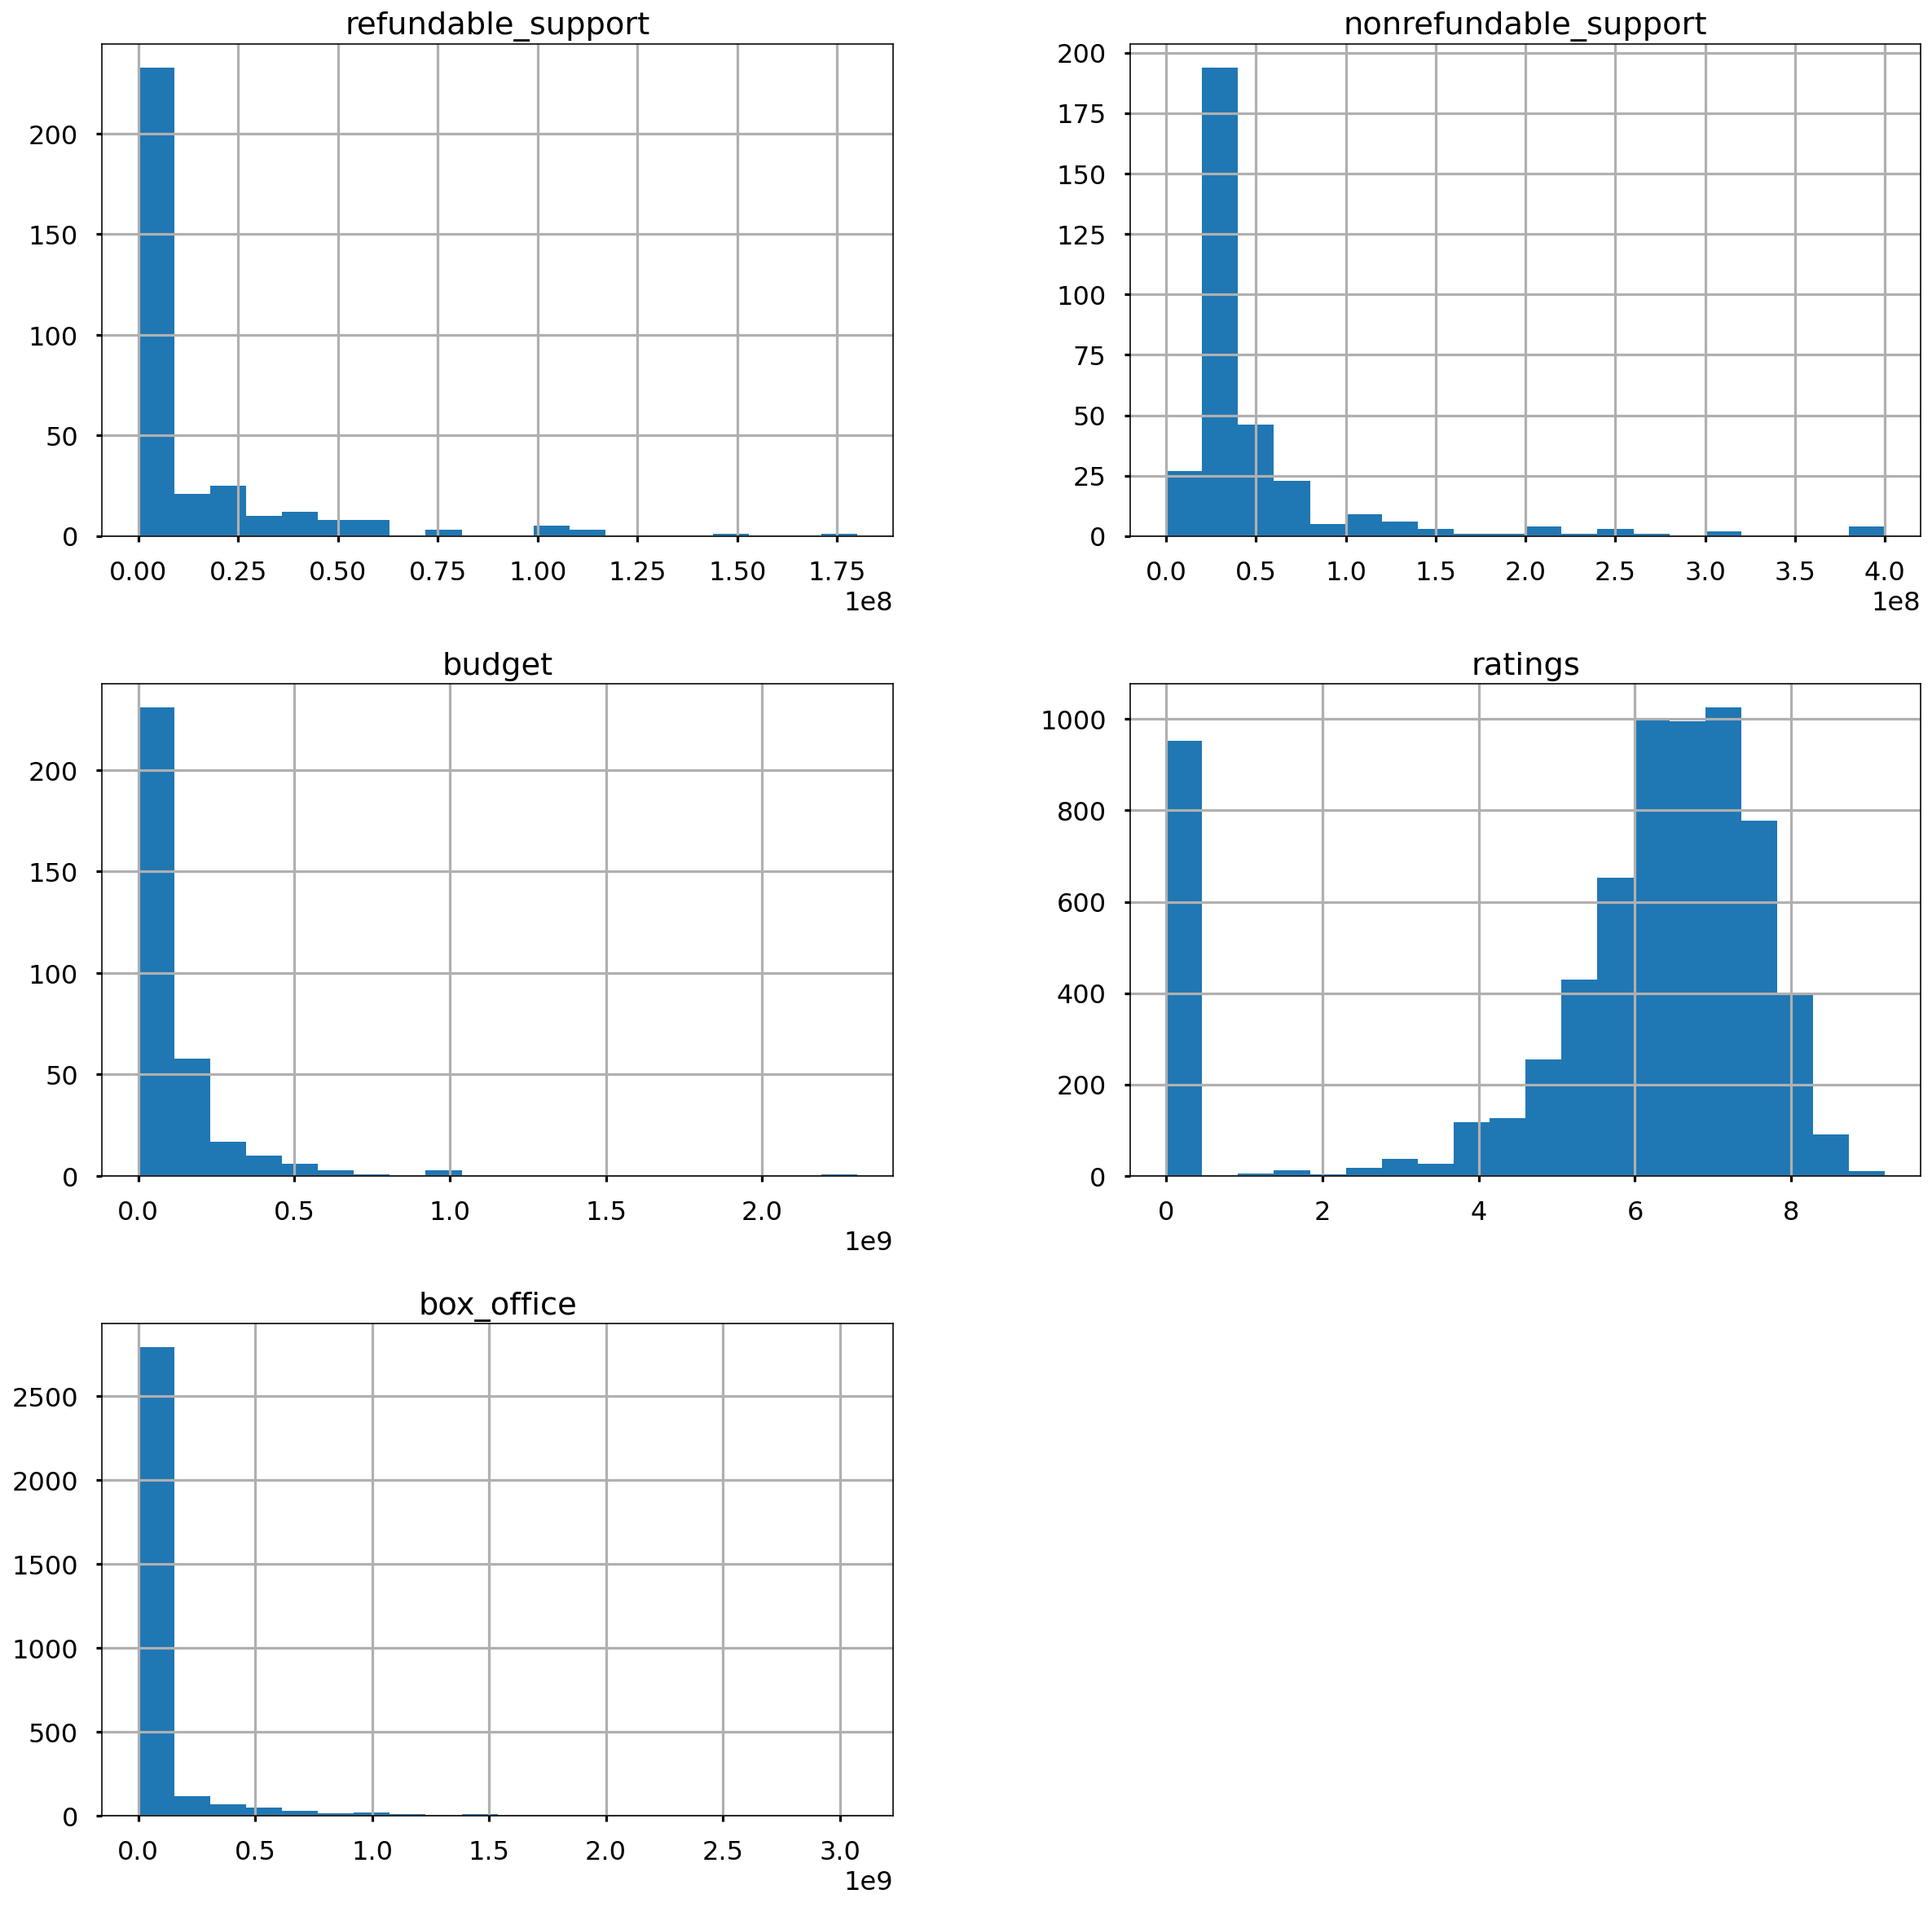

In [66]:
# Строю гистограммы по всем "числовым" столбцам
movies_shows.select_dtypes(include=np.number, exclude='int64').hist(figsize = (20, 20), bins = 20)
plt.show()

**Вывод по "числовым" столбцам:**

Построенные гистограммы отражают распределения всех числовых показателей датафрейма (за исключением номера прокатного удостоверения, т.к. в этом нет смысла).  
    
Построенные гистограммы отражают бОльшую долю пропущенных значений в указанных столбцах из-за того, что господдержку получила лишь небольшая доля фильмов.   
По ненулевым значением можно отметить большой разброс значений каждого из показателей. Для корректных выводов лучше построить отдельно гистограммы, исключеная пропуски.

In [67]:
# общее количество фильмов с "нулевым" бюджетом
print(movies_shows.loc[movies_shows['budget'] == 0, 'title'].count())
movies_shows.loc[movies_shows['budget'] == 0].T

17


,1907,1912,2296,2356,2436,2503,2604,2688,2860,3367,3476,3540,5137,5270,5469,5781,6273
title,14+,дуxless 2,воин 2015,бармен,савва сердце воина,тряпичный союз,срочно выйду замуж,помню - не помню,любовь с ограничениями,притяжение 2016,чудо-юдо,мифы,селфи,два хвоста,принцесса и дракон,баба яга,большое путешествие
puNumber,111023614,111000415,111017315,111009615,114001715,111010215,111017115,111004916,111008216,111018116,114001817,111004317,111012117,114001018,114003018,114006518,114002419
show_start_date,2014-12-19 12:00:00+00:00,2015-01-26 12:00:00+00:00,2015-09-28 12:00:00+00:00,2015-05-26 12:00:00+00:00,2015-07-21 12:00:00+00:00,2015-06-08 12:00:00+00:00,2015-09-30 12:00:00+00:00,2016-03-01 12:00:00+00:00,2016-04-29 12:00:00+00:00,2016-12-16 12:00:00+00:00,2017-06-27 12:00:00+00:00,2017-06-07 12:00:00+00:00,2018-02-01 12:00:00+00:00,2018-05-31 12:00:00+00:00,2018-08-23 12:00:00+00:00,2018-11-08 12:00:00+00:00,2019-04-20 12:00:00+00:00
type,художественный,художественный,художественный,художественный,анимационный,художественный,художественный,художественный,художественный,художественный,анимационный,художественный,художественный,анимационный,анимационный,анимационный,анимационный
film_studio,ооо киностудия сентябрь,"ооо киностудия слово , ооо арт пикчерс студия","ооо форпост продакшн , ооо арт пикчерс студия","ао вайт медиа , ооо арт пикчерс студия","ооо глюкоза продакшн , ооо арт пикчерс студия",ооо кинокомпания коктебель,"ао вайт медиа , ооо арт пикчерс студия",ооо кинофирма,"ао вайт медиа , ооо арт пикчерс студия","ооо водород 2011 , ооо арт пикчерс студия",ооо кинофирма,"ооо хайпфилм , ооо арт пикчерс студия","ооо киностудия слово , ооо арт пикчерс студия",ооо лицензионные бренды,ооо лицензионные бренды,ооо арт пикчерс студия,ооо лицензионные бренды
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
budget,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
financing_source,"министерство культуры, фонд кино",фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,министерство культуры,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино,фонд кино
ratings,6.60,6.60,7.80,6.20,4.60,6.30,5.10,4.30,6.30,5.60,5.20,4.80,5.80,5.00,5.20,0.00,6.20
genres,мелодрама,драма,"боевик, драма, криминал","комедия, фэнтези","мультфильм, приключения, фэнтези","комедия, драма","комедия, мелодрама",комедия,"комедия, мелодрама",фантастика,"мультфильм, фэнтези, семейный",комедия,"триллер, драма","мультфильм, детский","мультфильм, фэнтези, детский",unknown,"мультфильм, комедия, приключения"


Пропуски в столбце бюджет при заполненных значениях о господдержке противоречат описанию. Доля таких ошибок составляет менее 1%.  Однако эти пропуски я могу заполнить суммированным значением столбцов `refundable_support` и `nonrefundable_support`.

In [68]:
movies_shows.loc[movies_shows['budget'] == 0, 'budget'] = movies_shows['refundable_support'] + movies_shows['nonrefundable_support']

# проверяю удаление нулевых бюджетов
# общее количество фильмов с "нулевым" бюджетом
movies_shows.loc[movies_shows['budget'] == 0, 'title'].count()

0

In [69]:
# Проверяю корректность значений в столбце `budget`
movies_shows.query('budget < (refundable_support + nonrefundable_support)')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


**Вывод по обработке количественных данных:**  
   
       
    
В данных о жанрах фильмов пропущены пробелы между значениями строки. С помощью группы методов: .str.strip(), .str.lower() .str.replace() скорректировала данные строк, сохранила столбцы со скорректированными данными.  
    
    
Кроме того проверила корректность значений столбца `budget` — из описания проекта следует, что они не должны быть меньше суммы столбцов `refundable_support` и `nonrefundable_support`.

### Добавляю новые столбцы.

- Добавляю столбец с годом начала проката фильма на основании данных столбца `show_start_date` методом `dt.to_period()`.

In [70]:
movies_shows['show_start_date_year'] = pd.DatetimeIndex(movies_shows['show_start_date']).year

- Добавляю столбец с главным режиссёром и основным жанром фильма на основании данных столбца `director` и `genres` с помощью функции `add_column`.

In [71]:
# поочередно вызываю функцию `add_column` и добавляю с её помощью столбец с главным режиссёром и основным жанром
add_column(movies_shows, 'main_director', 'director')
add_column(movies_shows, 'main_genre', 'genres')

- Добавляю столбец с долей государственной поддержки от общего бюджета фильма.

In [72]:
movies_shows['share_of_government_support'] = (
    movies_shows['refundable_support'] + movies_shows['nonrefundable_support']) / movies_shows['budget']
# Вывожу датафрейм для проверки корректного отражения данных в новых столбцах
movies_shows[movies_shows['budget'] > 0].head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,show_start_date_year,main_director,main_genre,share_of_government_support
1188,пока еще жива,111005313,2013-10-11 12:00:00+00:00,художественный,"ано содействия развитию кинематографии ангел-фильм , ооо кинокомпания отражение",россия,а.атанесян,"а.атанесян, м.бабаханов, р.бутко",16,0.00,26500000.00,79411900.00,министерство культуры,8.10,"драма, мелодрама",365353.60,2013,а.атанесян,драма,0.33
1341,бесславные придурки,111003314,2014-03-28 12:00:00+00:00,художественный,ооо компания атк-студио,россия,а.якимчук,а.тютрюмов,12,0.00,26000000.00,37142857.00,министерство культуры,0.00,unknown,28140.00,2014,а.якимчук,unknown,0.70
1387,невидимки,111004213,2013-09-10 12:00:00+00:00,художественный,ооо компания реал-дакота,россия,"р.давлетьяров, с.комаров","р.давлетьяров, а.котелевский, а.олейников",12,0.00,107847945.00,176023490.00,фонд кино,5.30,"комедия, фантастика",19957031.50,2013,р.давлетьяров,комедия,0.61
1411,берцы,111004314,2014-05-05 12:00:00+00:00,художественный,ооо студия пассажир,россия,е.миндадзе (псевдоним катя шагалова),л.антонова,16,0.00,28000000.00,40574140.00,министерство культуры,4.20,драма,55917.50,2014,е.миндадзе (псевдоним катя шагалова),драма,0.69
1664,братья ч,111004414,2014-04-23 12:00:00+00:00,художественный,ооо студия пассажир,россия,м.угаров,"а.миндадзе, л.антонова",16,0.00,25000000.00,40015122.00,министерство культуры,6.40,драма,232100.00,2014,м.угаров,драма,0.62


In [73]:
movies_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6927 entries, 0 to 6926
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   title                        6927 non-null   object             
 1   puNumber                     6927 non-null   int64              
 2   show_start_date              6927 non-null   datetime64[ns, UTC]
 3   type                         6927 non-null   object             
 4   film_studio                  6927 non-null   object             
 5   production_country           6927 non-null   object             
 6   director                     6927 non-null   object             
 7   producer                     6927 non-null   object             
 8   age_restriction              6927 non-null   int64              
 9   refundable_support           330 non-null    float64            
 10  nonrefundable_support        330 non-null    flo

**Вывод по добавлению столбцов:**   

***В отдельные столбцы были выделены данные по основному жанру, главному режиссёру, году старта проката и доле господдержки. Эта информация необходима для группировки при проведении исследовательского анализа данных.***

## Исследовательский анализ данных.


### Анализ количества фильмов в прокате каждый год.

Для анализа ежегодного количества выходов в прокат фильмов построю сводную таблицу методом `pivot_table()` и график динамики доли фильмов в прокате.   
Обращаю внимание на долю с указанной информацией о прокатах в кинотеатрах, провожу анализ изменения этой доли каждый год.

In [74]:
# строю сводную таблицу по количеству, сумме и среднему значению проката фильмов в каждый из годов
movies_shows_box_office_pivot = display_pivot_table(
    movies_shows, 
    'show_start_date_year', 
    aggfunc=['count', 'sum', 'mean'], 
    column_names=['number_of_films', 'sum_box_office', 'average_value'],
    base_column='box_office')

movies_shows_box_office_pivot

,number_of_films,sum_box_office,average_value
show_start_date_year,,,
2010,105,2428654.00,23130.04
2011,109,14102765.00,129383.17
2012,126,6909333.00,54835.98
2013,184,29799706.20,161954.92
2014,278,7444947564.20,26780386.92
2015,460,38966066659.70,84708840.56
2016,523,47862924556.91,91516108.14
2017,356,48563669257.51,136414801.29
2018,474,49666815912.81,104782312.05


,numbers_of_box_office,total_number_of_films,share_of_box_office
show_start_date_year,,,
2010,105,786,0.13
2011,109,486,0.22
2012,126,532,0.24
2013,184,594,0.31
2014,278,747,0.37
2015,460,688,0.67
2016,523,796,0.66
2017,356,500,0.71
2018,474,880,0.54


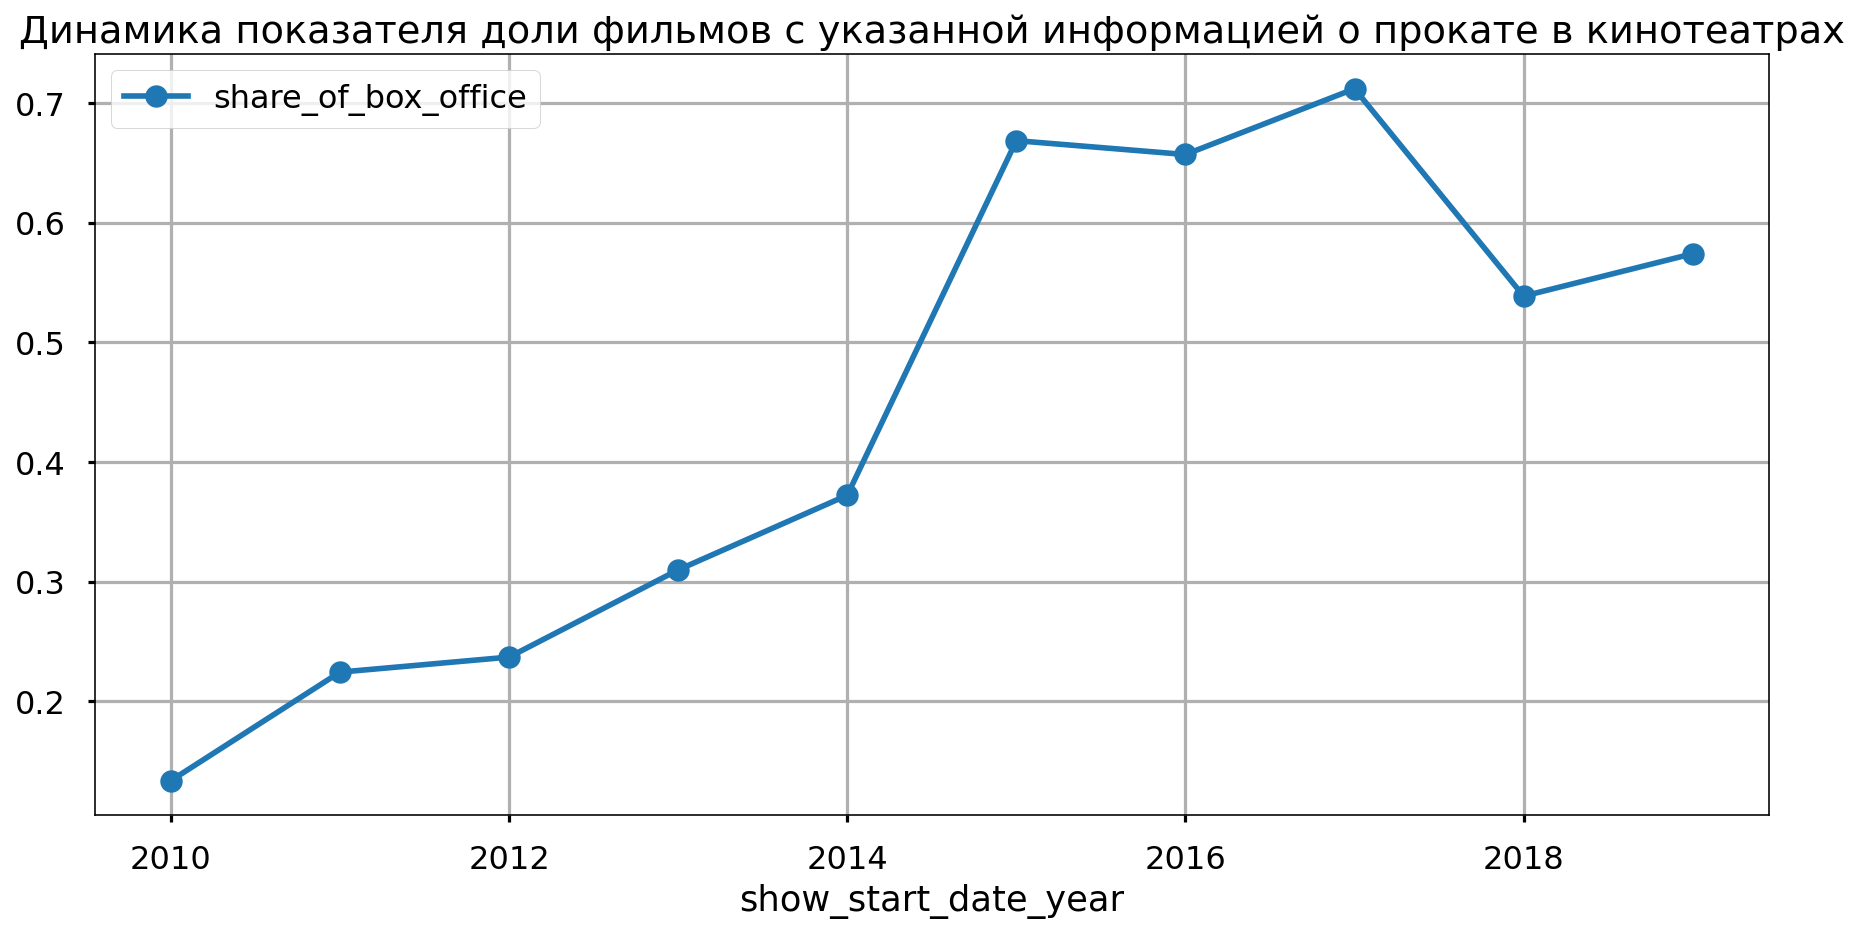

In [75]:
movies_shows_pivot = movies_shows.pivot_table(
    index=['show_start_date_year'],
    values=['title', 'box_office'],
    aggfunc=['count'])
movies_shows_pivot.columns = ['numbers_of_box_office','total_number_of_films']

# добавляю в сводную солбец с долей фильмов в прокате от общего количества фильмов
movies_shows_pivot['share_of_box_office'] = movies_shows_pivot['numbers_of_box_office'] / movies_shows_pivot['total_number_of_films']

# строю график динамики показателя доли фильмов с указанной информацией о прокате в кинотеатрах методом `plot()`
movies_shows_pivot['share_of_box_office'].plot(
    title='Динамика показателя доли фильмов с указанной информацией о прокате в кинотеатрах', 
    style='o-',
    grid=True,
    figsize=(15,7),
    legend=True)
movies_shows_pivot

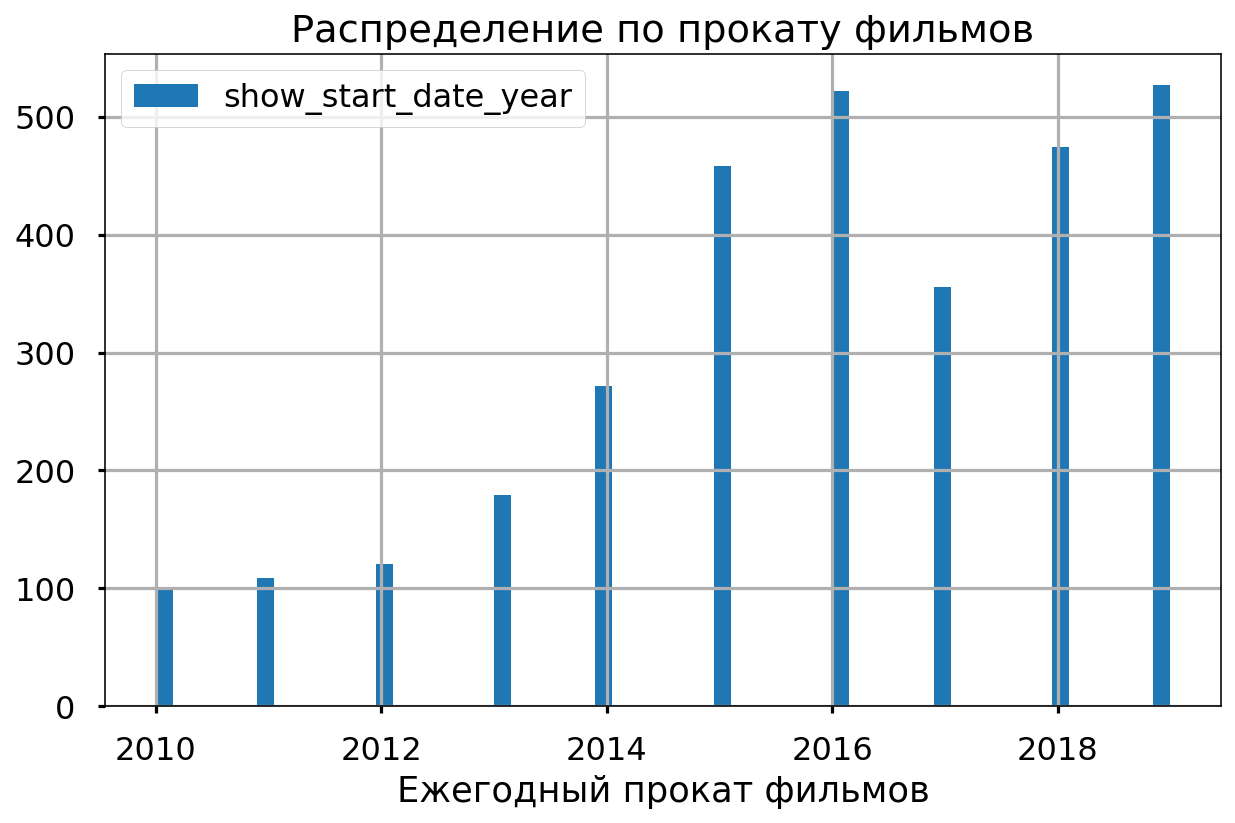

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,show_start_date_year,main_director,main_genre,share_of_government_support
4,любовь и голуби,111007013,2013-10-18 12:00:00+00:00,художественный,киностудия мосфильм,ссср,в.меньшов,unknown,12,NaN,NaN,NaN,NaN,8.30,"мелодрама, комедия",2700.00,2013,в.меньшов,мелодрама,NaN
16,неподдающиеся,111003616,2016-02-12 12:00:00+00:00,художественный,киностудия мосфильм,ссср,ю.чулюкин,unknown,6,NaN,NaN,NaN,NaN,8.00,"мелодрама, комедия",360.00,2016,ю.чулюкин,мелодрама,NaN
17,неподсуден,111003716,2016-02-12 12:00:00+00:00,художественный,киностудия мосфильм,ссср,"в.краснопольский, в.усков",unknown,6,NaN,NaN,NaN,NaN,7.70,драма,420.00,2016,в.краснопольский,драма,NaN
20,"операция ""ы"" и другие приключения шурика",111007413,2013-10-18 12:00:00+00:00,художественный,киностудия мосфильм,ссср,л.гайдай,unknown,6,NaN,NaN,NaN,NaN,8.70,"комедия, мелодрама, криминал",380.00,2013,л.гайдай,комедия,NaN
36,мужики,111007213,2013-10-18 12:00:00+00:00,художественный,киностудия мосфильм,ссср,и.бабич,unknown,6,NaN,NaN,NaN,NaN,8.10,драма,1165.00,2013,и.бабич,драма,NaN


In [76]:
movies_shows_box_office = movies_shows[movies_shows['box_office'] > 0]
build_hist(
    movies_shows_box_office.show_start_date_year, 
    'Ежегодный прокат фильмов', 
    'Распределение по прокату фильмов', 
    figsize=(10, 6), 
    bins=60)
movies_shows_box_office.head()

<div class="alert alert-info">

    
**Вывод:**
    
***Результаты расчетов и графики отражают неравномерное распределение доли фильмов с указанной информацией о прокате в кинотеатрах.***   
    
    
***Значительный рост количества таких фильмов на графике отражен с 2015 года.***
</div>

### Динамика проката по годам.

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office
show_start_date_year,,,
2010,101,2428654.00,24046.08
2011,109,14102765.00,129383.17
2012,121,6909333.00,57101.93
2013,179,29799706.20,166478.81
2014,272,7444947564.20,27371130.75
2015,458,38966066659.70,85078748.17
2016,522,47862924556.91,91691426.35
2017,356,48563669257.51,136414801.29
2018,474,49666815912.81,104782312.05


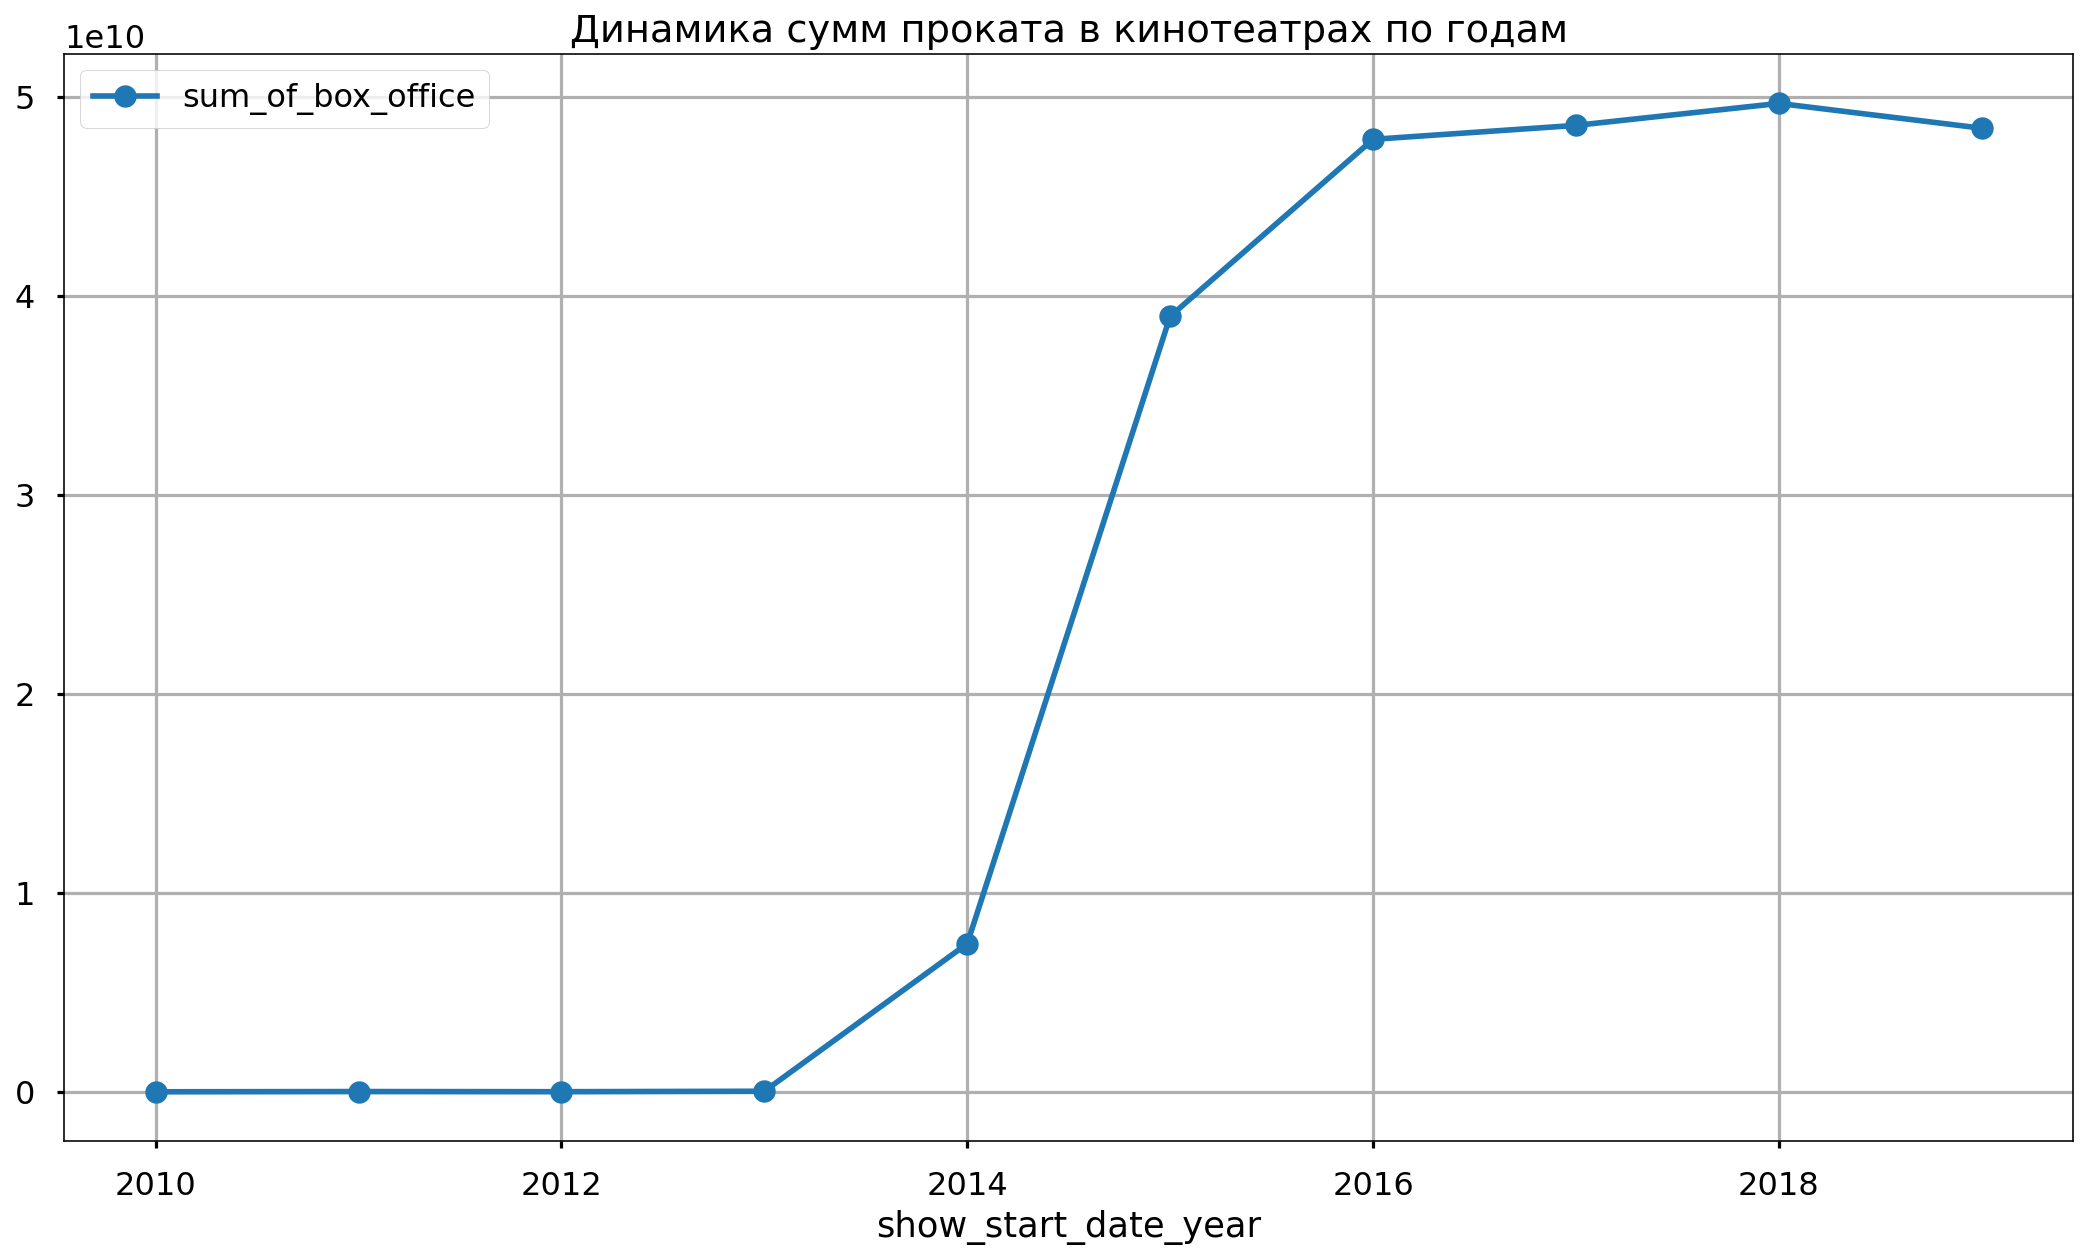

In [77]:
# строю сводную таблицу по количеству, сумме и среднему значению проката фильмов в каждый из годов
movies_shows_box_office_pivot = movies_shows_box_office.pivot_table(
    index=['show_start_date_year'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean'])
movies_shows_box_office_pivot.columns = ['numbers_of_box_office', 'sum_of_box_office', 'average_sum_of_box_office']

# строю график по количеству, сумме и среднему значению проката фильмов в каждый из годов
movies_shows_box_office_pivot['sum_of_box_office'].plot(
    title='Динамика сумм проката в кинотеатрах по годам', 
    style='o-',
    grid=True,
    figsize=(18,10),
    legend=True)
movies_shows_box_office_pivot

<div class="alert alert-info">
    
График динамики проката по годам отражает скачок суммы сборов в 2015 году.   
График и сводная показывают максимальную сумму сборов в 2018 году и минимальную — в 2010.
</div>

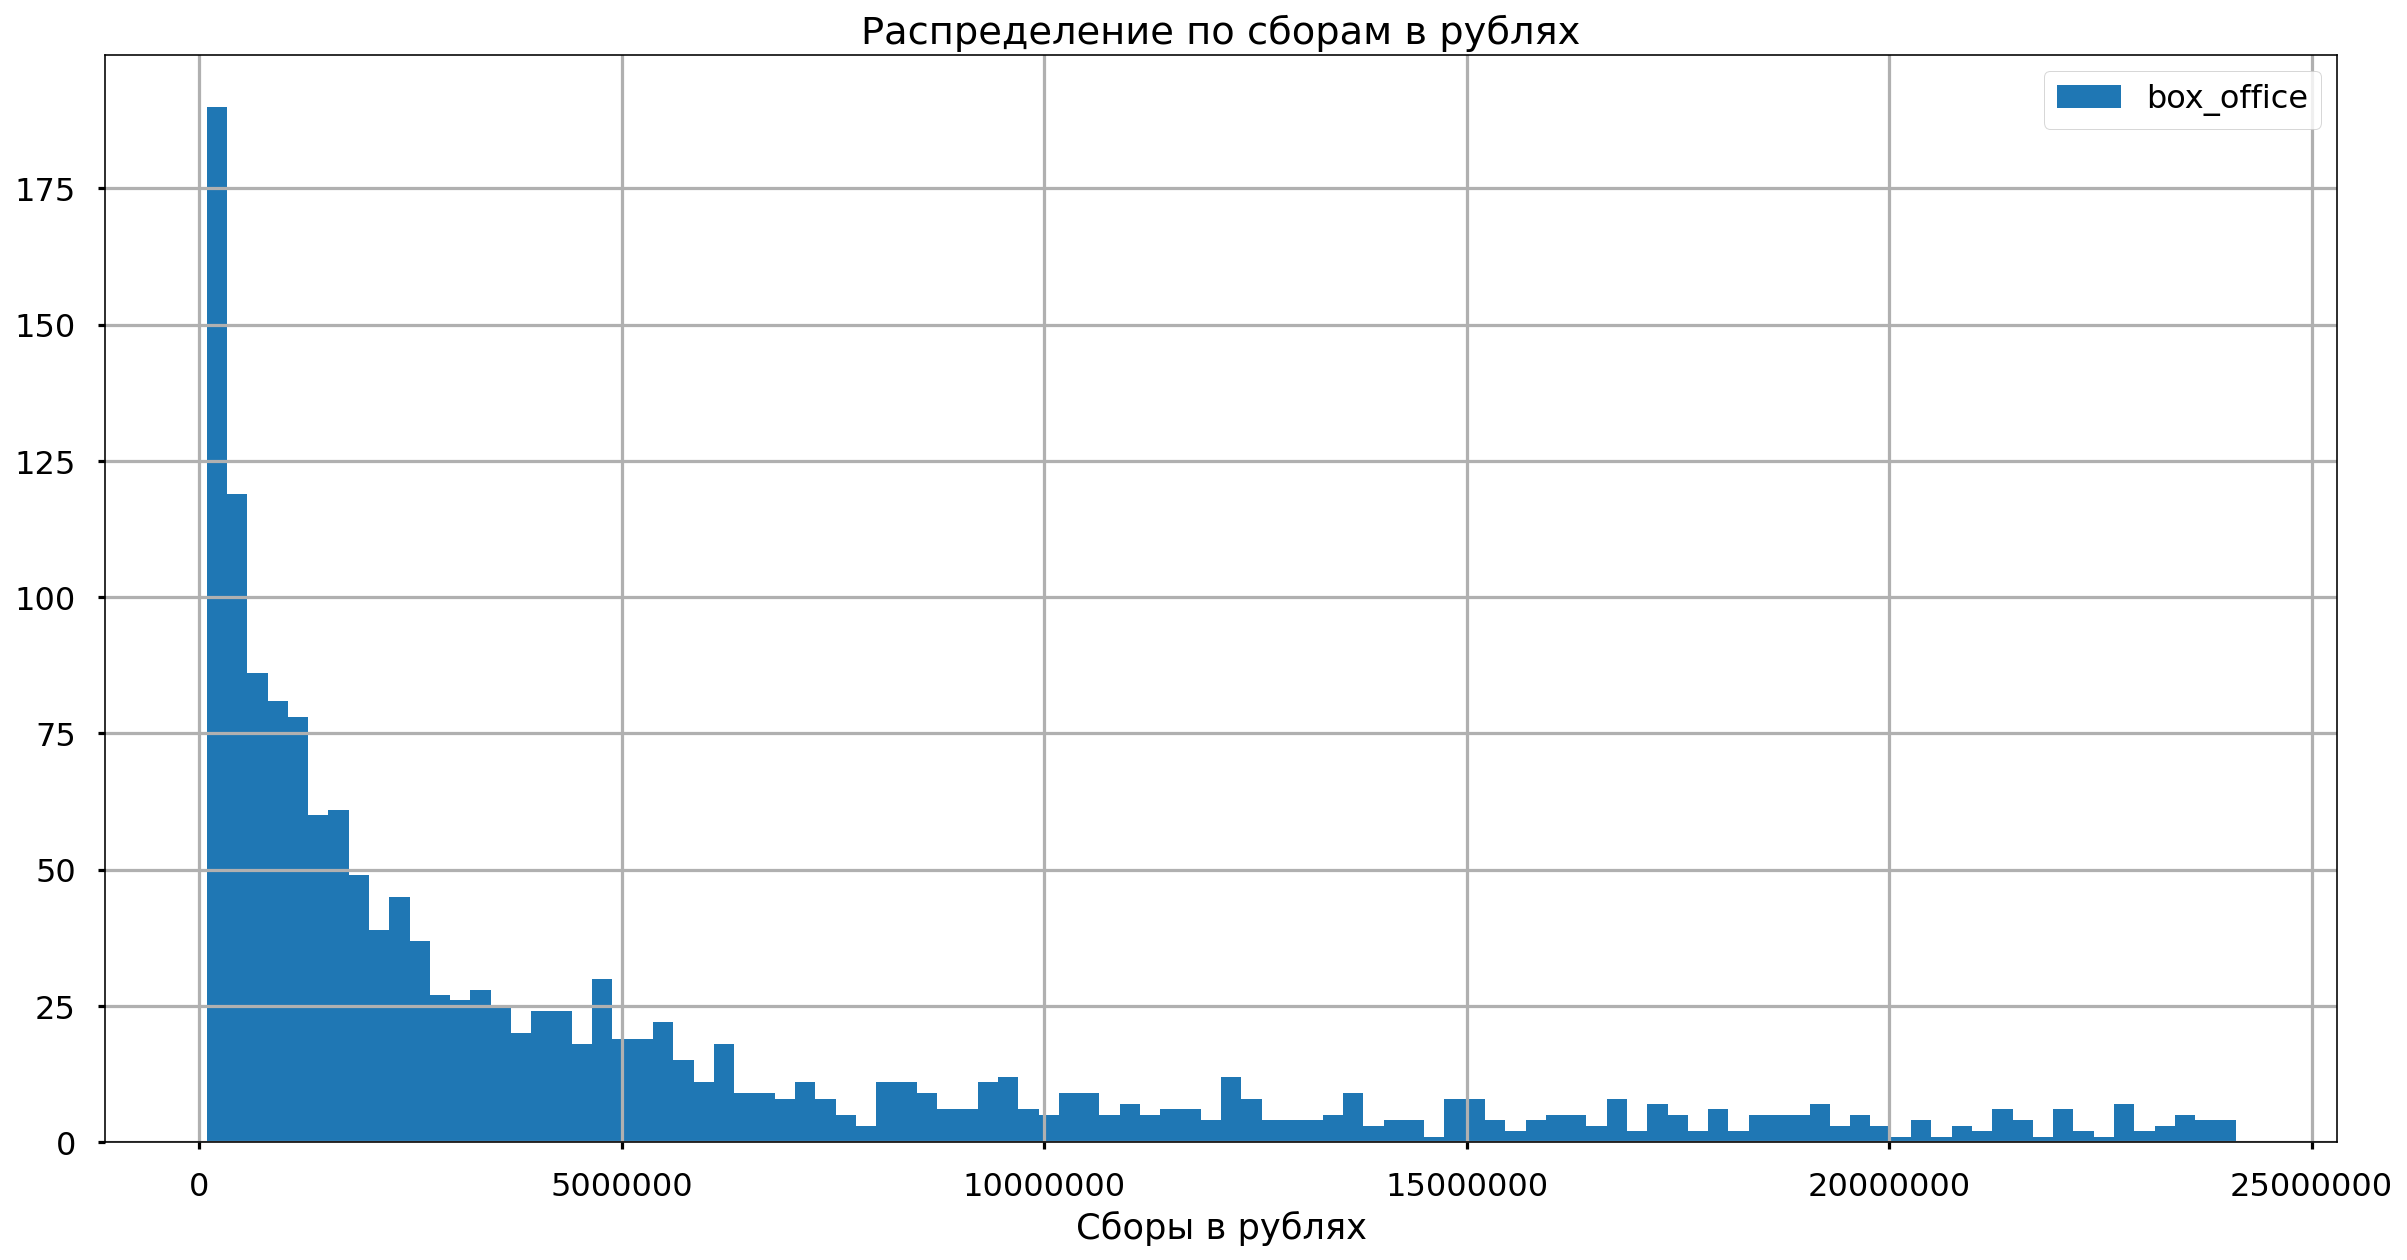

count         3142.00
mean      76695970.31
std      240772480.67
min              0.00
25%          87835.25
50%        2352586.75
75%       24157845.14
max     3073568690.79
Name: box_office, dtype: float64

In [78]:
# распределение по сборам в рублях
build_hist(
    movies_shows[(
        ~ movies_shows['box_office'].isna()
    ) & (
        movies_shows['box_office'] >= movies_shows['box_office'].describe().loc['25%']
    ) & (
        movies_shows['box_office'] <= movies_shows['box_office'].describe().loc['75%']
    )].box_office, 'Сборы в рублях', 'Распределение по сборам в рублях', 
    figsize=(20, 10), bins=100)
# основные показатели распределения 
movies_shows['box_office'].describe()

Сводная таблица в пункте 4.1 и вызов метода `describe()` по столбцу `box_office` отражает большой разброс значений.   
Ограничу значения для гистограммы в пределах межквартильного размаха.

**Вывод по анализу ежегодной динамике проката:**

***Гистограммы отражают, что основная доля фильмов имеет сумму сборов менее 1 000 000 руб, основная сумма сборов в 2016 и в 2018 годах.***  

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Отлично, гистограммы верно построены и в полной мере оформлены.

Только лучше жестко не задавать числа для фильтрации или ограничения гистограммы, лучше использовать непосредственный расчет квантилей при построении графика или переменные для хранения информации.

Иначе предобработка немного изменится, значение квантилей немного поплывет и придется везде, где вручную числа введены, вносить изменения.
</div>

### Динамика сборов по годам, агрегатные значения по сборам в рублях.

<div class="alert alert-info">
    
Для понимания причин роста сумм сборов после 2015 года проанализирую агрегатные значения по сборам, отражённые в столбце `box_office`.
    
</div>

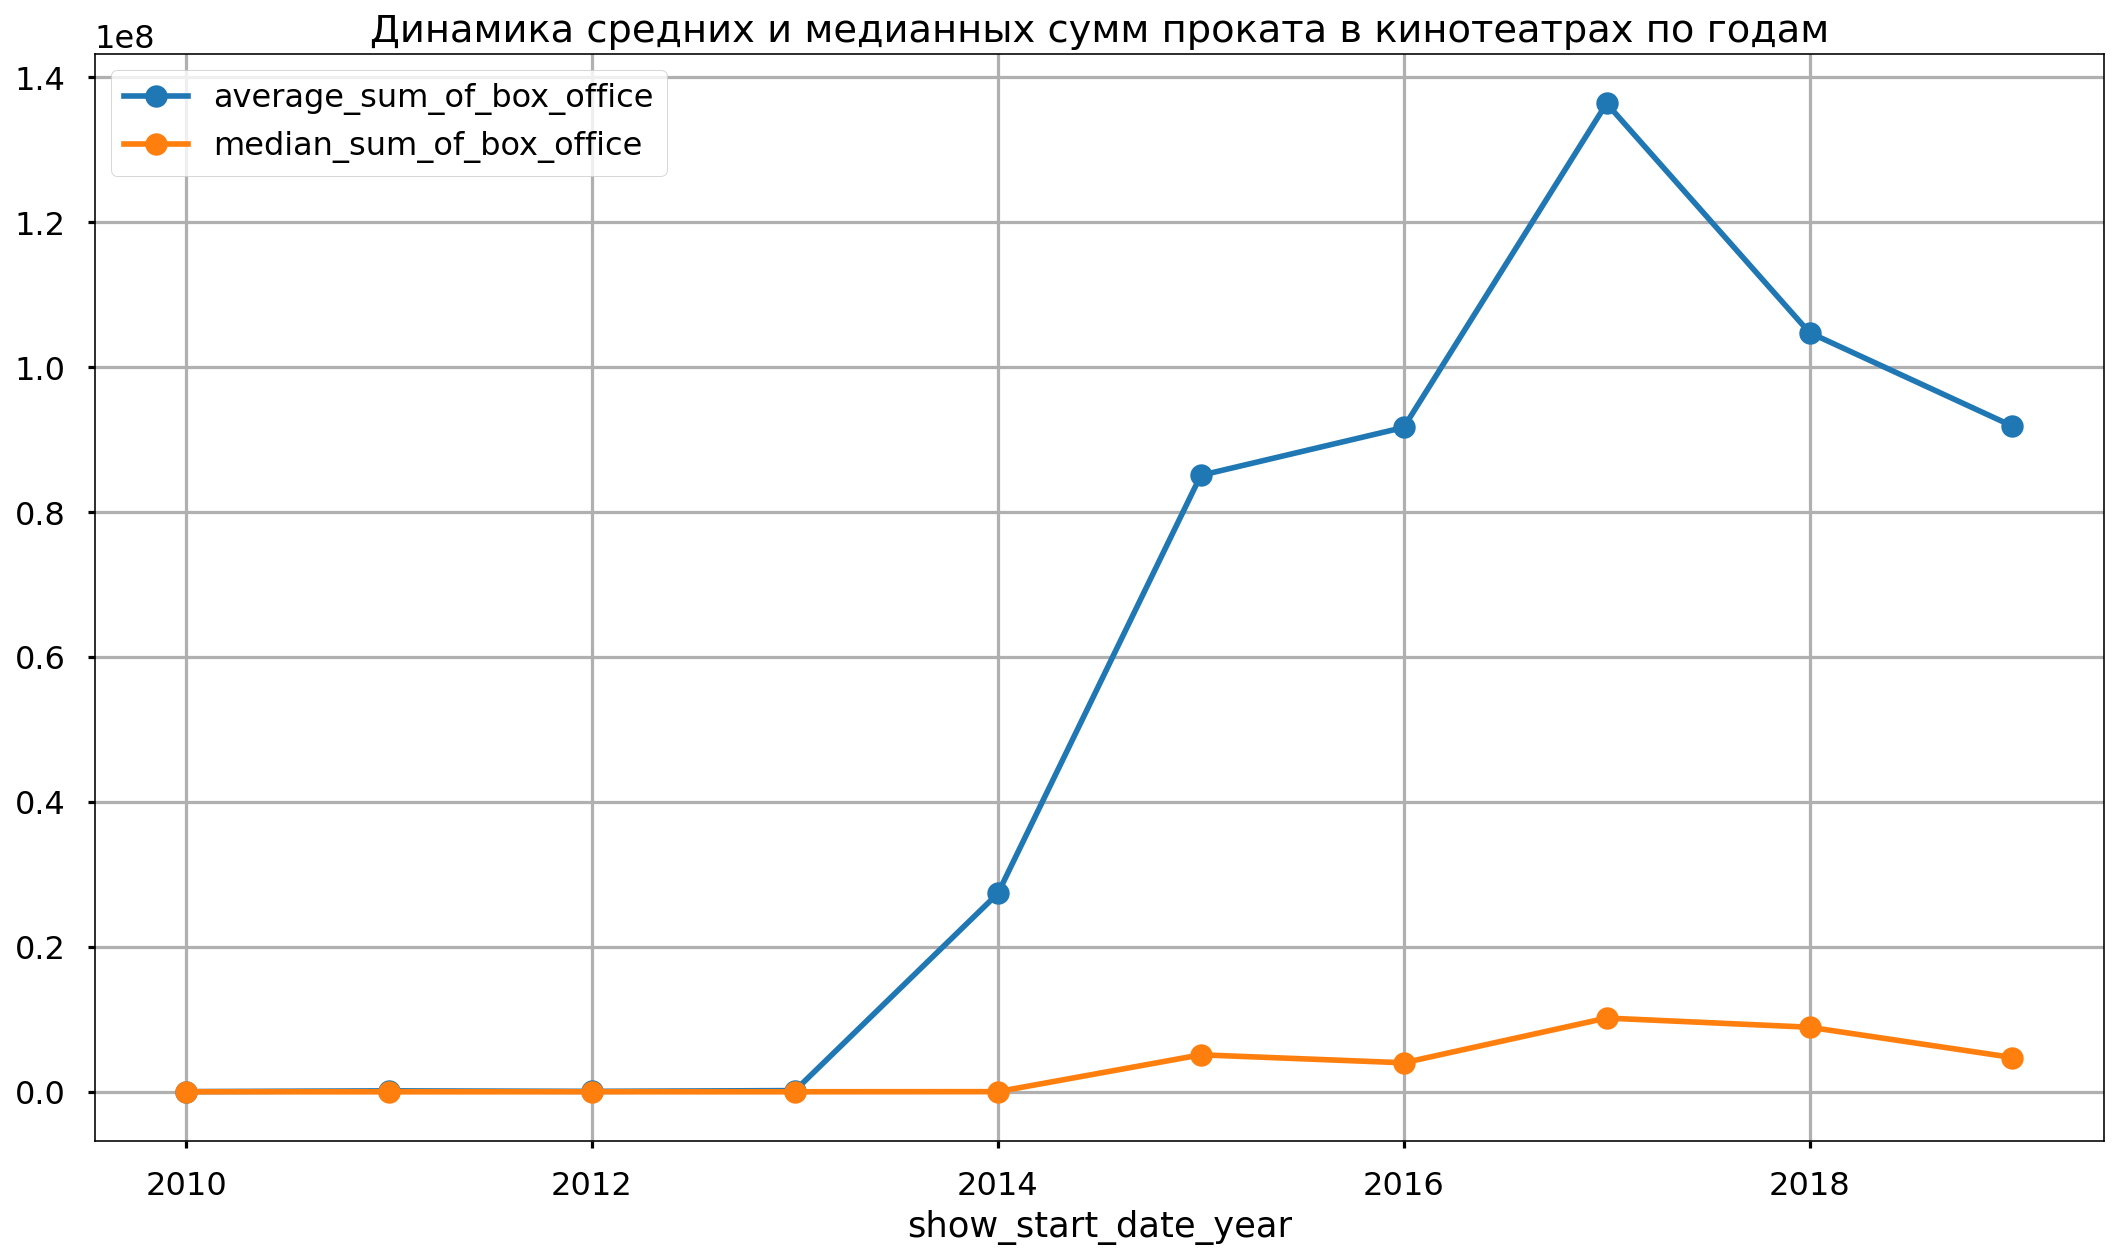

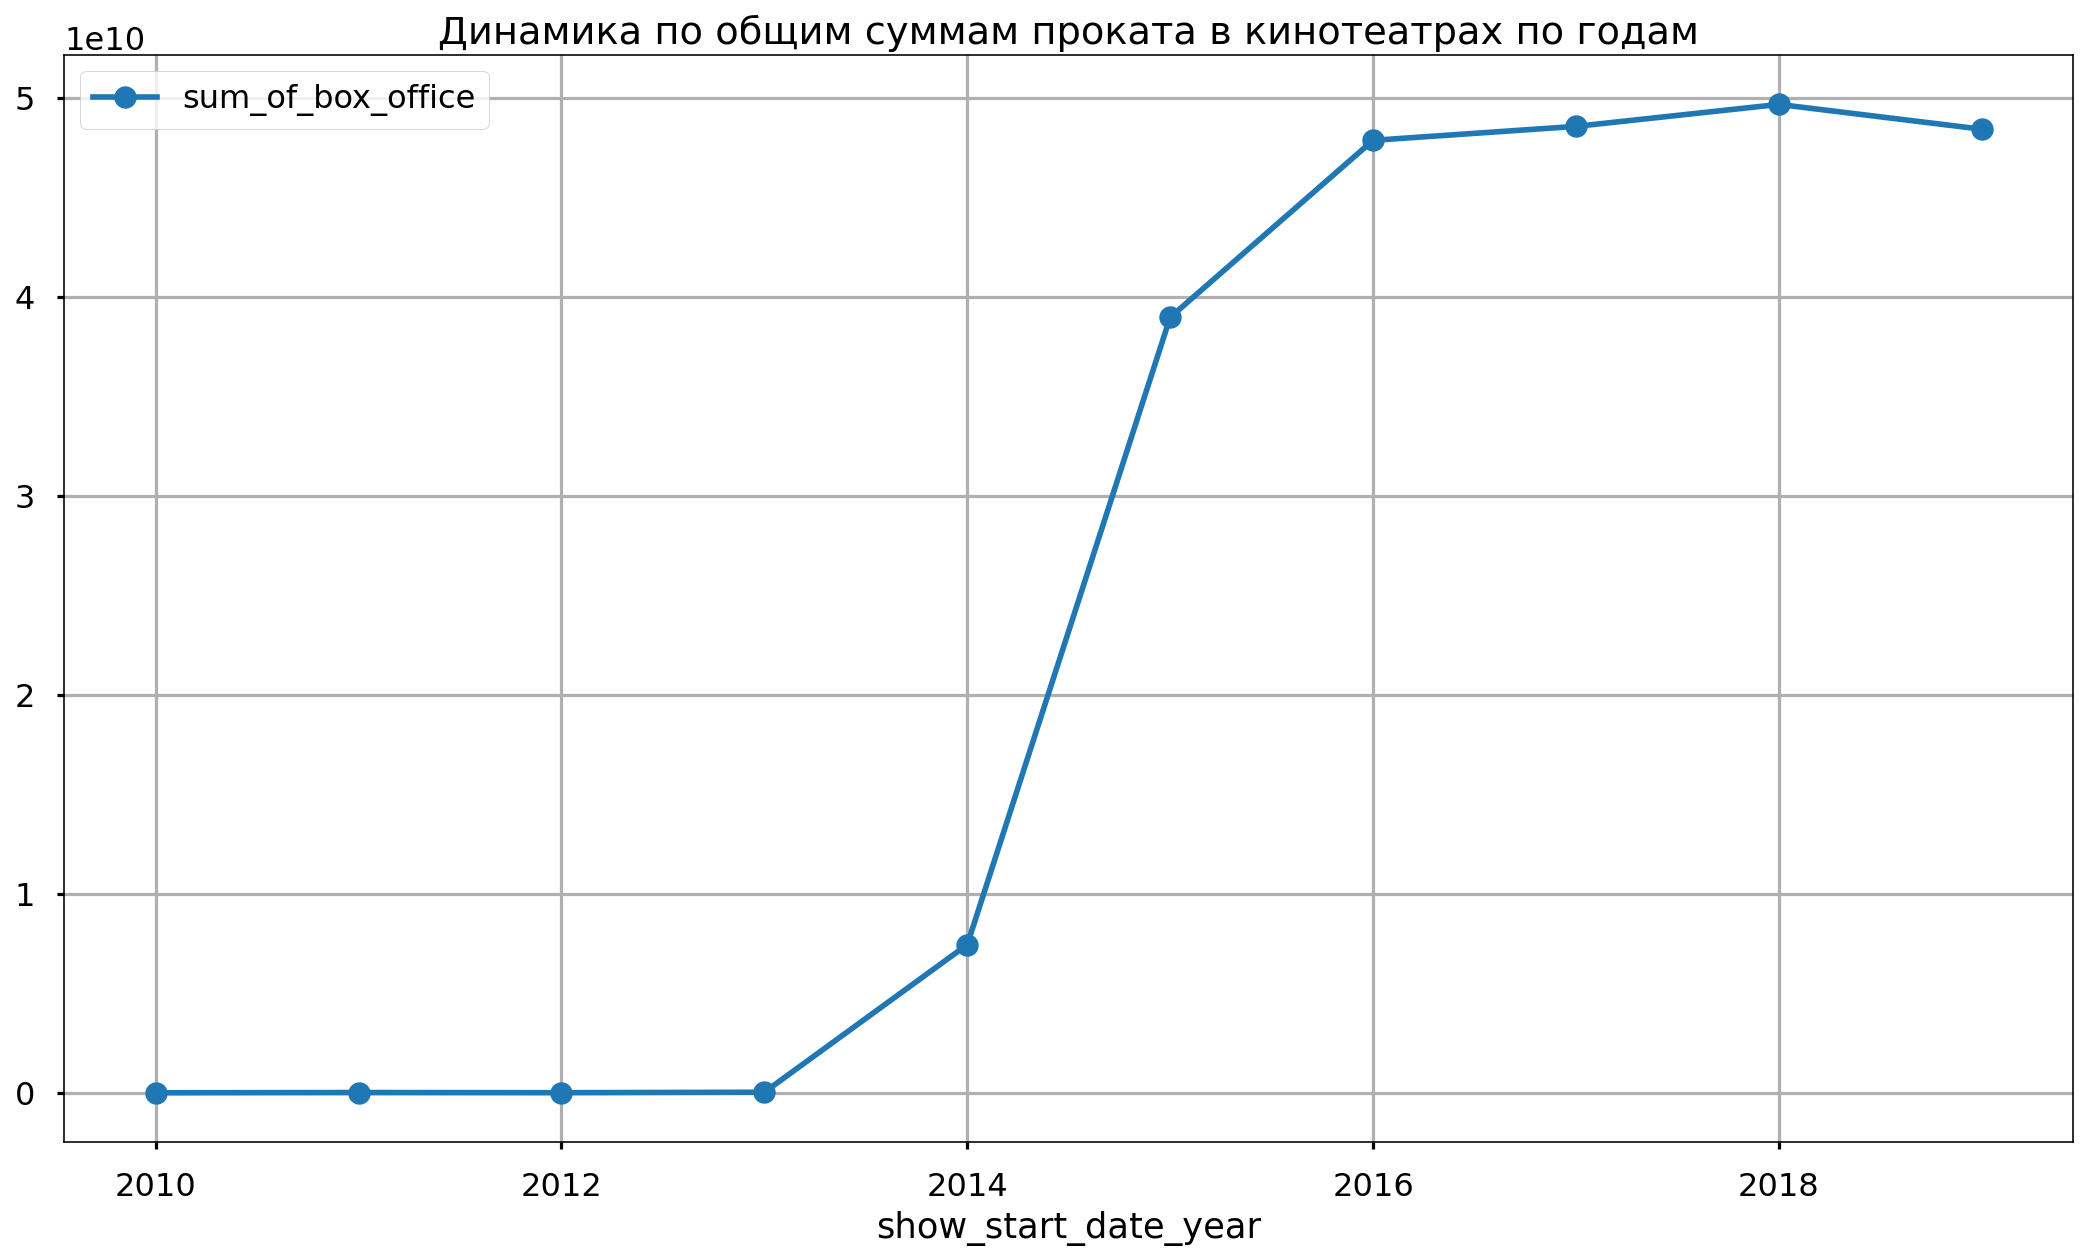

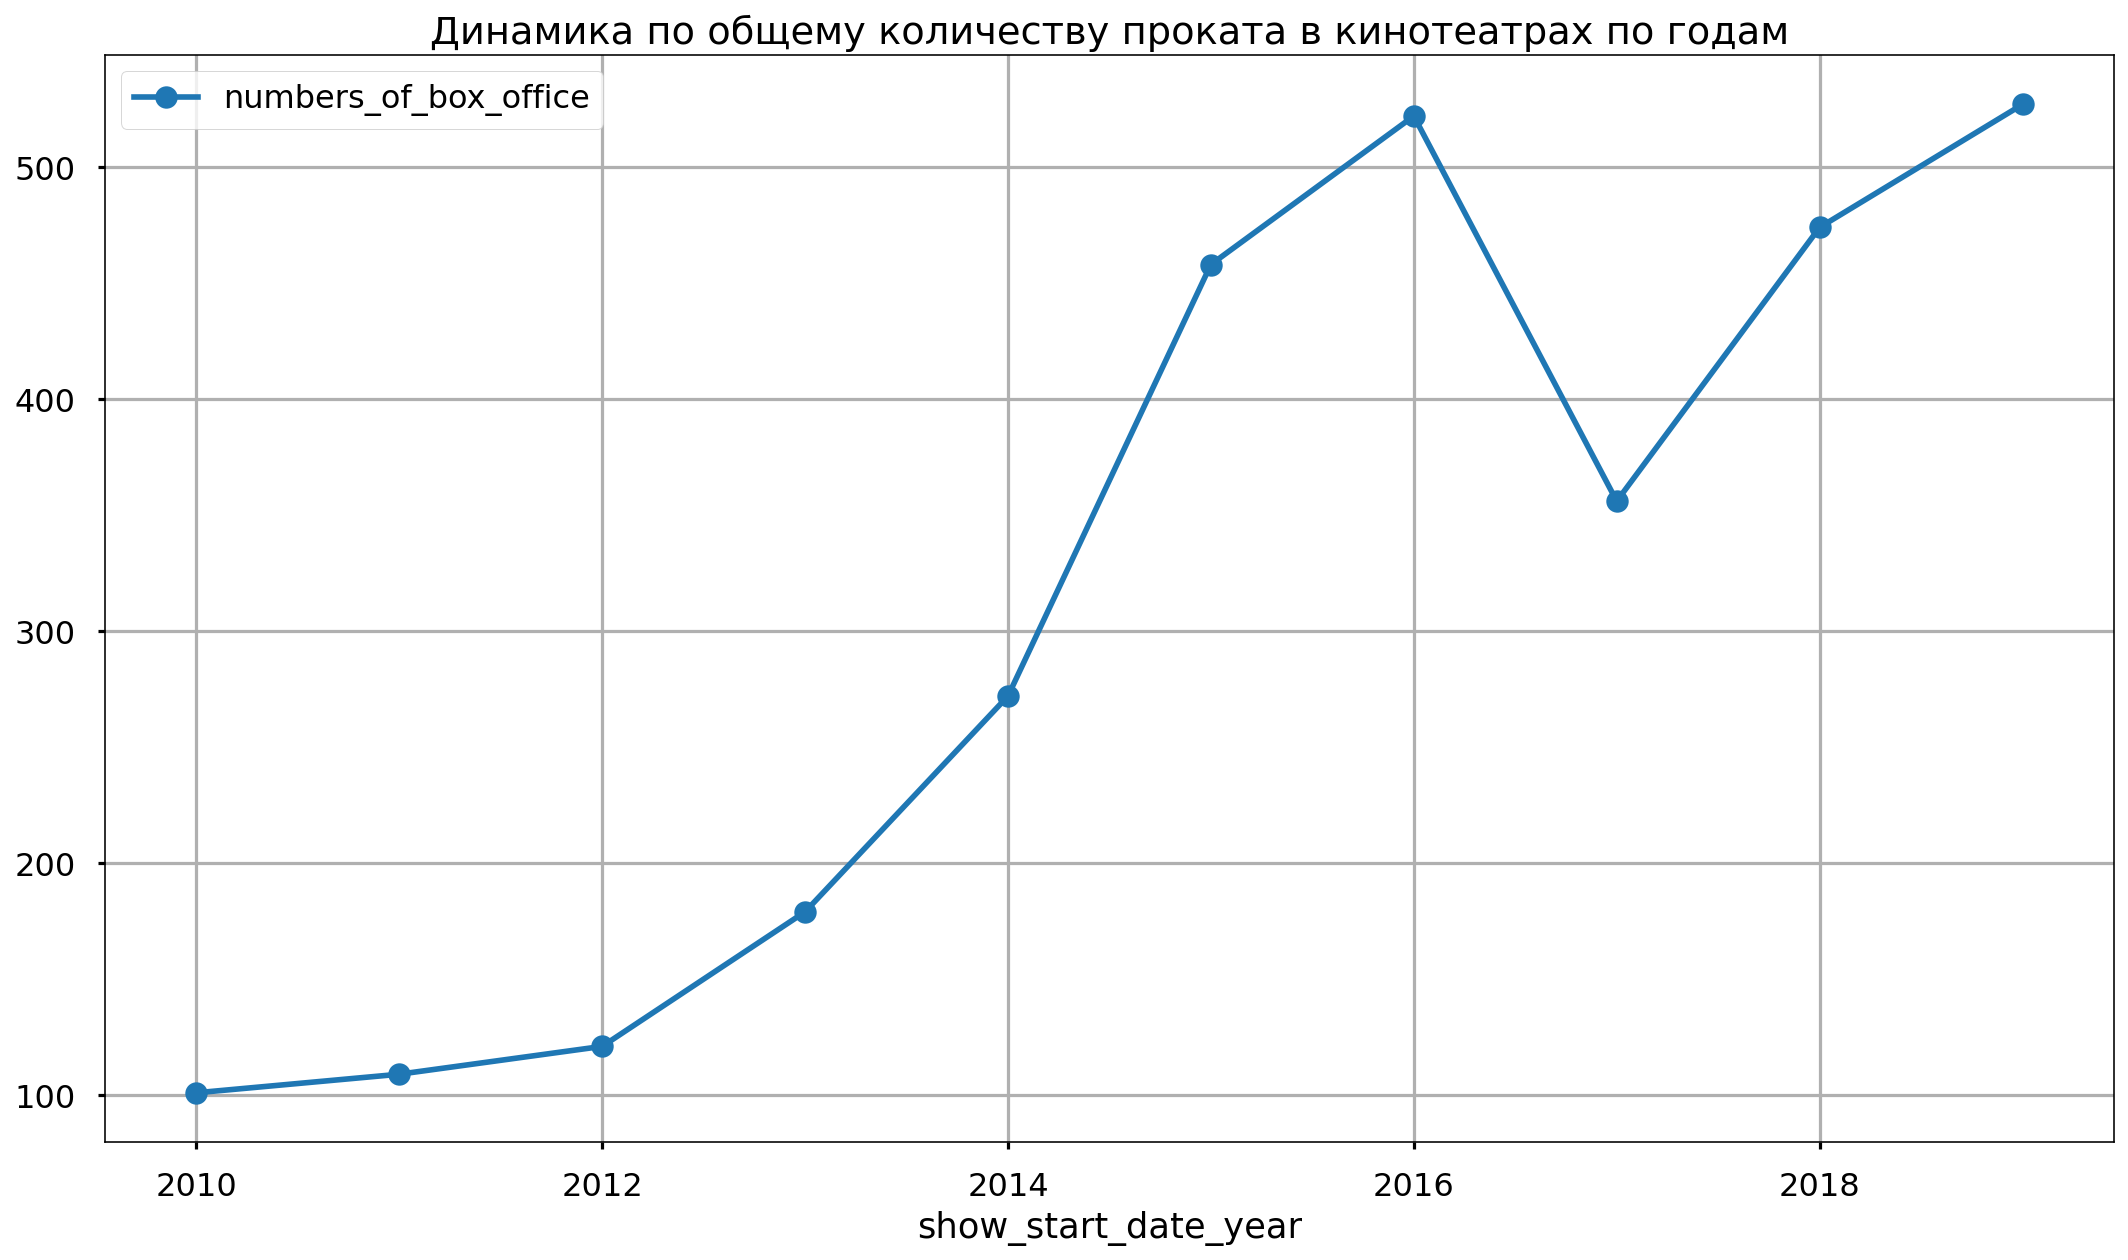

In [79]:
# строю сводную таблицу по количеству, сумме и среднему значению проката фильмов в каждый из годов
movies_shows_box_office_years_pivot = movies_shows_box_office.pivot_table(
    index=['show_start_date_year'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median'])
# присваиваю названия столбцов в сводной таблице
movies_shows_box_office_years_pivot.columns = [
    'numbers_of_box_office', 
    'sum_of_box_office', 
    'average_sum_of_box_office', 
    'median_sum_of_box_office']
movies_shows_box_office_years_pivot

# график по средним и медианным значениям по сборам
movies_shows_box_office_years_pivot[[
    'average_sum_of_box_office', 
    'median_sum_of_box_office'
    ]].plot(
        title='Динамика средних и медианных сумм проката в кинотеатрах по годам', 
        style='o-',
        grid=True,
        figsize=(18,10),
        legend=True)
plt.show()

# график по общим суммам сборов с проката
movies_shows_box_office_years_pivot['sum_of_box_office'].plot(
        title='Динамика по общим суммам проката в кинотеатрах по годам', 
        style='o-',
        grid=True,
        figsize=(18,10),
        legend=True)
plt.show()

# график по общему количеству фильмов в прокате
movies_shows_box_office_years_pivot['numbers_of_box_office'].plot(
        title='Динамика по общему количеству проката в кинотеатрах по годам', 
        style='o-',
        grid=True,
        figsize=(18,10),
        legend=True)
plt.show()

Сравнение средних значений по сборам с медианными позволяют сделать вывод о большом разбросе сумм сборов, что можно объяснить большим разбросом между более и менее популярными фильмами в прокате.

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**
    
Расчет верный и выводы правильные
    
Я бы построила график. Он всегда нагляднее, чем таблица    
</div>

<div class="alert alert-info">
    
**Выводы по динамике сборов по годам**

Графики, построенные по медианным, средним и общим суммам сборов, а также по количеству сборов позволяют отметить некоторые особенности распределения:

- первый график отражает существенную разницу в росте средних и медианных значений по суммам сборов с 2015 года. Это ещё раз подтверждает, что лидерами по сборам стали скорее всего отдельные картины, а не рост индустрии в целом;
- разница динамики отражённая на втором и третьем графиках подтверждает эту гипотезу — падение количества фильмов в прокате в 2017 году не приводит к падению суммы сборов в прокате, а среднее и медианное значение суммы сборов максимальные именно в 2017 году;
- можно предположить, что рост количества анализируемых фильмов в прокате позволил расширить и качественную выборку в данных и в неё как раз попали лидеры по сборам, так существенно повлиявшие на общую сумму сборов.
    
</div>

<div class="alert alert-success">
    
**Комментарий ревьюера - 2**

**#ок**

Отлично
</div>

### Влияние возрастных ограничений на сборы фильмов в прокате в период с 2015 по 2019 годы.

- С помощью функции `display_pivot_table` строю сводную таблицу с данными после 2015 года и индексацией по возрастным ограничениям.

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Можно преобразовать названия, укоротив их, примерно вот так

    df['age_restriction'] = df['age_restriction'].apply(lambda x: get_first_value(x, sep='-'))
</div>

show_start_date_year              2015                               \
age_restriction                     0             6              12   
numbers_of_box_office            38.00         51.00          72.00   
sum_of_box_office         379054578.37 8172732063.71 13616082008.91   
average_sum_of_box_office   9975120.48  160249648.31   189112250.12   
median_sum_of_box_office    2949808.55   20380982.20    15959668.30   

show_start_date_year                                           2016  \
age_restriction                       16            18           0    
numbers_of_box_office             166.00        131.00        41.00   
sum_of_box_office         11367319500.27 5430878508.44 150228848.67   
average_sum_of_box_office    68477828.31   41457087.85   3664118.26   
median_sum_of_box_office      4878669.70    4654761.40   2571294.10   

show_start_date_year                                                    \
age_restriction                       6              12             16   
numbers_of_box_office              70.00          82.00         180.00   
sum_of_box_office         12053146008.24 12204446524.39 16664465701.74   
average_sum_of_box_office   172187800.12   148834713.71    92580365.01   
median_sum_of_box_office      3026256.15     4690635.25     5281042.10   

show_start_date_year                     ...        2018                 \
age_restriction                      18  ...          0              6    
numbers_of_box_office            149.00  ...        5.00          68.00   
sum_of_box_office         6790637473.87  ... 32449002.11 10104974623.41   
average_sum_of_box_office   45574748.15  ...  6489800.42   148602567.99   
median_sum_of_box_office     6375092.00  ...  3616937.28    14688850.32   

show_start_date_year                                                   \
age_restriction                       12             16            18   
numbers_of_box_office              67.00         156.00        178.00   
sum_of_box_office         14267291660.69 16503602346.96 8758498279.64   
average_sum_of_box_office   212944651.65   105792322.74   49205046.51   
median_sum_of_box_office      8931965.66     9010638.62    7604029.00   

show_start_date_year             2019                                \
age_restriction                    0              6              12   
numbers_of_box_office            3.00          80.00          85.00   
sum_of_box_office         17746066.82 12852513658.86 12680198773.67   
average_sum_of_box_office  5915355.61   160656420.74   149178809.10   
median_sum_of_box_office   3885434.50    14199614.88     3405545.76   

show_start_date_year                                     
age_restriction                       16             18  
numbers_of_box_office             176.00         183.00  
sum_of_box_office         12748819511.65 10121796303.64  
average_sum_of_box_office    72436474.50    55310362.31  
median_sum_of_box_office      3210717.81     5603216.55  

[4 rows x 25 columns]

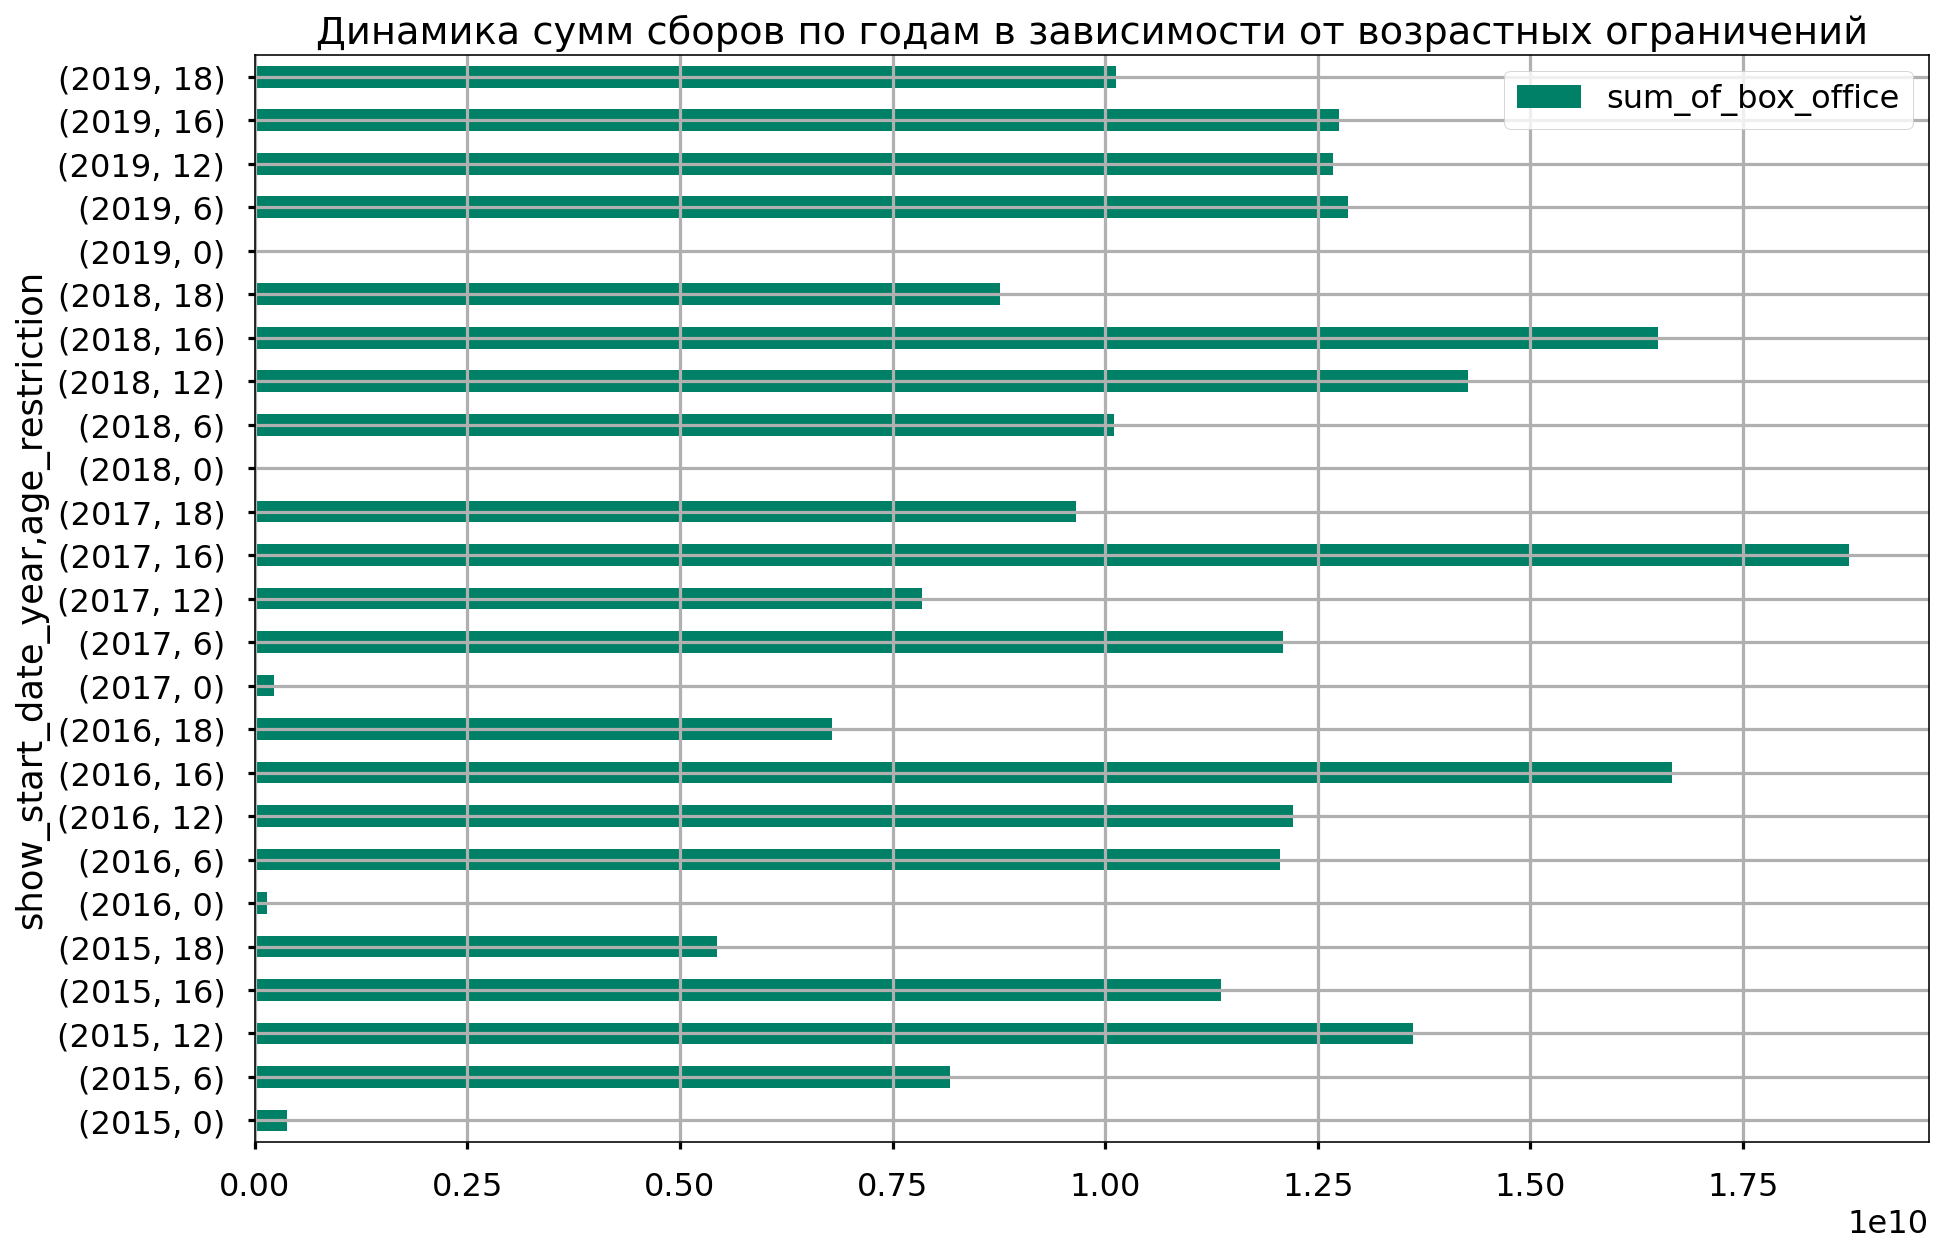

In [80]:
# делаю срез фильмов после 2015 года и за каждый год отдельно
movies_shows_box_office_after_2015 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] >= 2015]

# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_after_2015_pivot = movies_shows_box_office_after_2015.pivot_table(
    index=['show_start_date_year', 'age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_after_2015_pivot`
movies_shows_box_office_after_2015_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

movies_shows_box_office_after_2015_pivot['sum_of_box_office'].plot(
        title='Динамика сумм сборов по годам в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='barh',
        grid=True,
        figsize=(15,10),
        colormap='summer',
        legend=True)

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_after_2015_pivot.T

In [98]:
movies_shows_box_office_after_2015['box_office'].describe()

count         2337.00
mean      99906097.86
std      272113173.01
min            100.00
25%        1263461.52
50%        5984473.00
75%       46769961.08
max     3073568690.79
Name: box_office, dtype: float64

In [81]:
movies_shows_2017 = movies_shows[movies_shows['show_start_date_year'] == 2017]

movies_shows_2017[movies_shows_2017['box_office'] == movies_shows_2017['box_office'].max()] 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,show_start_date_year,main_director,main_genre,share_of_government_support
5117,движение вверх,111011817,2017-12-21 12:00:00+00:00,художественный,ооо студия тритэ никиты михалкова,россия,а.мегердичев,"л.верещагин, а.златопольский, н.михалков, студия тритэ никиты михалкова",6,0.00,400000000.00,590192191.00,фонд кино,7.50,"спорт, драма",2779686144.00,2017,а.мегердичев,спорт,0.68


<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамику сборов по годам**

Общий график изменения сумм сборов с группировкой по годам и возрастным ограничениям наглядно отражает минимальные суммы сборов фильмов для "детских фильмов" (ограничений возрастной категории "0+") в каждом из анализируемых периодов.
    
В то же время максимальные сборы:
    - в 2016-2018 годы у фильмов с возрастным ограничением "16+";
    - в 2015-ом году — "12+";
    - в 2019-ом году — "6+"
    
Также отмечу, что в 2019-ом году суммы сборов по категориям: "6+", "12+", "16+" примерно равны. В то время как в 2017-ом году у возрастного ограничения "16+" значительное превышение по сборам. На это, видимо, повлияла большая сумма сборов фильма "Движение вверх" с возрастным ограничением — "6+".  
    
На следующих этапах отдельно проанализирую разницы в суммах кассовых сборов за каждый анализируемый год.
    
</div>

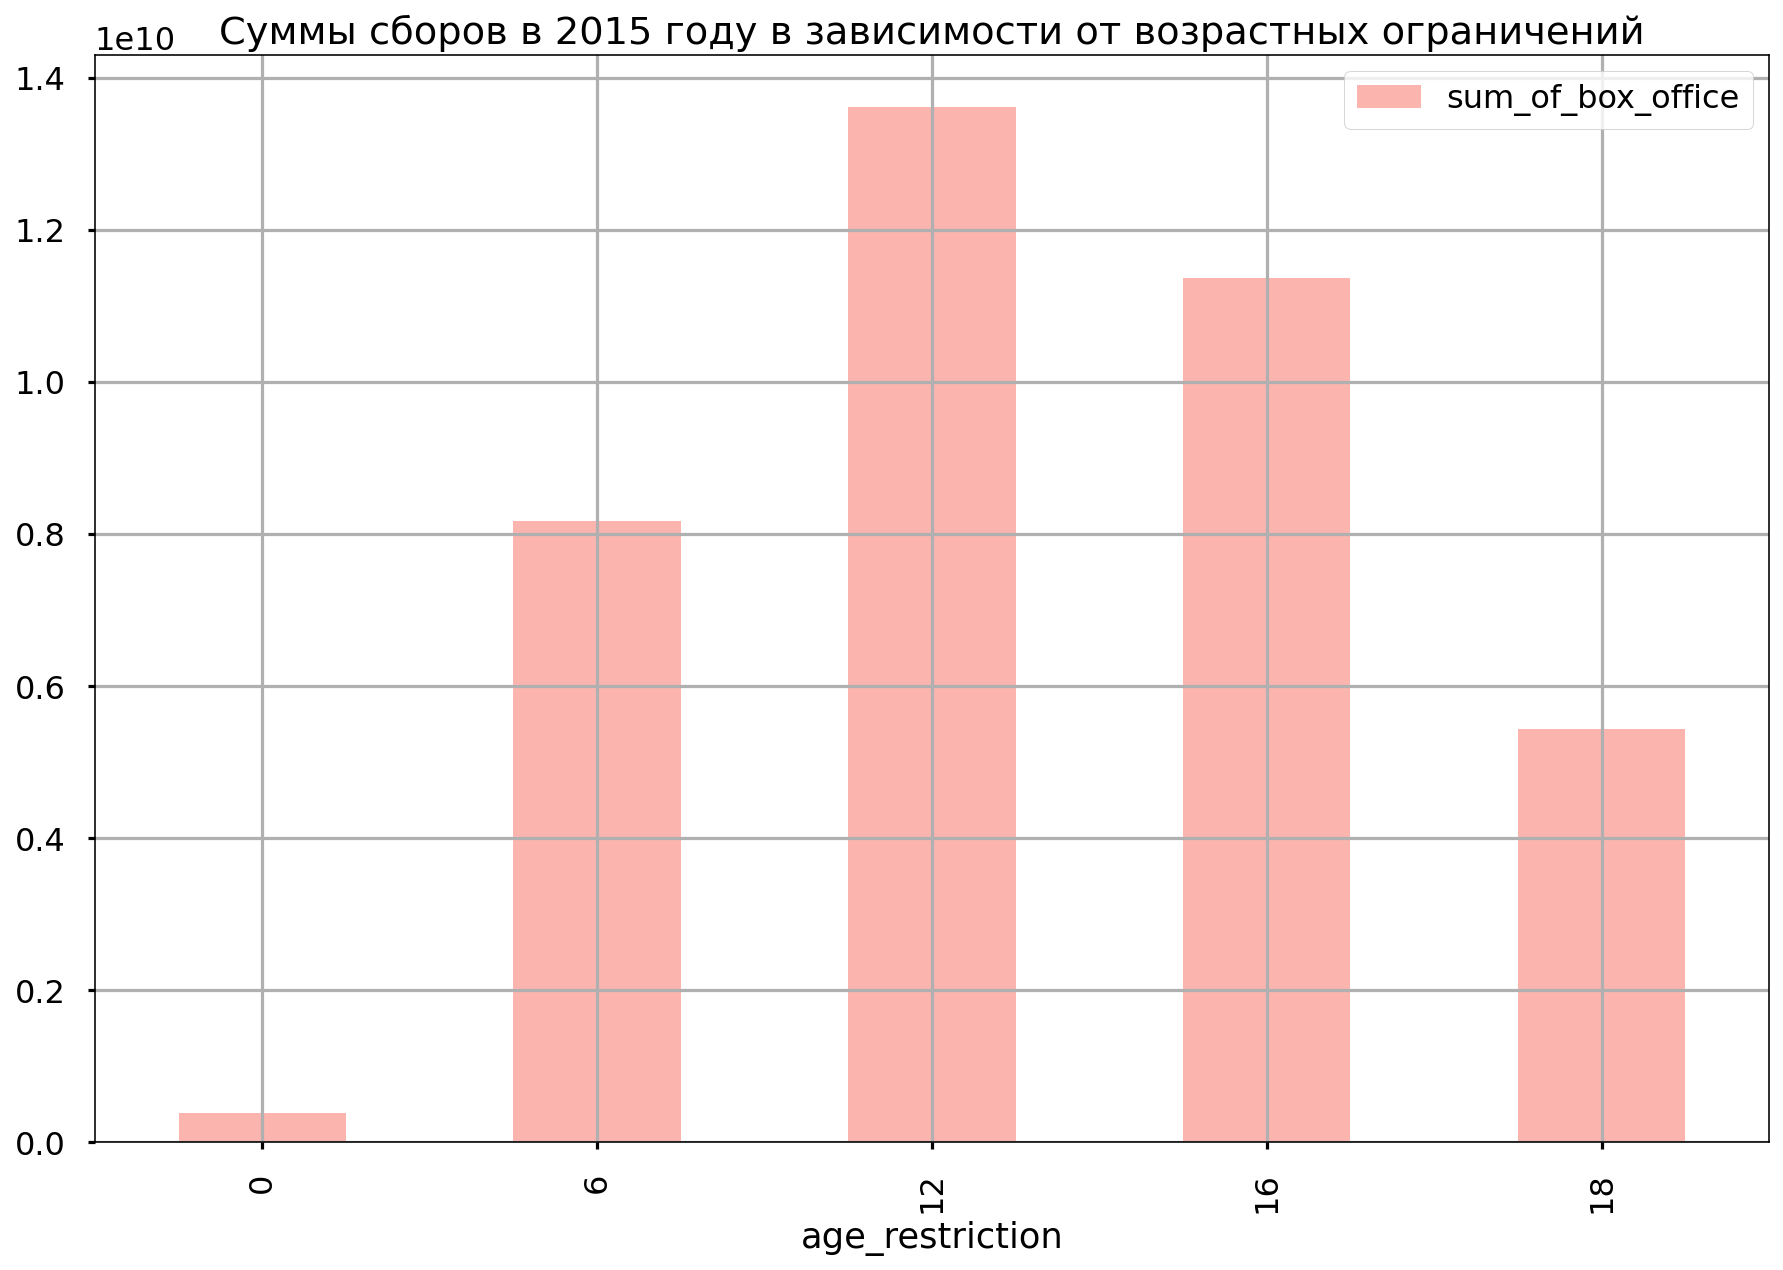

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office,median_sum_of_box_office
age_restriction,,,,
0,38,379054578.37,9975120.48,2949808.55
6,51,8172732063.71,160249648.31,20380982.20
12,72,13616082008.91,189112250.12,15959668.30
16,166,11367319500.27,68477828.31,4878669.70
18,131,5430878508.44,41457087.85,4654761.40


In [82]:
# делаю срез фильмов за каждый год отдельно после 2015 года
movies_shows_box_office_2015 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] == 2015]
movies_shows_box_office_2016 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] == 2016]
movies_shows_box_office_2017 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] == 2017]
movies_shows_box_office_2018 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] == 2018]
movies_shows_box_office_2019 = movies_shows_box_office[movies_shows_box_office['show_start_date_year'] == 2019]

# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_2015_pivot = movies_shows_box_office_2015.pivot_table(
    index=['age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_after_2015_pivot`
movies_shows_box_office_2015_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

# график динамики сумм сборов в 2015 году в зависимости от возрастных ограничений 
movies_shows_box_office_2015_pivot['sum_of_box_office'].plot(
        title='Суммы сборов в 2015 году в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='bar',
        grid=True,
        figsize=(15,10),
        colormap='Pastel1',
        legend=True)
plt.show()

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_2015_pivot

In [99]:
movies_shows_box_office_2015['box_office'].describe()

count          458.00
mean      85078748.17
std      220657001.40
min            100.00
25%         784145.75
50%        5104961.45
75%       43500347.77
max     1658861425.50
Name: box_office, dtype: float64

<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамике сборов в 2015 году**

В 2015 году лидером по суммам сборов стала категория "12+", в то время как эта категория лишь третья по количеству фильмов в прокате.     
</div>

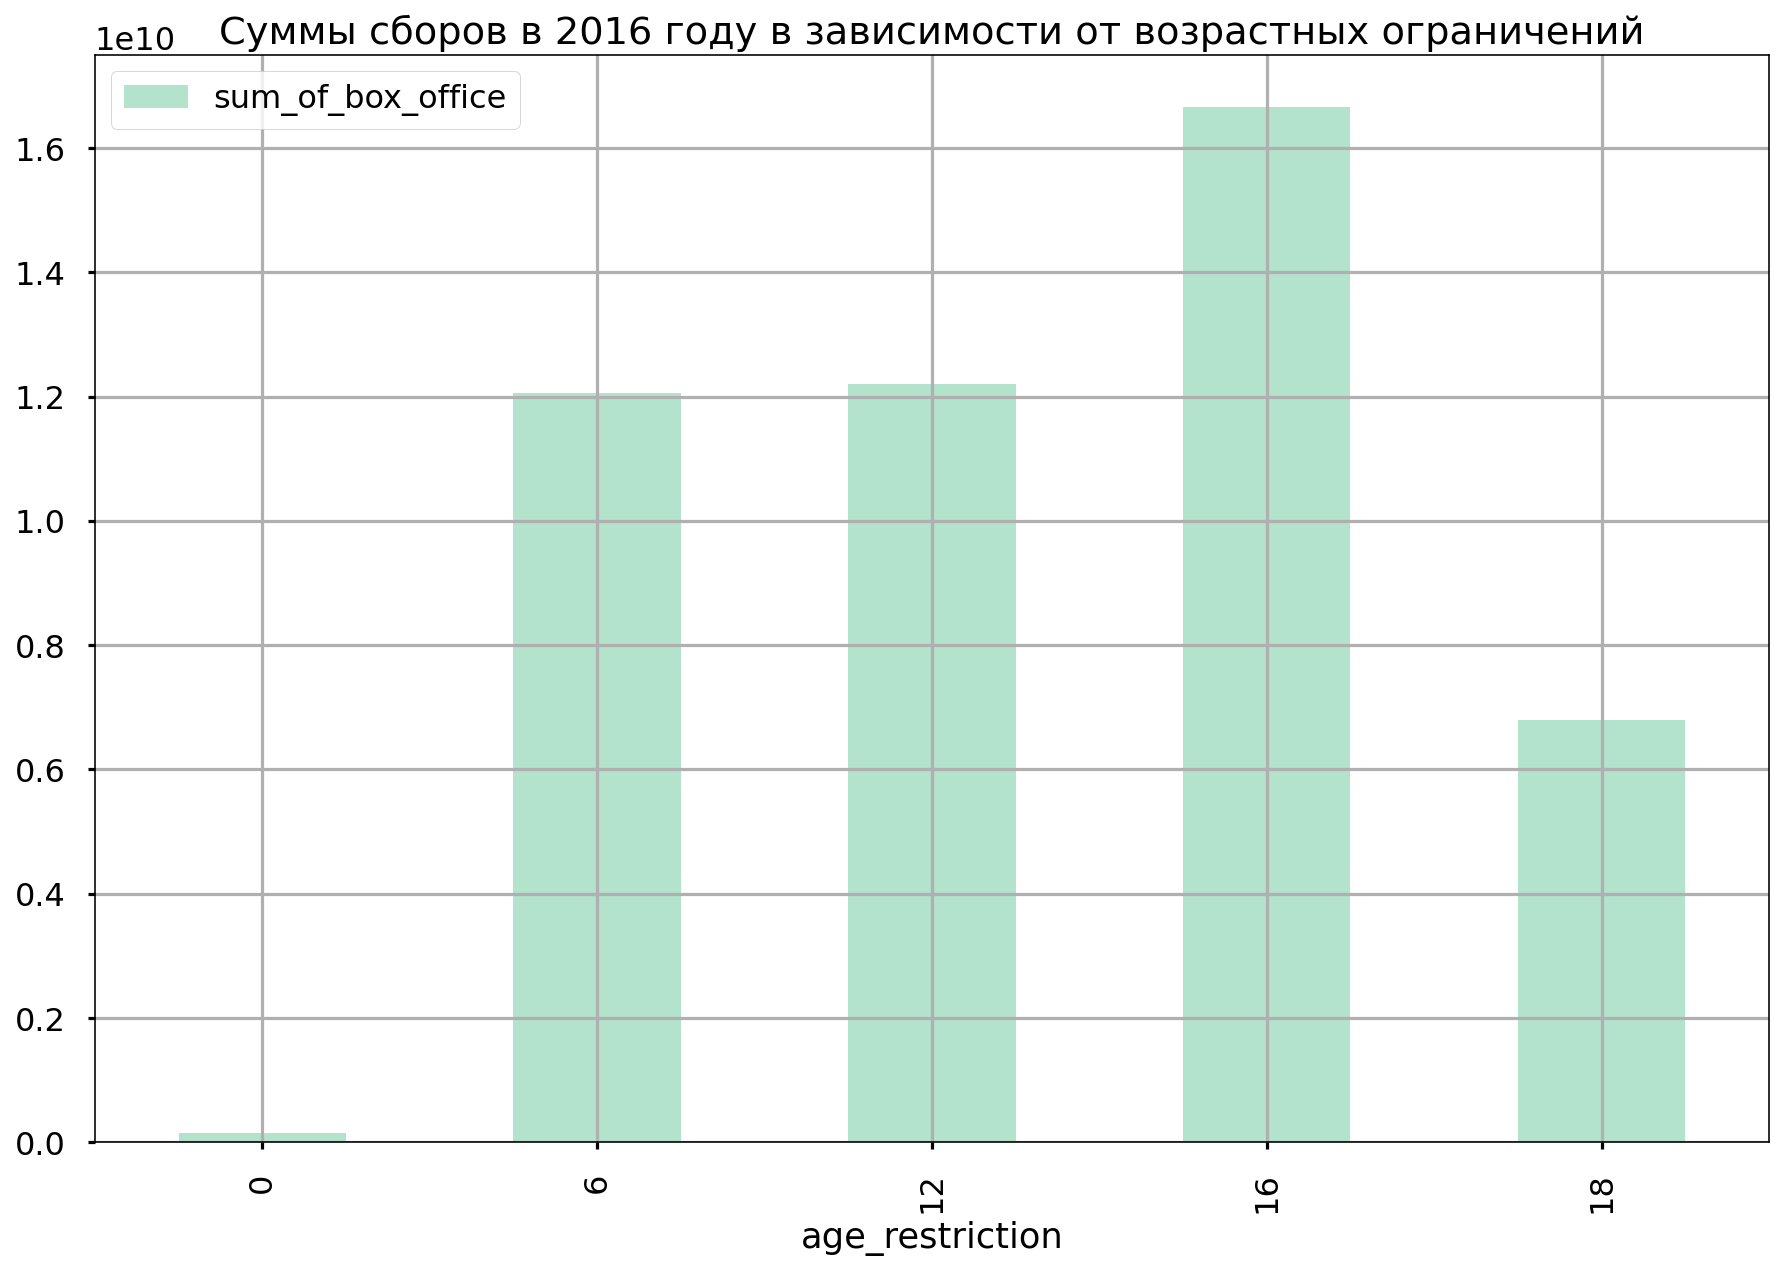

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office,median_sum_of_box_office
age_restriction,,,,
0,41,150228848.67,3664118.26,2571294.10
6,70,12053146008.24,172187800.12,3026256.15
12,82,12204446524.39,148834713.71,4690635.25
16,180,16664465701.74,92580365.01,5281042.10
18,149,6790637473.87,45574748.15,6375092.00


In [83]:
# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_2016_pivot = movies_shows_box_office_2016.pivot_table(
    index=['age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_2016_pivot`
movies_shows_box_office_2016_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

# график динамики сумм сборов в 2016 году в зависимости от возрастных ограничений 
movies_shows_box_office_2016_pivot['sum_of_box_office'].plot(
        title='Суммы сборов в 2016 году в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='bar',
        grid=True,
        figsize=(15,10),
        colormap='Pastel2',
        legend=True)
plt.show()

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_2016_pivot

In [100]:
movies_shows_box_office_2016['box_office'].describe()

count          522.00
mean      91691426.35
std      251881346.96
min            200.00
25%         597504.75
50%        4002836.25
75%       39340322.56
max     2048126108.00
Name: box_office, dtype: float64

<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамике сборов в 2016 году**

В 2016 году лидером по суммам сборов стала категория "16+", в этой категории было снято больше всего фильмов в прокате в анализируемом году.     
</div>

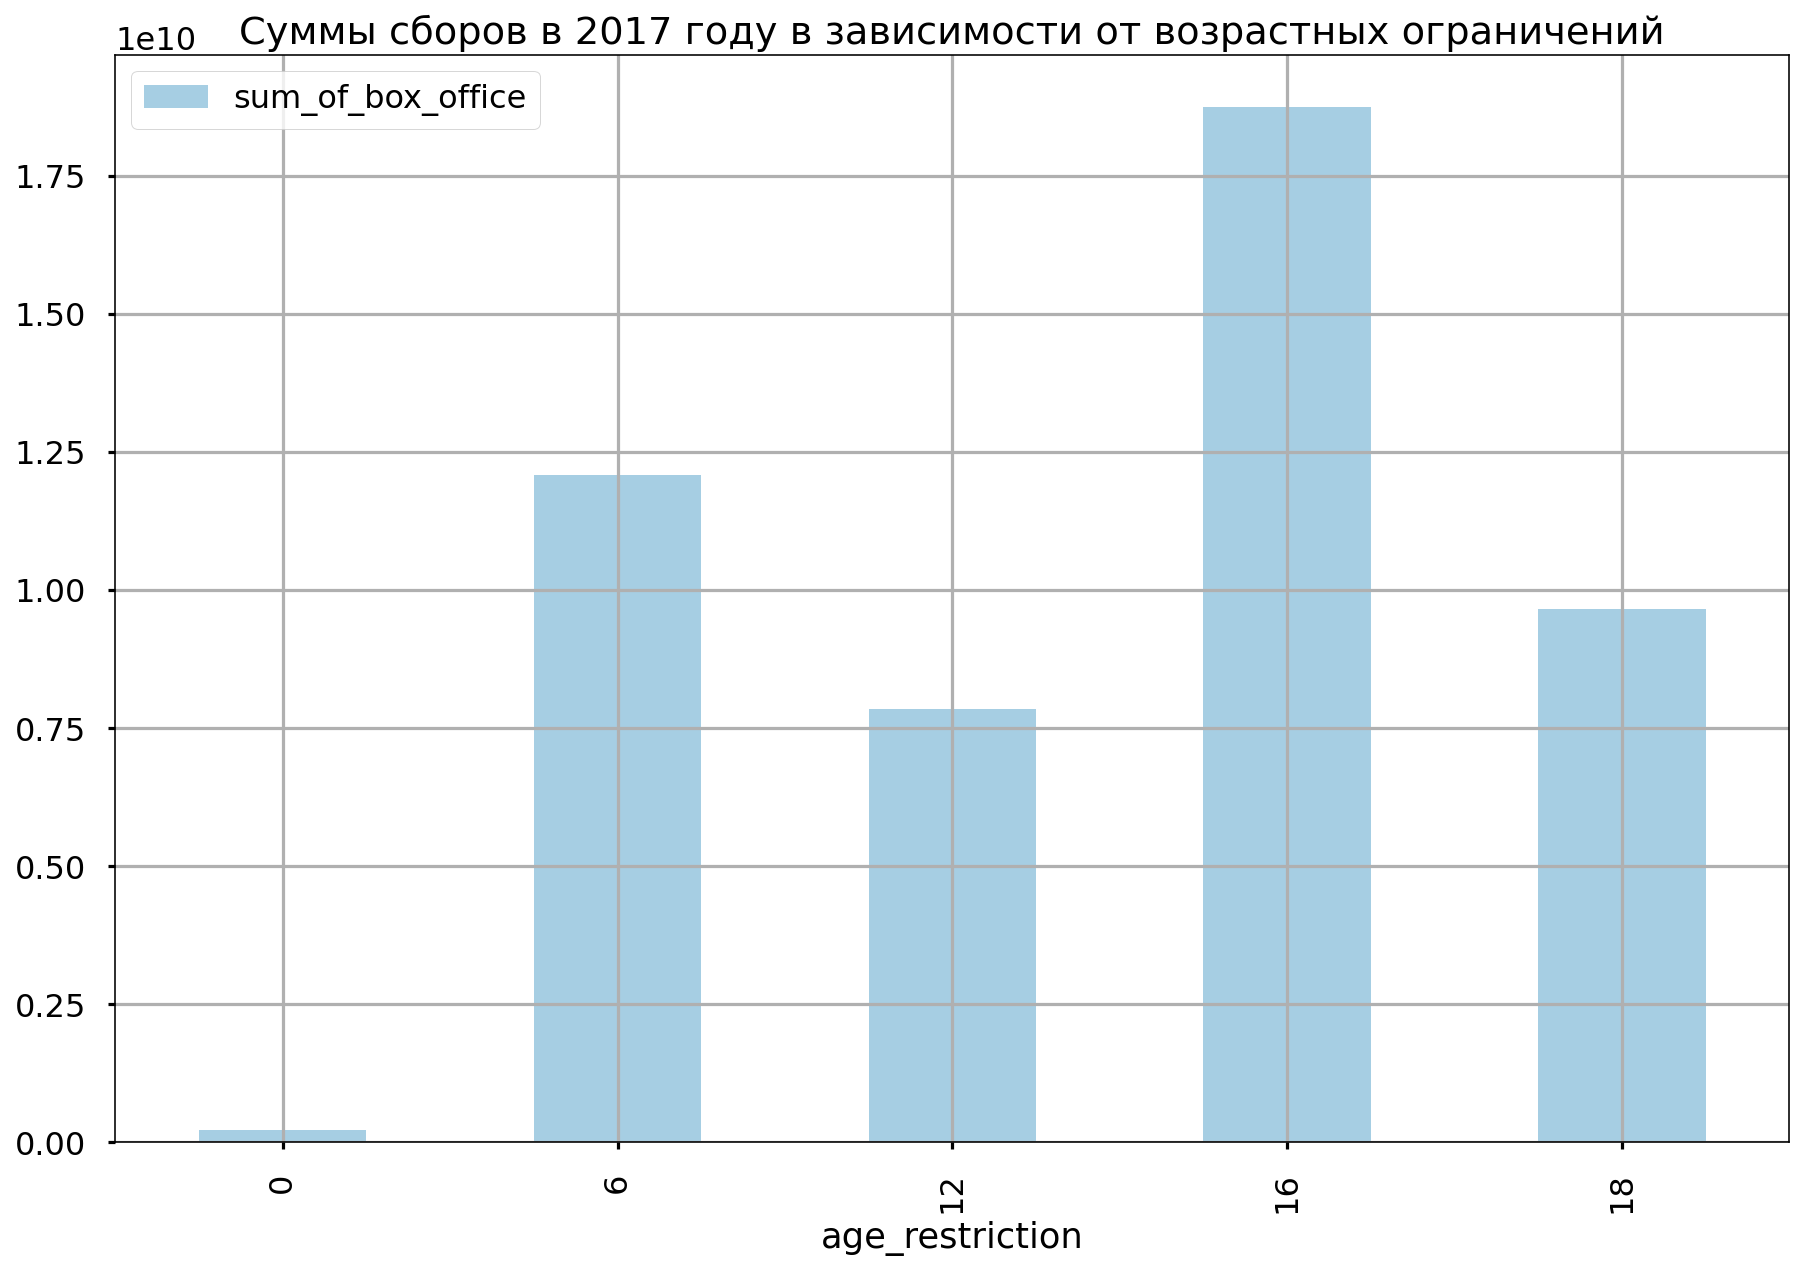

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office,median_sum_of_box_office
age_restriction,,,,
0,3,229598930.00,76532976.67,22178956.00
6,45,12086142145.76,268580936.57,51992103.00
12,40,7851389700.67,196284742.52,13217268.50
16,121,18745042900.06,154917709.92,9702077.00
18,147,9651495581.02,65656432.52,8212677.00


In [84]:
# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_2017_pivot = movies_shows_box_office_2017.pivot_table(
    index=['age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_2017_pivot`
movies_shows_box_office_2017_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

# график динамики сумм сборов в 2017 году в зависимости от возрастных ограничений 
movies_shows_box_office_2017_pivot['sum_of_box_office'].plot(
        title='Суммы сборов в 2017 году в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='bar',
        grid=True,
        figsize=(15,10),
        colormap='Paired',
        legend=True)
plt.show()

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_2017_pivot

In [101]:
movies_shows_box_office_2017['box_office'].describe()

count          356.00
mean     136414801.29
std      323625698.20
min           7900.00
25%        2010992.25
50%       10177833.50
75%       72319114.25
max     2779686144.00
Name: box_office, dtype: float64

<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамике сборов в 2017 году**

В 2017 году лидером по суммам сборов стала категория "16+", а лидером по количеству фильмов в прокате стала категория "18+".     
</div>

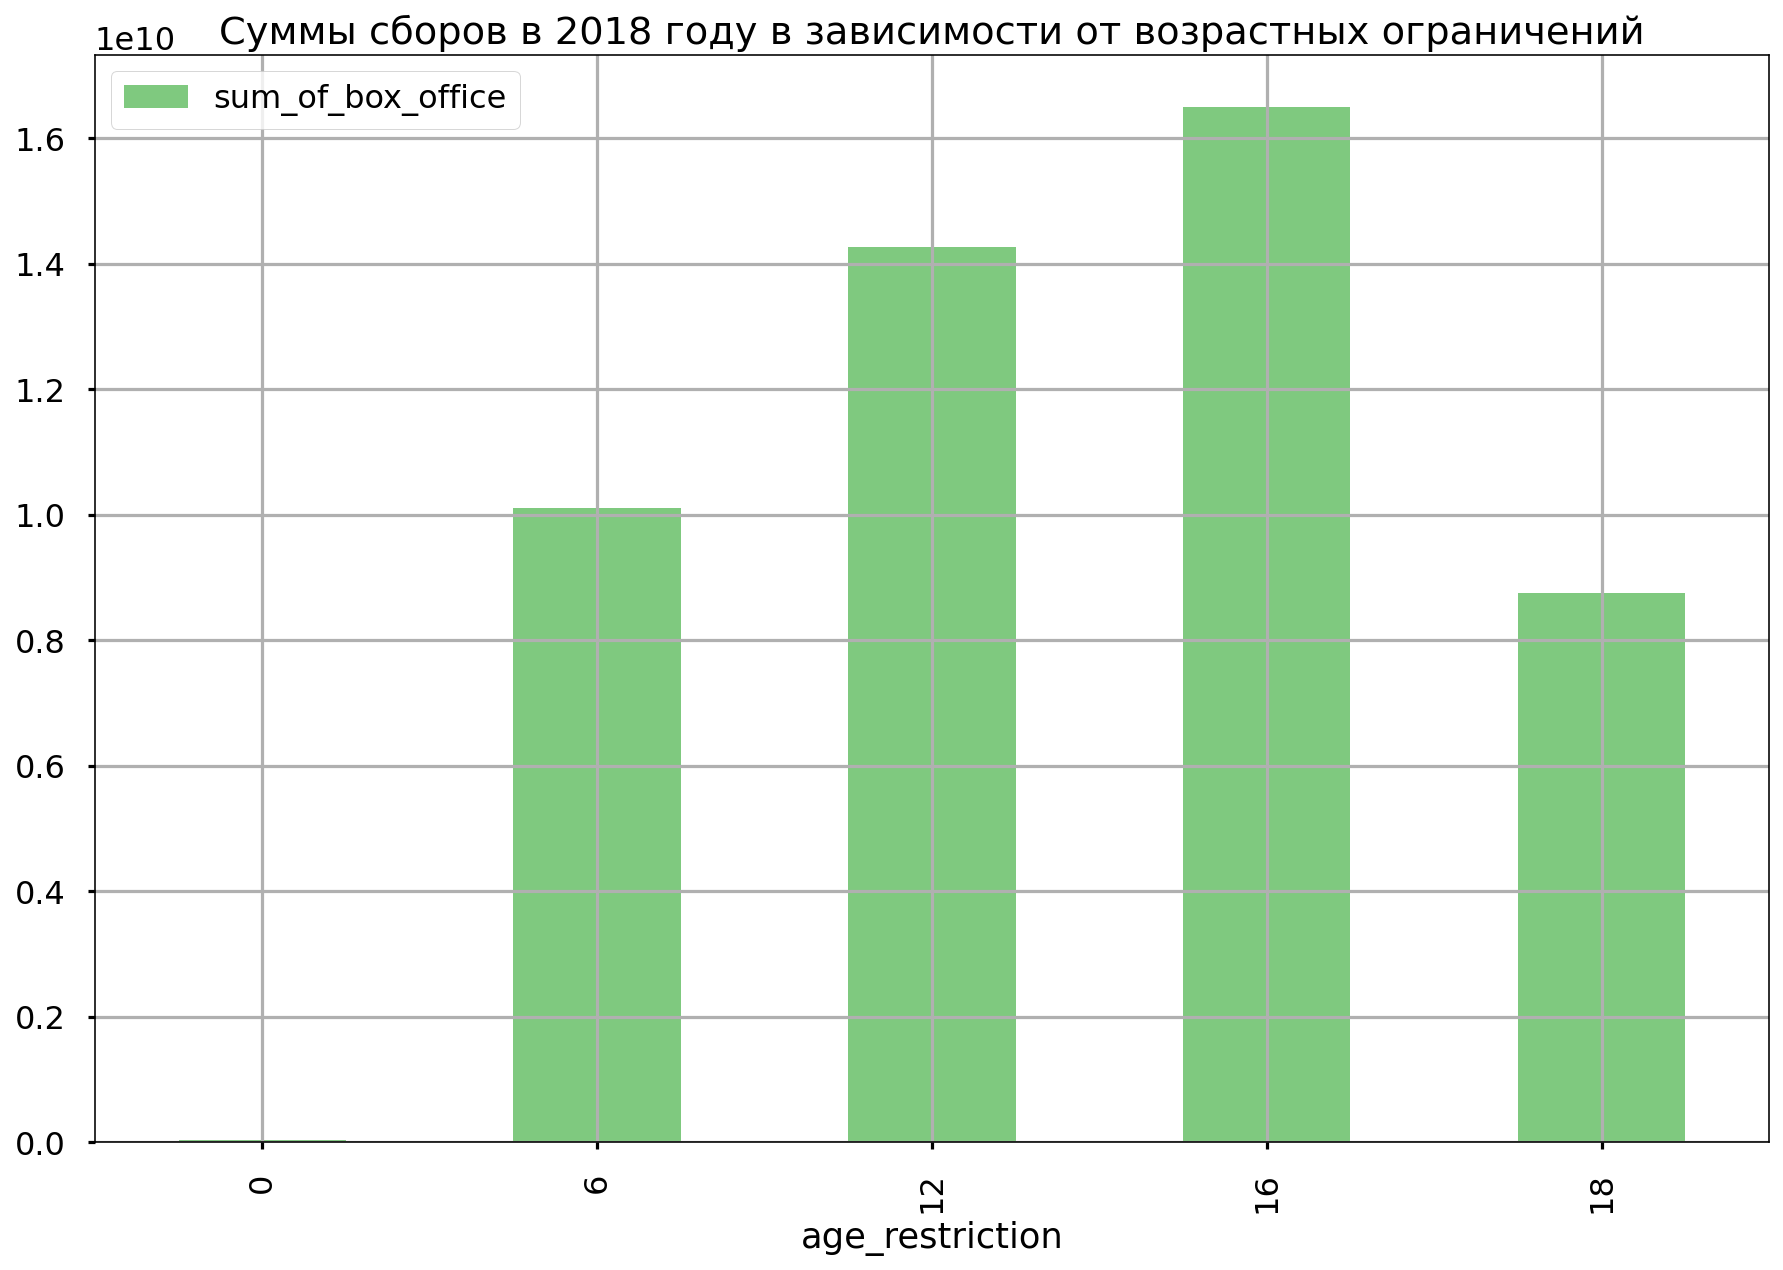

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office,median_sum_of_box_office
age_restriction,,,,
0,5,32449002.11,6489800.42,3616937.28
6,68,10104974623.41,148602567.99,14688850.32
12,67,14267291660.69,212944651.65,8931965.66
16,156,16503602346.96,105792322.74,9010638.62
18,178,8758498279.64,49205046.51,7604029.00


In [85]:
# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_2018_pivot = movies_shows_box_office_2018.pivot_table(
    index=['age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_2018_pivot`
movies_shows_box_office_2018_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

# график динамики сумм сборов в 2018 году в зависимости от возрастных ограничений 
movies_shows_box_office_2018_pivot['sum_of_box_office'].plot(
        title='Суммы сборов в 2018 году в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='bar',
        grid=True,
        figsize=(15,10),
        colormap='Accent',
        legend=True)
plt.show()

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_2018_pivot

In [102]:
movies_shows_box_office_2018['box_office'].describe()

count          474.00
mean     104782312.05
std      272325223.20
min          41225.00
25%        2432635.67
50%        8911533.94
75%       60308014.17
max     2271754004.52
Name: box_office, dtype: float64

<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамике сборов в 2018 году**

Как и в предыдущем, в 2018 году лидером по суммам сборов стала категория "16+", а лидером по количеству фильмов в прокате стала категория "18+".     
</div>

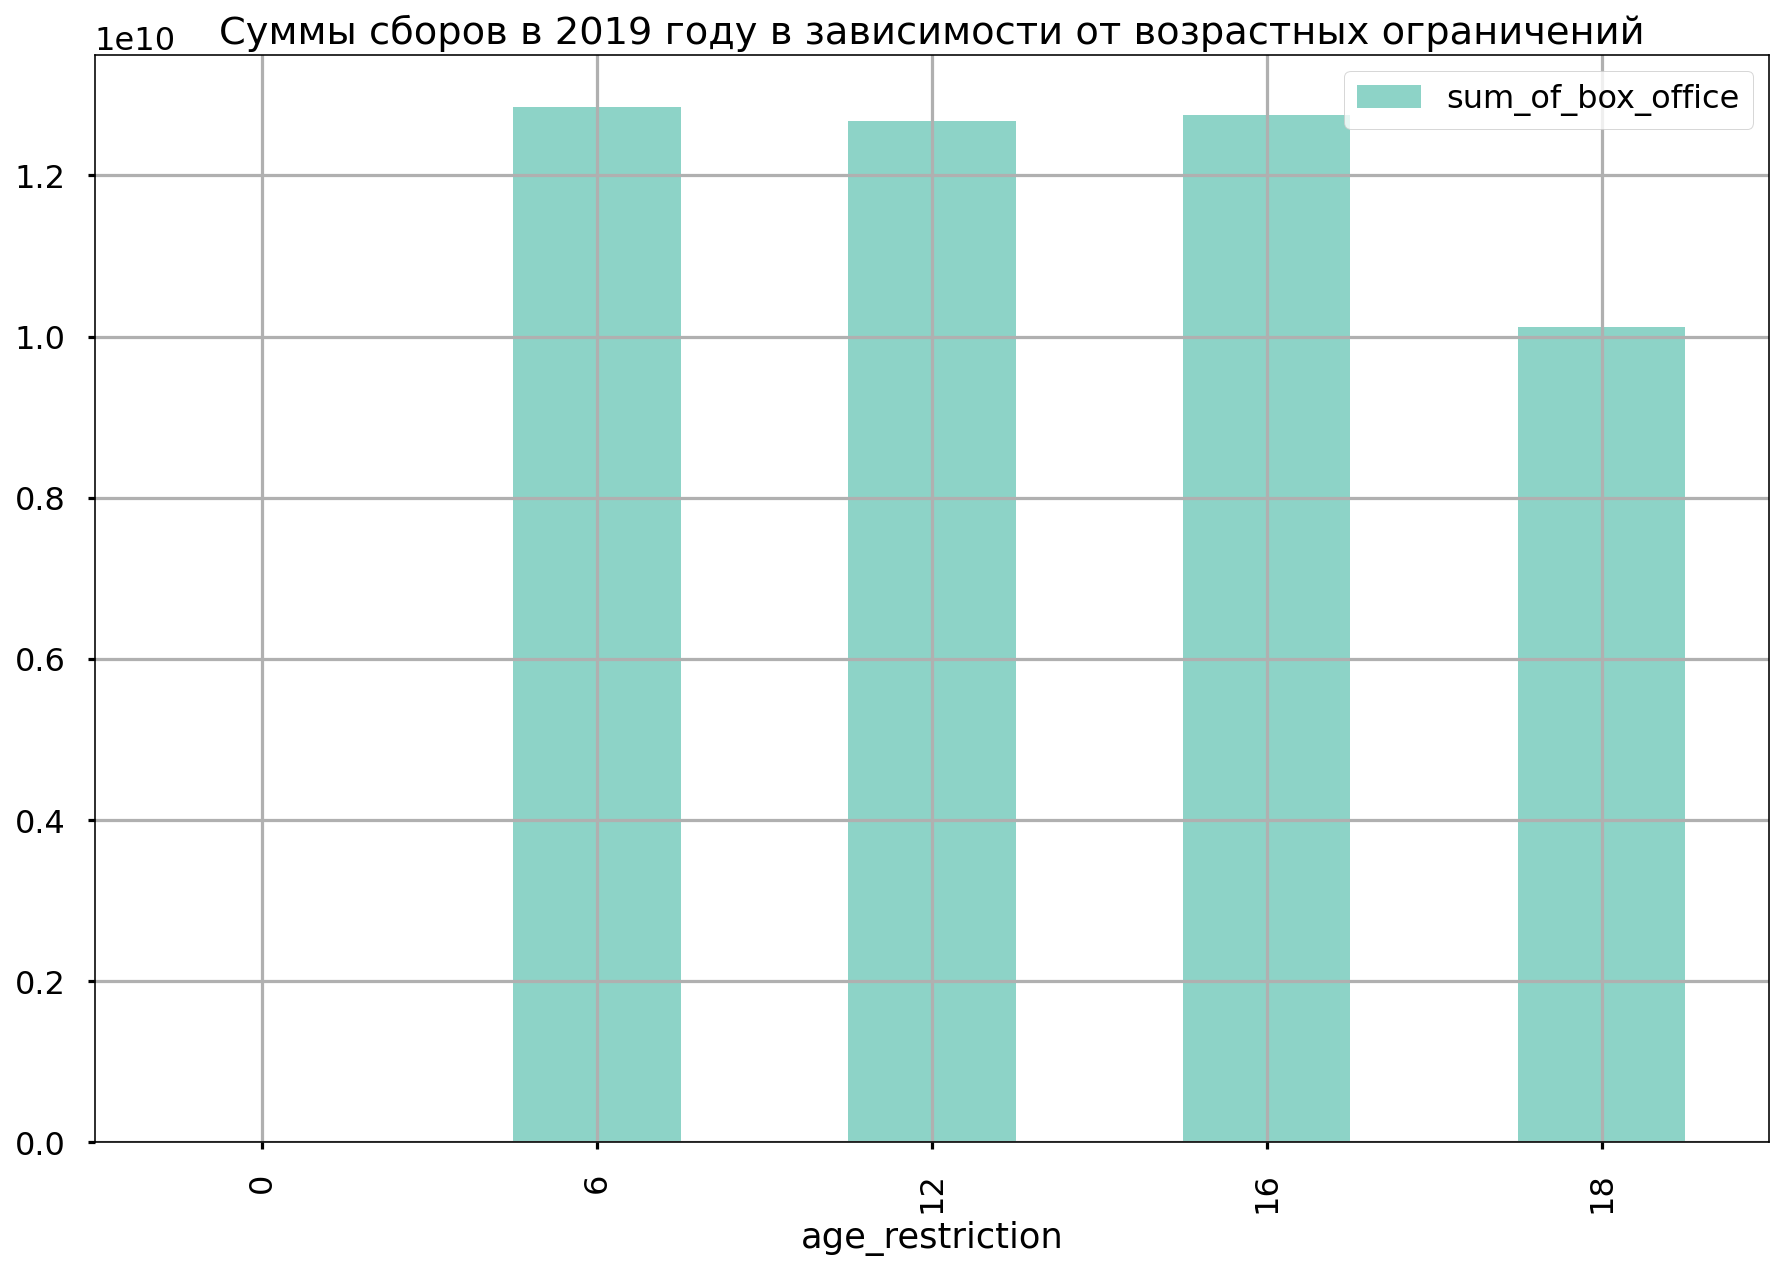

,numbers_of_box_office,sum_of_box_office,average_sum_of_box_office,median_sum_of_box_office
age_restriction,,,,
0,3,17746066.82,5915355.61,3885434.50
6,80,12852513658.86,160656420.74,14199614.88
12,85,12680198773.67,149178809.10,3405545.76
16,176,12748819511.65,72436474.50,3210717.81
18,183,10121796303.64,55310362.31,5603216.55


In [86]:
# создаю переменную со сводной таблицей по сборам в 2015 году в зависимости от возрастных ограничений
movies_shows_box_office_2019_pivot = movies_shows_box_office_2019.pivot_table(
    index=['age_restriction'],
    values=['box_office'],
    aggfunc=['count', 'sum', 'mean', 'median']) 
# присваиваю названия столбцам сводной таблицы `movies_shows_box_office_after_2019_pivot`
movies_shows_box_office_2019_pivot.columns = [
        'numbers_of_box_office', 
        'sum_of_box_office', 
        'average_sum_of_box_office', 
        'median_sum_of_box_office']

# график динамики сумм сборов в 2019 году в зависимости от возрастных ограничений 
movies_shows_box_office_2019_pivot['sum_of_box_office'].plot(
        title='Суммы сборов в 2019 году в зависимости от возрастных ограничений',
        x='age_restriction',
        kind='bar',
        grid=True,
        figsize=(15,10),
        colormap='Set3',
        legend=True)
plt.show()

# вывожу сводную таблицу по влиянию возрастных ограничений на сборы по годам
movies_shows_box_office_2019_pivot

In [103]:
movies_shows_box_office_2019['box_office'].describe()

count          527.00
mean      91880596.42
std      291680269.18
min           4398.40
25%        1395076.75
50%        4732610.10
75%       38636118.17
max     3073568690.79
Name: box_office, dtype: float64

<div class="alert alert-info">
    
**Вывод по влиянию возрастных ограничений на динамике сборов в 2019 году**

В 2019 году лидером по суммам сборов стала категория "6+", в то время как по количеству фильмов в прокате эта возрастная категория лишь на четвёртом месте".     
</div>

- Из данных сводной видно, что лидером по суммарным сборам является категория фильмов с возрастными ограничениями "16+", в этой же категории самое большое количество фильмов в прокате. Чтобы нивелировать влияние количества сравню средние и медианные значения.   

- Лидерами по этим показателям являются категории "12+" и "6+", причём превышение значительное, в некоторых случаях более чем в два раза. Для подробного анализа сравню эти показатели отдельно за каждый из анализируемых периодов.

<div class="alert alert-info">
    
**Общий вывод по влиянию возрастных ограничений на динамику сборов по годам**

Анализ влияния возрастных ограничений на динамику сборов показал низкую корреляцию показателей ограничений с кассовыми сборами. 
    
В каждый из периодов лидером по сборам могли быть фильмы разных возрастных категорий как по количеству, так и по сумме сборов в прокате. Таким образом, напрямую возрастное ограничение скорее не влияет на популярность отдельных картин.
    
</div>

<div class="alert alert-success">
    
**Комментарий ревьюера - 2**

**#ок**

Да, теперь анализ намного более наглядный, здорово.
</div>

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Ты делаешь верные выводы на основании вполне корректных расчетов.

Но я посоветовала бы чуть активнее использовать визуализацию. Да, нам как аналитикам, возможно, вполне комфортно работать с большим количеством таблиц. Но заказчикам это часто не привычно. Наша задача скорее подать информацию в наиболее удобной и понятной форме.

Часто простой график вот такого типа(оформление можно доработать) будет намного понятнее нескольких таблиц.

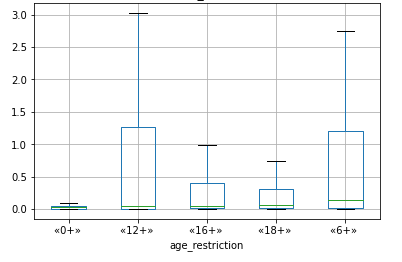

</div>

## Исследование среза с фильмами, получившими государственную поддержку.


Для исследования фильмов с госуарственной поддержкой выделяю такие фильмы в отдельный датафрейм и вывожу общую информацию о нём.

In [87]:
films_with_government_support = movies_shows[~(movies_shows['budget'].isna()) & (movies_shows['budget'] != 0)]
films_with_government_support.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 330 entries, 1188 to 6919
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   title                        330 non-null    object             
 1   puNumber                     330 non-null    int64              
 2   show_start_date              330 non-null    datetime64[ns, UTC]
 3   type                         330 non-null    object             
 4   film_studio                  330 non-null    object             
 5   production_country           330 non-null    object             
 6   director                     330 non-null    object             
 7   producer                     330 non-null    object             
 8   age_restriction              330 non-null    int64              
 9   refundable_support           330 non-null    float64            
 10  nonrefundable_support        330 non-null    f

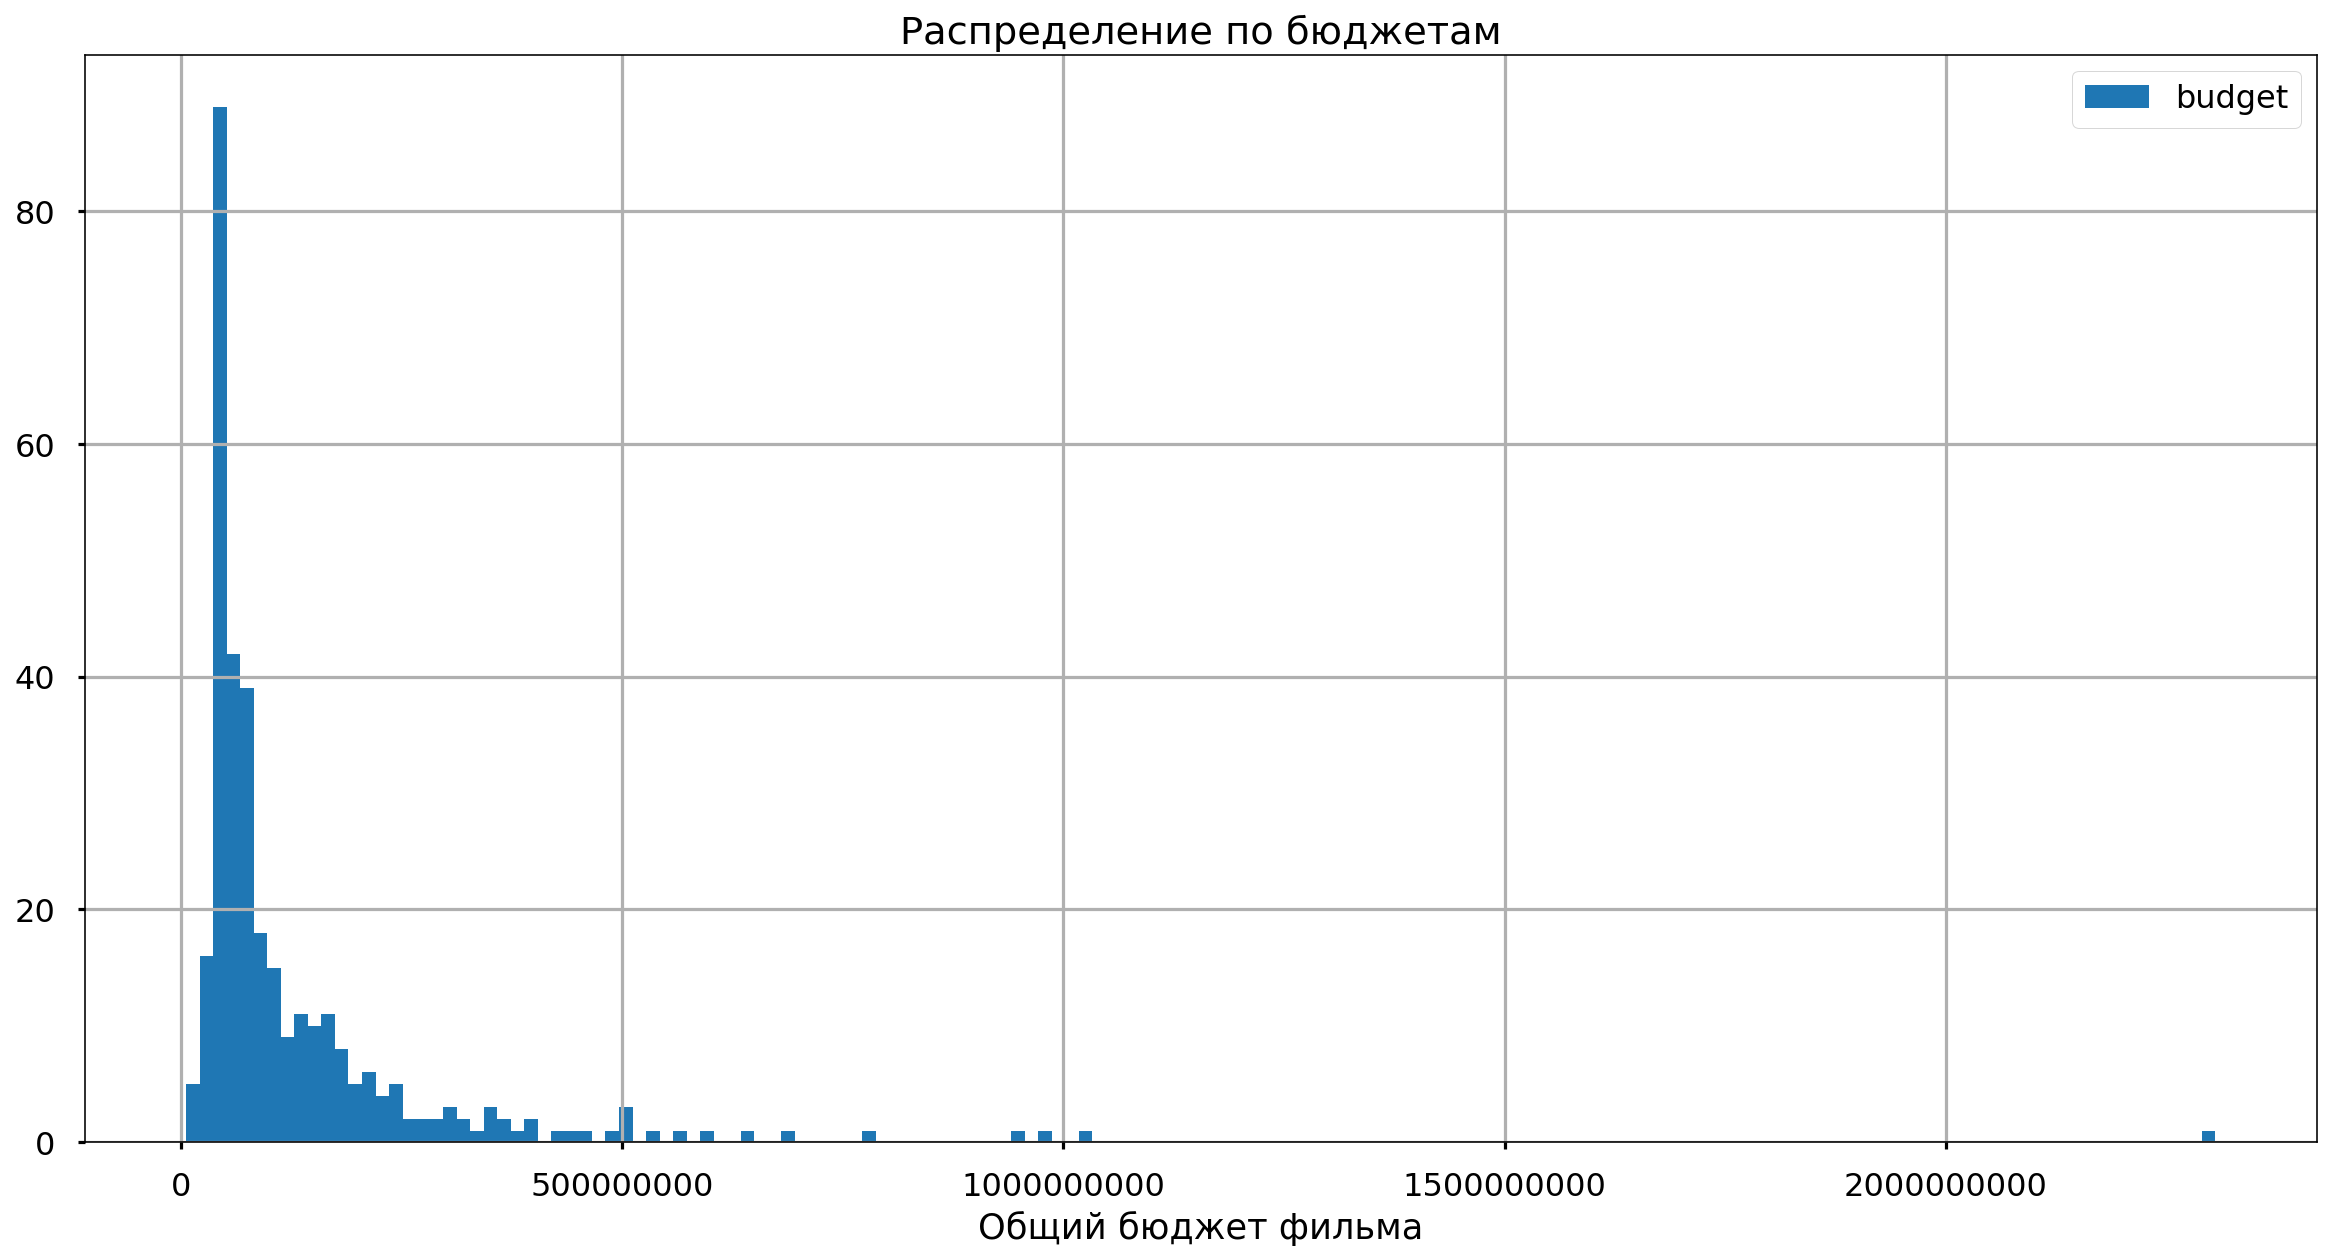

count          330.00
mean     132053857.39
std      187536651.42
min        6000000.00
25%       46153856.25
50%       72448592.50
75%      150000000.00
max     2305074303.00
Name: budget, dtype: float64

In [88]:
# строю гистограмму по количеству фильмов в год
build_hist(
    films_with_government_support.budget, 'Общий бюджет фильма', 'Распределение по бюджетам', 
    figsize=(20, 10), bins=150)
films_with_government_support['budget'].describe()

Минимальный бюджет фильма составляет 6 000 000.00 руб. при медианном значении в 72 448 592.50 и максимальном — 2 305 074 303.00 руб. Такой большой разброс в данных может искажать результаты анализа. Из гистограммы видно, что у большего количества фильмов бюджеты составляют до 200 000 000 руб. Рассмотрю распределение бюджетов в этой категории фильмов.

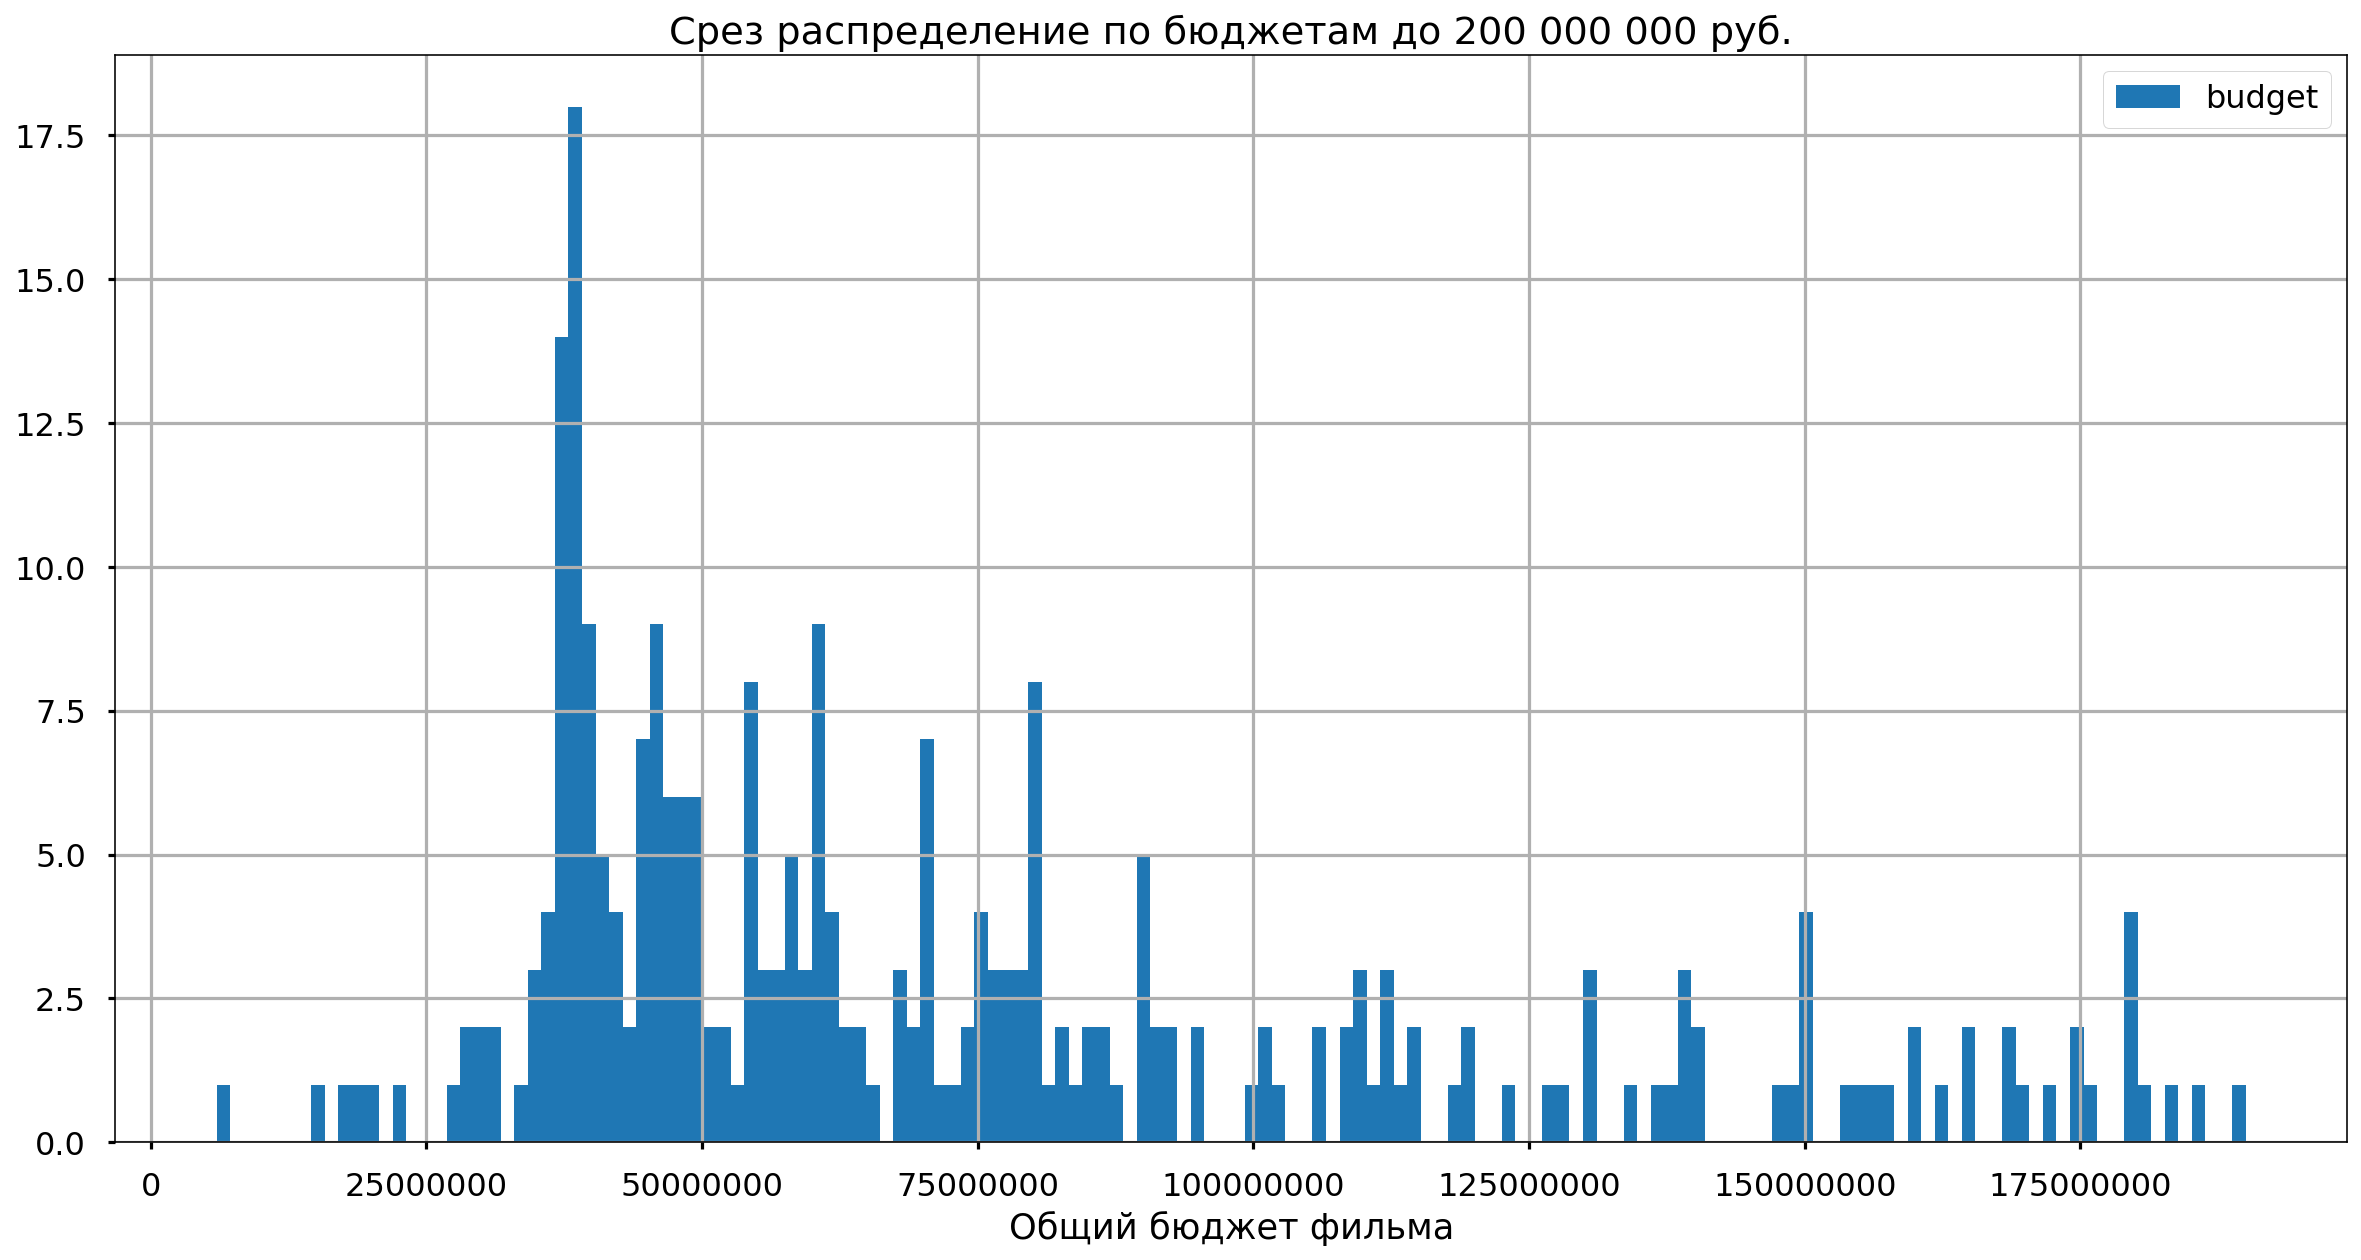

In [89]:
# строю гистограмму по срезу бюдета до 200 000 000 руб.
build_hist(
    films_with_government_support[films_with_government_support['budget'] < 200000000].budget, 
    'Общий бюджет фильма', 'Срез распределение по бюджетам до 200 000 000 руб.', 
    figsize=(20, 10), bins=150)

***Влияние бюджетов фильмов на рейтинги по группам.***   

Проанализирую влияние объемом финансирования на рейтинги.   

Отдельно рассмотрю рейтинги группы фильмов с бюджетом до и более 200 000 000 руб.

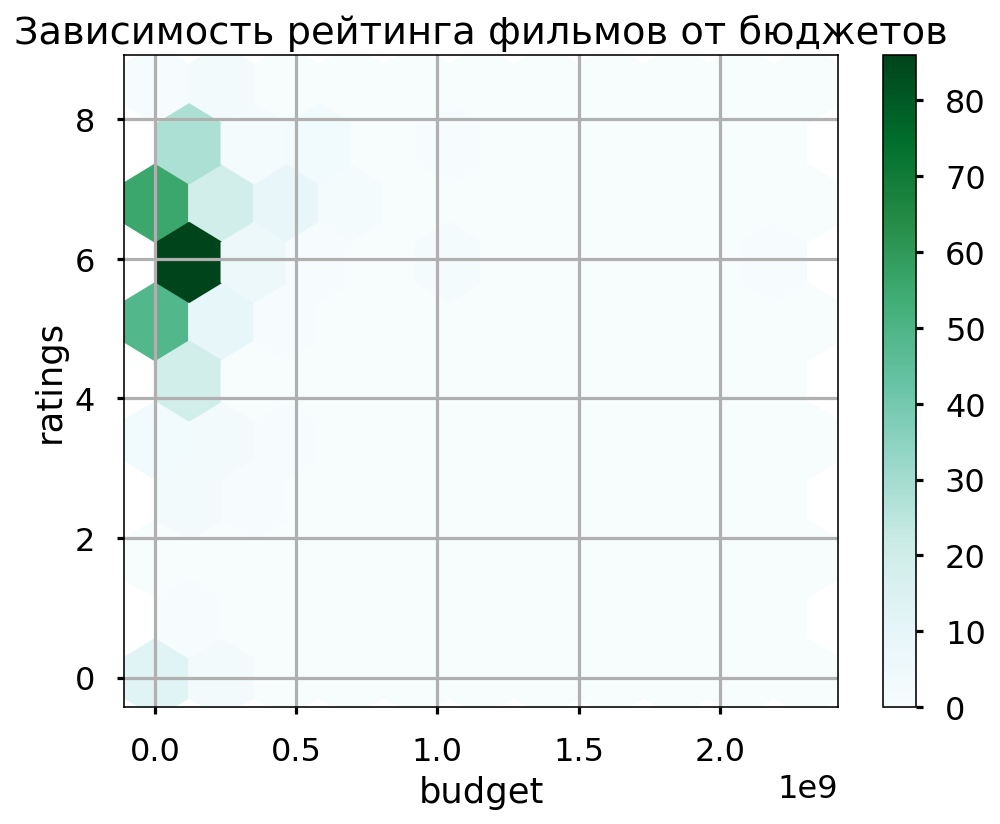

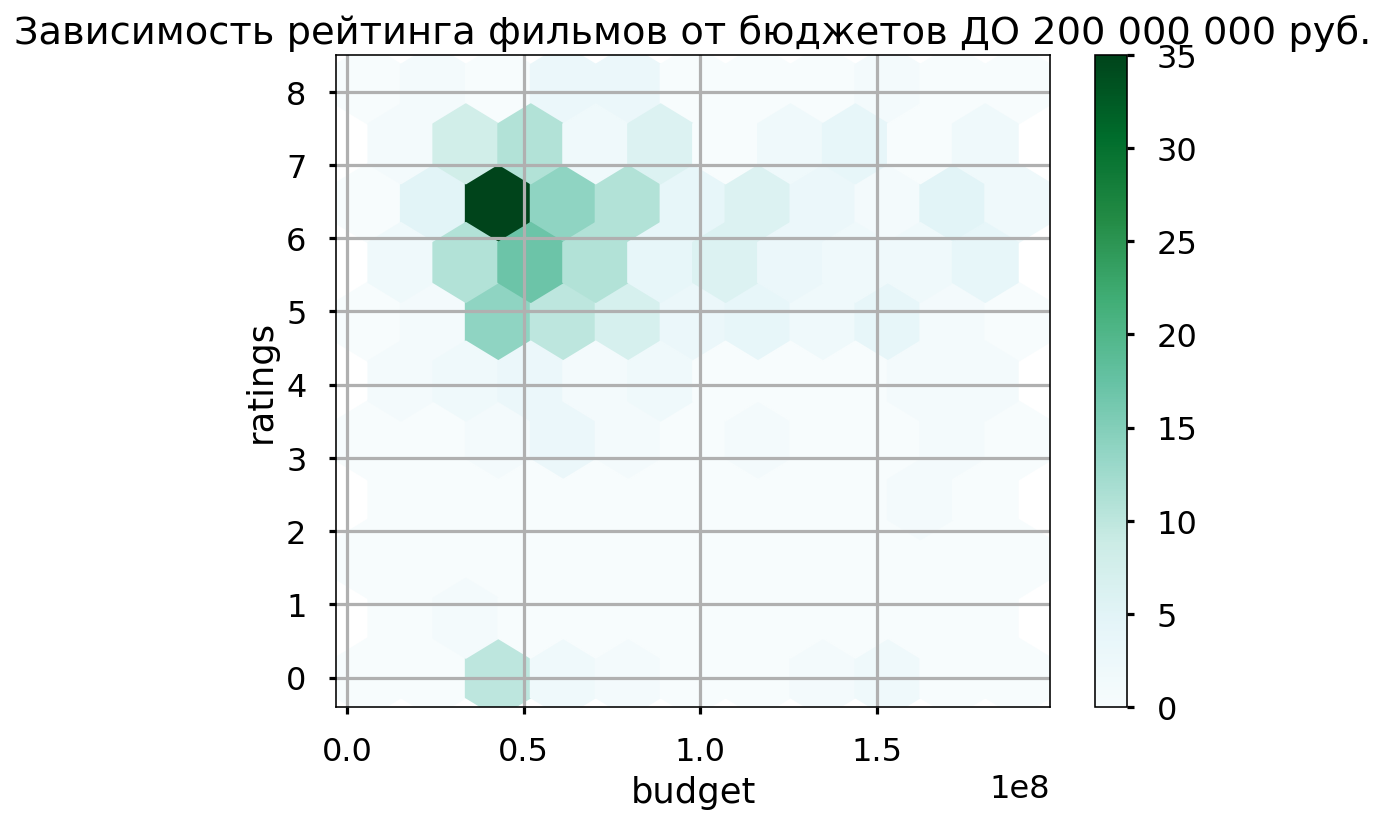

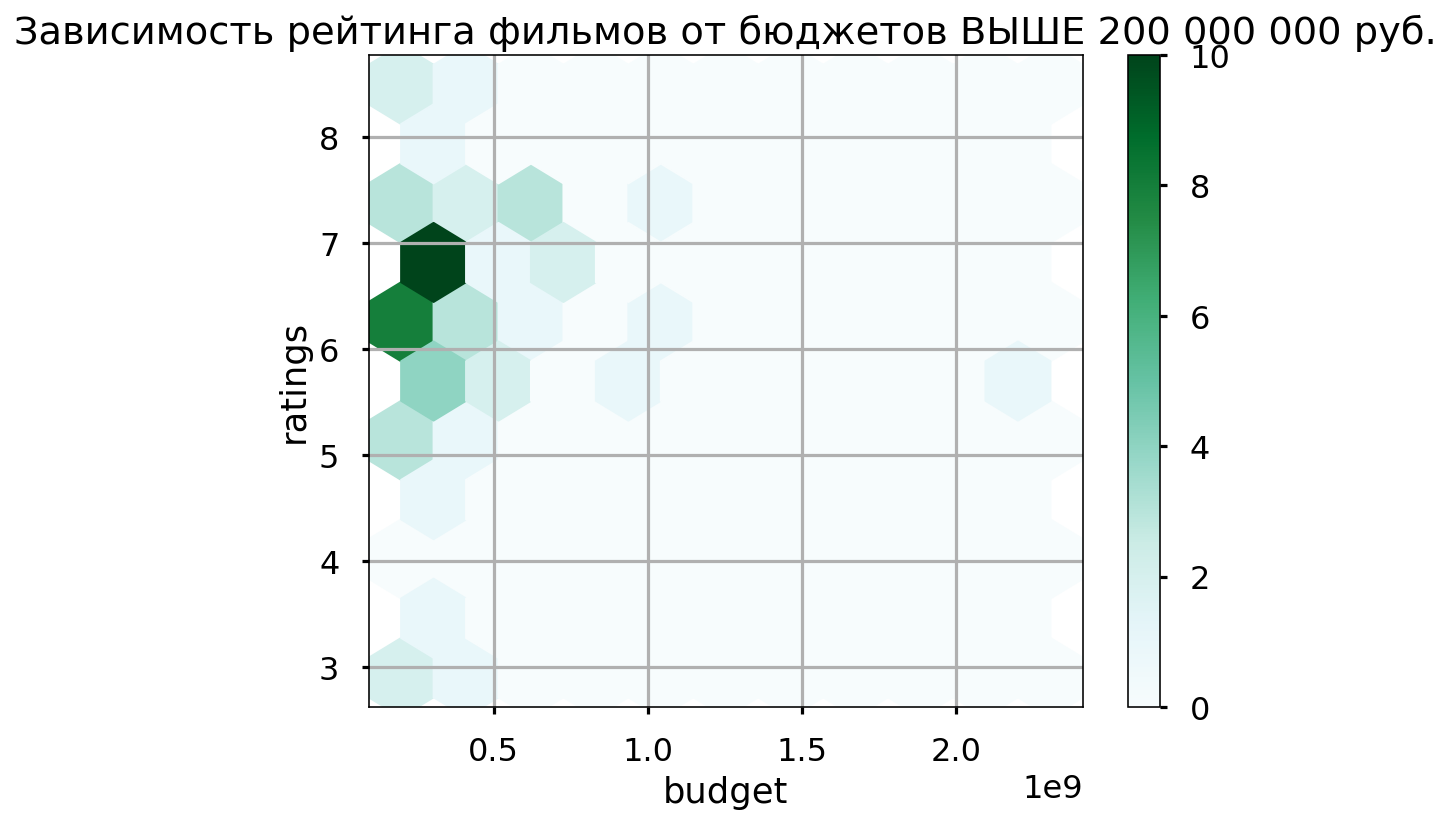

In [90]:
# график зависимости рейтингов от бюджета
films_with_government_support.plot(
    x='budget', y='ratings', kind='hexbin', gridsize=10, figsize=(
        8, 6), sharex=False, grid=True)
plt.title('Зависимость рейтинга фильмов от бюджетов', loc = 'center') # название графика
plt.show()

# график зависимости рейтингов с бюджетов ДО 200 000 000 руб.
films_with_government_support[films_with_government_support['budget'] < 200000000].plot(
    x='budget', y='ratings', kind='hexbin', gridsize=10, figsize=(
        8, 6), sharex=False, grid=True)
plt.title('Зависимость рейтинга фильмов от бюджетов ДО 200 000 000 руб.', loc = 'center') # название графика
plt.show()

# график зависимости рейтингов с бюджетов ВЫШЕ 200 000 000 руб.
films_with_government_support[films_with_government_support['budget'] > 200000000].plot(
    x='budget', y='ratings', kind='hexbin', gridsize=10, figsize=(
        8, 6), sharex=False, grid=True)
plt.title('Зависимость рейтинга фильмов от бюджетов ВЫШЕ 200 000 000 руб.', loc = 'center') # название графика
plt.show()

<div class="alert alert-success">
    
**Комментарий ревьюера - 2**

**#ок**

И здесь, и ниже для корреляции важно было не забыть 0 отфильтровать. Иначе и график немного искажен и значение корреляции достаточно сильно искажено.
</div>

<div class="alert alert-info">
    
**Вывод по анализу влияния государственной поддержки на показатели успешности фильмов.**

Графики демонстрируют, что влияние больших бюджетов фильмов не гарантирует высоких рейтингов. А в отдельных случаях даже наоборот (фильмы с низким рейтингом на нижнем графике).
    
В то же время распределения рейтингов фильмов без делений по суммам господдержки не сильно отличается  от распределений выше или ниже 200 000 000 руб.

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Хорошо, гистограммы верно показаны и выводы в целом корректны.

Я бы заменила бюджеты на милионы рублей для более удобного использования.

Также зависимость рейтинга от все же удобнее показать не с помощью гистограмм, а другими диаграммами, где по одной оси будет отображен рейтинг, а по другой бюджет.
    
Думаю в дальнейше по ходу прохождения курса, твой арсенал визуализаций пополнится.

</div>

In [91]:
display_pivot_table(
    films_with_government_support, 
    'show_start_date_year', 
    aggfunc=['count', 'sum', 'mean'], 
    column_names=['number_of_films', 'sum_budget', 'average_value'],
    base_column='budget')

,number_of_films,sum_budget,average_value
show_start_date_year,,,
2013,2,255435390.00,127717695.00
2014,16,1302484783.00,81405298.94
2015,84,7684206743.00,91478651.70
2016,61,7554942748.00,123851520.46
2017,41,7057172568.00,172126160.20
2018,56,7000664099.00,125011858.91
2019,70,12722866609.00,181755237.27


In [92]:
# Построю график зависимости суммы сборов от бюджетов фильмов
# Для определения факторов влияния на стоимость объекта построю тепловую диаграмму
corrMatrix = films_with_government_support.select_dtypes(
    include=np.number
).iloc[:, 1:6].corr()
    
# Вывожу основные параметры распределения бюджета фильма
print(movies_shows['budget'].describe())
# Выбираю стиль "тепловая карта" для отражения влияния господдержки на сборы в рублях
corrMatrix.style.background_gradient(
    cmap='coolwarm')

count          330.00
mean     132053857.39
std      187536651.42
min        6000000.00
25%       46153856.25
50%       72448592.50
75%      150000000.00
max     2305074303.00
Name: budget, dtype: float64


,age_restriction,refundable_support,nonrefundable_support,budget,ratings
age_restriction,1.000000,-0.220465,-0.132129,-0.190672,0.013493
refundable_support,-0.220465,1.000000,0.358387,0.654331,0.055292
nonrefundable_support,-0.132129,0.358387,1.000000,0.620163,0.121316
budget,-0.190672,0.654331,0.620163,1.000000,0.124539
ratings,0.013493,0.055292,0.121316,0.124539,1.000000


**Вывод по исследованию срезу с фильмами, получившими господдержку:**

***Проведенный анализ отражает низкую корреляцию между бюджетом фильмов и такими показателями как сборы (возврат инвестиций) и рейтингами фильмов.***

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Да, вот здесь корреляция отлично рассмотрена.

</div>

## Общий вывод.

Мною проведено исследование данных рынка российского кинопроката.  

В процессе анализа была изучена полученная информация, выполнена предобработка данных, добавлены столбцы с необходимыми значениями для дальнейшего анализа, проведён исследовательский анализ данных.  

Основные параметры были очищены от редких и нехарактерных значений, выведены средние сопоставимые параметры по количеству объектов.

Выявлено, что количество фильмов вышедших в прокат заметно увеличилось с 2015 года, при этом бОльшую сумму сборов демонстрируют фильмы в категориях возрастных ограничений 6+ и 12+.

Отмечаю, что бюджеты фильмов не имеют высокой корреляции с показателями рейтингов и сборов  

При необходимости более глубокого изучения можно изучить также влияние каждого из параметров в зависимости от жанров, режиссеров, стран-производителей и других интересующих показателей.

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Помню мы встречались на прошлом спринте. И технически твой проект также очень высокого качества, молодец. Видно, что ты отлично осваиваешь программу. 
    
Но призываю тебя, как и в прошлый раз, поработать над итоговыми выводыми. Для такого комплексного и разностороннего проекта они получились достаточно скудными. Помни, что заказчик, а также потенциальный работодатель твой проект (или тестовое задание) во многом будет оценивать по итоговым выводам. И будет обидно, если твой очень качественный проект просто не будут рассматривать среди других из-за крайне сжатых выводов.
    
В данном проекте можно было рассказать как изменялось количество фильмов, выпускаемых в год, как менялись кассовые сборы? В чем именно ты видешь причину таких изменений? Как распределены фильмы по категориям? Менялась ли картина в разные годы? Как распределены сборы по категориям? Разная картина для количества фильмов и сборов? В чем ты видишь причину популярности той или иной категории? Какова причина больших/маленьких сборов в отдельных категориях? Что можн сказать про фильмы с господдержкой? Отличается их картина, их показатели от общих?
    
Все это в проекте рассмотрено, но в выводах практически не отражено.

</div>

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**
    
Ты сделала отлчиную работу! Осталось доработать лишь несколько замечаний:
    
    - путаница рейтинг-жанр;
    
    - не совсем полные комментарии пропусков;
    
    - не достаточные комментарии распределения числовых показателе;
    
    - не совсем полный анализ доли фильмов с указанным прокатным бюджетом.
    
Большую часть работы ты уже выполнила и выполнила хорошо. Думаю, у тебя не возникнет проблем с доработками. Удачи.

</div>

- [x]  Файлы с данными открыты, объединены в один датафрейм.
- [x]  Датафрейм изучен: выведены первые строки, использован метод `info()`.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  Устранены неявные дубликаты в категориальных столбцах.
- [x]  Обработаны количественные столбцы датафрейма, построены гистограммы.
- [x]  В таблицу добавлены новые параметры:
       – информация о годе начала проката;
       – столбец с именем и фамилией главного режиссёра;
       – столбец с основным жанром;
       – столбец с долей господдержки в бюджете фильмов.
- [x]  Исследовательский анализ данных:
        - сколько фильмов выходило каждый год;
        - доля фильмов с указанной информацией о прокате в кинотеатрах;
        - динамика доли фильмов по годам с указанной информацией о прокате в кинотеатрах;
        - динамика проката по годам, годы максимальной и минимальной сумм сборов;
        - сводная таблица по суммам сборов;
        - влияние возрастных ограничений на суммы сборов;
        - динамика влияния возрастных ограничений на суммы сборов по годам;
        - влияние факторов на изменения сумм сборов по годам.
- [x]  Выполнено задание «Исследуйте фильмы, которые получили государственную поддержку (столбец `budget`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, какие категории, жанры, типы фильмов получают бОльшую господдержку.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.
